# **Project: Multitask Learning for Geometric Shape Classification and Counting**

## 1. Overview

In this project, you will design, implement, and evaluate a **multitask neural network** that performs **two tasks simultaneously**:

1. **Classification** – identify which pair of geometric shape types appears in a 28×28 binary image (135 possible configurations).
2. **Regression** – predict how many shapes of each type are present (6 regression targets).

This project focuses on **multi-task learning**, i.e., using one shared model to learn several related tasks at once. You will compare how adding an auxiliary task affects performance and training dynamics.

---

## 2. Dataset

You will use the **Geometric Shape Numbers (GSN)** dataset:

```bash
!wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
!unzip data_gsn.zip &> /dev/null
!rm data_gsn.zip
```

This will create a directory `data/` containing:

* **10,000 images** (28×28x1, grayscale)
* **labels.csv** – counts of each of six shape types per image

Each image contains exactly **two types** of geometric figures (out of six) and **10 shapes total**.

**Shape classes:**

| Index | Shape type     |
| ----: | -------------- |
|     0 | square         |
|     1 | circle         |
|     2 | triangle up    |
|     3 | triangle right |
|     4 | triangle down  |
|     5 | triangle left  |

Example row from `labels.csv`:

```
name,squares,circles,up,right,down,left
img_00000.png,0,0,0,4,0,6
```

Here, the image contains **4 right-pointing triangles** and **6 left-pointing triangles**.

**Split:**

* Training: first 9,000 samples
* Validation: last 1,000 samples

Examples:
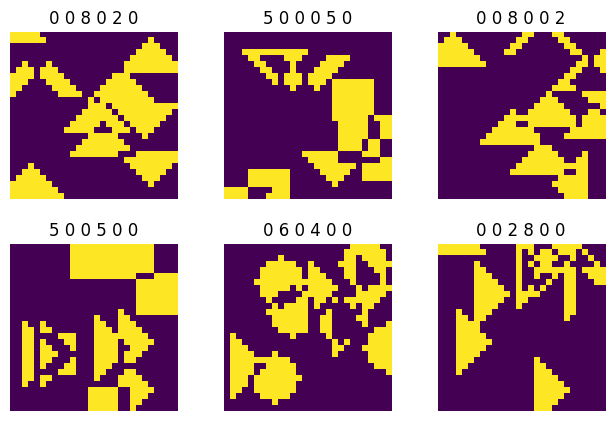

---

## 3. Tasks and objectives

You must design a **multitask deep learning system** that:

1. **Classifies** each image into one of **135 possible configurations**, representing:

   * which **two shape classes** appear, and
   * how their counts (1–9) sum to 10.

   → Example: "3 circles + 7 squares" is one configuration class.

2. **Regresses** the number of shapes of each type (a 6-dimensional real-valued output).

3. Combines both objectives in a **joint loss** function (Hint: losses are implemented in PyTorch):


$$ Loss = \text{NLLLoss(classification)} + \lambda_{\text{cnt}} \cdot \text{SmoothL1Loss(regression)}
$$

---

## 4. Model requirements

### Architecture constraints

You must use **exactly this feature extractor (backbone)**:

```python
nn.Sequential(
    nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
    nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
    nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
    nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
    nn.Flatten(start_dim=1),
    nn.Linear(64 * 28 * 28, 256), nn.ReLU()
)
```

Then add **two separate heads**:

* `head_cls`: outputs log-probabilities for 135 classes
* `head_cnt`: outputs 6 regression values (counts)

The model must return two outputs: `(log_probs, counts)`.

You may add dropout or batch normalization inside the heads, **but you must not modify the backbone**.

---

## 5. Training setup

* Optimizer: **Adam**, learning rate = 1e-3
* Epochs: up to **100** (use **early stopping**)
* Batch sizes: **64** (train), **1000** (validation)
* Device: GPU allowed for Notebook, but your **final code must run on GPU within ~30 minutes**
* Random seed: set `torch.manual_seed(1)` for reproducibility
* Split: **exactly 9,000 train / 1,000 validation**


---

## 6. Data preprocessing and augmentation

You must implement a **PyTorch `Dataset` class** that:

* Reads `labels.csv`
* Loads the corresponding image (from `data/`)
* Returns both:
  * the image (as a tensor)
  * the labels (counts for 6 shapes)
* Optionally applies transformations

### Required augmentations

You must implement **at least three** of the following:

1. Random horizontal flip
2. Random vertical flip
3. Random 90° rotation (must correctly rotate orientation labels: up → right → down → left)
4. Random brightness/contrast (mild)
5. Gaussian noise
6. Random erasing (small areas only)


---

## 7. Evaluation metrics

Implement and report the following metrics on the validation set:

### (a) **Classification (135-way)**

* Top-1 accuracy
* Macro F1-score
* Per-pair accuracy (aggregate by unordered shape pair, e.g. {circle, up})

### (b) **Regression (6-D counts)**

* RMSE per class and overall
* MAE per class and overall

Also plot:

* Training and validation losses
* Validation accuracy and RMSE over epochs

**Important**: This task is not about finding the best architecture; we expect at least 50% accuracy, but achieving results higher than that will not affect the grade for the assignment**.


---

## 8. Experiments and analysis

You must train and compare **three model settings**:

| Setting | Description                                      |
| :------ | :----------------------------------------------- |
| 1       | **Classification-only:** λ_cnt = 0               |
| 2       | **Regression-only:** classification loss ignored |
| 3       | **Multitask:** λ_cnt = with your choose          |

For each experiment:

* Train until early stopping
* Record loss, accuracy, RMSE, and runtime
* Compare results and explain how λ influences learning
* Discuss whether multitask learning improves the main tasks


---

## 9. Final deliverables

You must submit .zip project with:

1. **Code** (`.ipynb` or `.py`) that:

   * Downloads and extracts the dataset
   * Defines dataset, dataloaders, model, loss, training loop, evaluation, and plotting
   * Can run start-to-end without interaction, and finishes within 30 minutes on Colab T4 GPUs
   * Includes three experiment configurations

2. **Report (2–4 pages, PDF)** including:
   * Section on (EDA) Exploratory Data Analysis in your report: no more than 3 graphs or tables describing the data set.
   * Model architecture
   * Description and justification of augmentations
   * Results table (loss, accuracy, RMSE for all runs)
   * Learning curves
   * Discussion on multitask effects

3. **README.md**:

   * Link to Colab version of task for fast replication.
   * Approximate runtime and resource requirements

---

## 10. Grading rubric

Component	Description	Points
1. Implementation correctness	Correct use of the fixed backbone, two-headed model, and proper training loop (classification + regression).	30%
2. Data & augmentations	Proper dataset loading, preprocessing, and at least three augmentations with brief justification.	20%
3. Evaluation & experiments	Correct computation of metrics (accuracy, F1, RMSE) and completion of all three λ configurations (λ=0, regression-only, your choice λ).	30%
4. Report & analysis
A clear separation of concerns (e.g. headers in notebooks, modules in code) and concise 2–4 page report with results tables, learning curves, confusion matrix, and short discussion on multitask effects and error examples.
20%

###### Readability and modularity will be considered within each grading component. Clear structure (headers in notebooks, docstrings, modular code) significantly improves evaluation speed. Emphasize using clear headers to help reviewers navigate efficiently.
---

In [1]:
!wget  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
!unzip data_gsn.zip &> /dev/null
!rm data_gsn.zip

--2025-11-25 20:57:05--  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip [following]
--2025-11-25 20:57:06--  https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5544261 (5.3M) [application/zip]
Saving to: ‘data_gsn.zip’

data_gsn.zip        100%[===================>]   5.29M  --.-KB/s    in 0.08s   

2025-11-25 20:57:06 (70.3 MB/s) - ‘data_gsn.zip’ saved [5544261/5544261]



Example of an image: img_00004.png from created data folder - 28x28 pixels

img_00004.png

## Needed libraries

In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset
import os
from torchvision import transforms
from PIL import Image
import random
import torchvision.transforms.functional as TF
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader
import plotly.graph_objects as go
torch.manual_seed(1)
from google.colab import output
output.disable_custom_widget_manager()
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import numpy as np
import math
import matplotlib.pyplot as plt
import time
import matplotlib.pyplot as plt
np.random.seed(50)
random.seed(50)

## Creating DataSet class:


In [4]:
class DataSet(Dataset):
  def __init__(self, df_name:str, df_range:list, data_dir:str = 'data', apply_transformation: list = None) -> None:
    """
    Logic for apply_transformation:
    We have 3 transformations which we can aplly on the data = 3 elements in the list
    if i-th element is False , then we do not apply i-th transformation
    if i-th element is True , then we apply i-th transformation
    1 transformation = Random horizontal flip
    2 transformation = Gaussian noise
    3 transformation = Random erasing (small areas only)
    """
    self.df = pd.read_csv(data_dir + '/' + df_name).iloc[df_range[0]:df_range[1]].reset_index(drop=True)

    if apply_transformation == None: self.apply_transformation = [False,False,False]
    else: self.apply_transformation = apply_transformation

    self.data_dir = data_dir
    self.df_range = df_range
    self.df_name = df_name
    self.labels_dictionary = self._create_labels_dictionary()

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index) -> tuple[ torch.Tensor, tuple[int, torch.Tensor] ]:
    img_name = self.df.iloc[index]['name'] # getting name of an image
    img_path = os.path.join(self.data_dir, img_name)
    img = Image.open(img_path).convert('L')# converting to one-channel/grayscale

    original_label = self.df.iloc[index][['squares', 'circles','up', 'right', 'down', 'left']].values.astype('int').copy()

    if self.apply_transformation[0] == True and random.random()>0.5 :#Random horizontal flip
      img = TF.hflip(img)  # flipping an image

      #changing labels
      original_label[3], original_label[5] = original_label[5], original_label[3]

    img = TF.to_tensor(img)#because below transformations don't work with PIL images
    img = TF.normalize(img, [0.5], [0.5]) # normalizing
    if self.apply_transformation[1] == True:#Gaussian noise
      img = v2.GaussianNoise(mean=0.0,sigma=0.02, clip = True)(img)

    if self.apply_transformation[2] == True:#Random erasing (small areas only)
    # scale – range of proportion of erased area against input image
    # ratio – range of aspect ratio of erased area
    # value – erasing value to insert
      img = transforms.RandomErasing(p=0.4, scale=(0.001, 0.01), ratio=(0.3,3.3), value=0, inplace=False)(img)

    integer_label = self._get_integer_label(original_label=original_label)

    return img, (integer_label, torch.tensor(original_label, dtype = torch.float32))

  def _create_labels_dictionary(self)->dict:
    """
    Creates Classification Dictionary, where each
    key=(x,y,z), x=1st object, y=2nd object, z=number of geometric figures for the 1st object
    value=integer from 0 to 134 (corresponds all posiible combinations for key)
    Example: key = (0,1,2) ,which corresponds to value 1,
      means that first object is 0(square), second object is 1(circle)
      and we have 2 items of FIRST object(squares),
      then we have 10-2=8 items of the second object(circles)
    """
    dictionary = {}
    class_id = 0
    for type1 in range(6):
      for type2 in range(type1+1,6):
        for count1 in range(1,10):
          dictionary[(type1, type2, count1)] = class_id
          class_id += 1
    return dictionary

  def _get_integer_label(self, original_label: list) -> int:
    """
    Example: [0,0,0,0,9,1]->134
    """
    objects = [i for i, x in enumerate(original_label) if x>0]
    # using above example now objects = [4,5]
    type1, type2= objects[0], objects[1] # type1=4, type2=5 from example
    count1 = int(original_label[type1]) # = 9 from example
    integer_label = self.labels_dictionary[(type1, type2, count1)]
    return int(integer_label)


Checking the class


In [5]:
train_data = DataSet(df_name='labels.csv', df_range=[0,9000], data_dir='data', apply_transformation=[True, True, True])
validation_data = DataSet(df_name='labels.csv', df_range=[9000,10000], data_dir='data', apply_transformation=[False, False, False])

train_loader = DataLoader(train_data, batch_size = 64, shuffle = True,num_workers=2,pin_memory=True)
val_loader = DataLoader(validation_data, batch_size = 1000, shuffle = False, num_workers=2, pin_memory=True)

In [22]:
train_data.df

,name,squares,circles,up,right,down,left
0,img_00000.png,0,0,4,0,6,0
1,img_00001.png,0,0,0,5,0,5
2,img_00002.png,0,0,8,0,2,0
3,img_00003.png,0,7,0,0,0,3
4,img_00004.png,0,0,3,0,0,7
...,...,...,...,...,...,...,...
8995,img_08995.png,0,0,0,0,2,8
8996,img_08996.png,0,6,0,4,0,0
8997,img_08997.png,0,3,0,0,7,0
8998,img_08998.png,0,0,0,0,6,4


from matplotlib import pyplot as plt
_df_0['squares'].plot(kind='hist', bins=20, title='squares')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['circles'].plot(kind='hist', bins=20, title='circles')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['up'].plot(kind='hist', bins=20, title='up')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['right'].plot(kind='hist', bins=20, title='right')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='squares', y='circles', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5.plot(kind='scatter', x='circles', y='up', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='up', y='right', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='right', y='down', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['squares'].plot(kind='line', figsize=(8, 4), title='squares')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['circles'].plot(kind='line', figsize=(8, 4), title='circles')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['up'].plot(kind='line', figsize=(8, 4), title='up')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['right'].plot(kind='line', figsize=(8, 4), title='right')
plt.gca().spines[['top', 'right']].set_visible(False)

In [6]:
validation_data[3]

(tensor([[[-1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1., -1., -1., -1., -1.,
           -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
          [-1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1., -1., -1., -1.,
           -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
          [-1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1., -1., -1.,
           -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
          [-1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1.,
           -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
          [-1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,
           -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
          [-1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1., -1.,
           -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
          [-1., -1., -

## Model


In [6]:
class DragonModel(nn.Module):
  def __init__(self, p1:float, p2:float):
    super().__init__()
    self.network = nn.Sequential(
      nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
      nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
      nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
      nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
      nn.Flatten(start_dim=1),
      nn.Linear(64 * 28 * 28, 256), nn.ReLU()
    )
    self.head_cls = nn.Sequential(
        nn.Dropout(p=p1),
        nn.Linear(256, 135), # getting logits x = [100,-8, 0.9,...](for example)
        nn.LogSoftmax(dim = 1) # log(   [(e^x_i)/sum(e^x_i)] - probabilities from 0 to 1   ) - float from - infinity to 0
        # getting vector of size 135 of log probabilities of each class
    )
    self.head_cnt = nn.Sequential(
        nn.Dropout(p = p2),
        nn.Linear(256,6) # example of output : [2.05, 7.92, 0.1, -0.05, 0.0, 0.02]
        # getting vector of size 6 with predicted number of each object
    )

  def forward(self, x):
    backbone = self.network(x) # size = (batch, 256)

    log_prob = self.head_cls(backbone) # size = (batch, 135)
    counts = self.head_cnt(backbone) # size = (batch, 6)

    return log_prob, counts

## Train

I will use Visualizer from 4th lab with some corrections ( after training models I realized that I can't see any visualizations because of the progress bar I use, but I hope on other computers It will be visible. If it is not, there is some additional plots after each model training)

In [7]:
# @title <small>Helper class: TrainingVisualizer</small>

class TrainingVisualizer:
    def __init__(self, log_interval: int = 10):
        self.log_interval = log_interval
        self.train_loss_fig = self.init_line_plot(
            title="Training loss", xaxis_title="Step"
        )
        self.grad_to_weight_fig = self.init_line_plot(
            title="Gradient standard deviation to weight standard deviation ratio at 1st layer",
            xaxis_title="Step",
            yaxis_title="Gradient to weight ratio (log scale)",
            yaxis_type="log",
        )
        self.test_acc_fig = self.init_line_plot(
            title=" Validation accuracy", x=[], xaxis_title="Epoch", mode="lines+markers"
        )

        self.validation_loss_fig =self.init_line_plot(
            title="Validation loss", xaxis_title="Epoch", x=[], mode="lines+markers"
        )

        self.rmse_fig = self.init_line_plot(
            title="RMSE", x=[], xaxis_title="Epoch", mode="lines+markers"
        )

        # Parameters related to current tracked model and its training
        self.first_linear_layer = None
        self.lr = None
        self.trace_idx = -1

    def init_line_plot(
        self,
        title: str,
        x=None,
        xaxis_title: str | None = None,
        yaxis_title: str | None = None,
        yaxis_type: str = "linear",
        mode: str = "lines",
    ) -> go.FigureWidget:
        fig = go.Figure()
        fig.update_layout(
            title=title,
            title_x=0.5,
            xaxis_title=xaxis_title,
            yaxis_title=yaxis_title,
            height=400,
            width=1500,
            margin=dict(b=10, t=60),
        )
        fig.update_yaxes(type=yaxis_type)
        # We cannotd new traces dynamically because Colab has a problem with widgets
        # from plotly (traces added dynamically are rendered twice).
        # As an ugly workaround we create a lot of empty t adraces and update them later
        # with actual data. Empty traces are not plotted.
        for _ in range(25):
            fig.add_trace(go.Scatter(x=x, y=[], showlegend=True, mode=mode))

        fig_widget = go.FigureWidget(fig)
        display(fig_widget)
        return fig_widget

    def track_model(
        self, model: torch.nn.Module, optimizer: torch.optim.Optimizer, lr: float
    ) -> None:
        """
        Start tracking training metrics for a new model.
        """
        # in our model nn.Linear layer is hidden in nn.Sequential
        # so we need to use model.modules which will dive into our nn.Sequential
        # insted of model.__dict__["_modules"].values(), which will not
        for layer in model.modules():
          if isinstance(layer, nn.Linear):
            self.first_linear_layer = layer
            break

        self.lr = lr
        self.trace_idx += 1

        optim_name = type(optimizer).__name__
        self.train_loss_fig.data[self.trace_idx].name = f"{optim_name}, {lr}"
        self.grad_to_weight_fig.data[self.trace_idx].name = f"{optim_name}, {lr}"
        self.test_acc_fig.data[self.trace_idx].name = f"{optim_name}, {lr}"
        self.rmse_fig.data[self.trace_idx].name = f"{optim_name}, {lr}"
        self.validation_loss_fig.data[self.trace_idx].name = f"{optim_name}, {lr}"


    def plot_gradients_and_loss(self, batch_idx: int, loss: float) -> None:
        if batch_idx % self.log_interval == 0:
            self.train_loss_fig.data[self.trace_idx].y += (loss,)

            layer = self.first_linear_layer
            grad_to_weight_ratio = (
                self.lr * layer.weight.grad.std() / layer.weight.std()
            ).item()

            self.grad_to_weight_fig.data[self.trace_idx].y += (grad_to_weight_ratio,)

    def plot_validation_loss(self, epoch: int, loss:float)-> None:
        self.validation_loss_fig.data[self.trace_idx].x += (epoch,)
        self.validation_loss_fig.data[self.trace_idx].y += (loss,)

    def plot_accuracy(self, epoch: int, accuracy: float) -> None:
        self.test_acc_fig.data[self.trace_idx].x += (epoch,)
        self.test_acc_fig.data[self.trace_idx].y += (accuracy,)

    def plot_rmse(self, epoch:int, rmse: float)->None:
        self.rmse_fig.data[self.trace_idx].x += (epoch,)
        self.rmse_fig.data[self.trace_idx].y += (rmse,)

In [8]:
def test(
    model: DragonModel,
    device: torch.device,
    val_loader:  torch.utils.data.DataLoader,
    lambda_cnt: float,
    nll_loss,
    smoothl1_loss,
    visualizer: TrainingVisualizer,
    epoch: int,
    verbose: bool = True
) -> tuple[float, float]:
  model.eval() # turning on ' examing mode' , when all DropOuts Layers is off
  test_loss = 0.0
  classes_correct = 0
  total = 0
  all_predicted_counts= []
  all_target_counts = []
  final_loss_class  = 0.0
  final_loss_count = 0.0
  with torch.no_grad(): # do not remember history of calculations to save memory
    for images, (class_labels, count_labels) in val_loader: # taking batch
      # in each iteration we get batch_sizex1x28x28 images, batch_size classes and batch_sizex6 labels
      images, class_labels, count_labels = images.to(device), class_labels.to(device), count_labels.to(device)

      log_prob, pred_counts = model(images) # getting predictions from the model

      # calculating how wrong the model was
      loss_class = nll_loss(log_prob, class_labels)
      loss_count = smoothl1_loss(pred_counts, count_labels)
      total_loss = loss_class + lambda_cnt * loss_count

      test_loss+= total_loss.item()

      pred = log_prob.argmax(dim=1)# getting final class prediction from the model
      classes_correct += (pred == class_labels).sum().item() # counting how many times the model was correct
      total += len(class_labels) # adding how many images/samples was in this iteration

      all_predicted_counts.extend(pred_counts.cpu().numpy())
      all_target_counts.extend(count_labels.cpu().numpy())

      final_loss_class += loss_class.item()
      final_loss_count += loss_count.item()

  all_predicted_counts = np.array(all_predicted_counts)
  all_target_counts = np.array(all_target_counts)

  test_loss /= len(val_loader) # mean test_loss
  final_loss_class/= len(val_loader)
  final_loss_count/= len(val_loader)

  accuracy = 100.0 * classes_correct / total

  mse_overall = mean_squared_error(all_target_counts, all_predicted_counts)
  rmse = math.sqrt(mse_overall)
  if verbose:
    print(f"\nTest loss: {test_loss:.4f}, Accuracy: {classes_correct}/{total} ({classes_correct/total:.0%})\n")
    print(f"Class Loss: {final_loss_class:.4f}, Count Loss: {final_loss_count:.4f}\n")

  #Plots
  visualizer.plot_accuracy(epoch = epoch, accuracy = accuracy)
  visualizer.plot_rmse(epoch = epoch, rmse = rmse)
  visualizer.plot_validation_loss(epoch = epoch, loss = test_loss)

  return rmse, final_loss_class, final_loss_count,test_loss, accuracy

In [9]:
def train_epoch(
    model: DragonModel,
    device: torch.device,
    train_loader: torch.utils.data.DataLoader,
    val_loader:  torch.utils.data.DataLoader,
    optimizer: torch.optim.Adam,
    epochs: int,
    lambda_cnt: float,
    visualizer: TrainingVisualizer,
    epoch: int,
    log_interval: int,#how often we will print progress
    nll_loss,
    smoothl1_loss,
    verbose: bool = True
) -> None:
  model.train()
  progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
  for batch_idx, (images, (class_labels, count_labels)) in enumerate(progress_bar):
      # sending data to GPU
    images, class_labels, count_labels=images.to(device), class_labels.to(device), count_labels.to(device)

    optimizer.zero_grad()

    #Forward pass
    log_prob, pred_counts = model(images) # getting predictions from the model

    # calculating how wrong the model was
    loss_class = nll_loss(log_prob, class_labels)
    loss_counts = smoothl1_loss(pred_counts, count_labels)
    total_loss = loss_class + lambda_cnt * loss_counts

    #Backward pass
    total_loss.backward()

    # Visualization
    visualizer.plot_gradients_and_loss(batch_idx, total_loss.item())

    optimizer.step()

    progress_bar.set_postfix({'total loss': f'{total_loss.item():.6f}'})

    if batch_idx % log_interval == 0:
      if verbose:
        done, total = batch_idx * len(images), len(train_loader.dataset)
        progress_bar.write(
          f"Train Epoch: {epoch} [{done}/{total} images ({done / total:.0%})]\t"
            + f"Loss: {total_loss.item():.6f}"
             )

## Multitask model

In [10]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

log_interval=10
epochs = 100
batch_size = 64
test_batch_size = 1000

nll_loss = nn.NLLLoss()
smoothl1_loss = nn.SmoothL1Loss()
lambda_cnt = 0.5
lr = 1e-3 # don't change

model= DragonModel(p1=0.5, p2=0.5)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

visualizer = TrainingVisualizer(log_interval=log_interval)
visualizer.track_model(model, optimizer, lr)

patience = 20 # how many epochs we will wait until the better model with better accuracy will be founded
epochs_no_improve = 0
best_accuracy = 0.0
final_loss_class  = 0.0
final_loss_count = 0.0
best_rmse = 0.0
start_time = time.time()

val_loss_history = []
val_acc_history = []
val_rmse_history = []

#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)# works badly

for epoch in range(1, epochs + 1):
    train_epoch(
        model,
        device,
        train_loader,
        val_loader,
        optimizer,
        epochs,
        lambda_cnt,
        visualizer,
        epoch,
        log_interval,
        nll_loss,
        smoothl1_loss,
        verbose = True
    )

    rmse, loss_class, loss_count, test_loss , accuracy = test(
        model,
        device,
        val_loader,
        lambda_cnt,
        nll_loss,
        smoothl1_loss,
        visualizer,
        epoch,
        verbose = True
    )

    val_loss_history.append(test_loss)
    val_acc_history.append(accuracy)
    val_rmse_history.append(rmse)

    #scheduler.step(accuracy)

    if accuracy > best_accuracy:
      best_accuracy = accuracy
      epochs_no_improve = 0
      torch.save(model.state_dict(), 'best_model.pth') # saving the best model
      final_loss_class = loss_class
      final_loss_count = loss_count
      best_rmse=rmse
    else:
      epochs_no_improve += 1

    if epochs_no_improve >= patience: break
end_time = time.time()
total_time = end_time - start_time

FigureWidget({
    'data': [{'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'd6cd46e8-aa5d-481a-9ea7-472721ce346e',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '26f0cc8f-42de-4452-b290-8458d958a499',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'bcb70e08-3de5-4314-a220-1ac5bb3be3eb',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f3cb1268-de60-43e9-946e-633a3a92aadc',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '7bfd38e8-3be8-4a74-8996-9b2acacee0d2',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
     

FigureWidget({
    'data': [{'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'c43f40e7-c69f-43b5-b166-5288a1d017f2',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'd61610f2-4c73-4941-a6b5-6751f4a0370a',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '115b486b-7a0e-40c9-9a9f-baf945c9862b',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '415e8a01-9d13-4e19-9375-10db6f419d9e',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'c6a1b32d-9825-4251-9485-b3914cdf39a8',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
     

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '450f08d5-e215-426a-9551-2d3f7999ea35',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '412a499e-ae93-4d54-8d49-9f40109b8f4c',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'b8671851-75eb-45fb-a070-83b80ed5dee3',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '7907a7a8-56c5-42a2-83d4-56998f56cc8e',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '5

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'a26071ec-7e6a-40c9-bf2a-d779c559e8bf',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '238dfec8-9cc8-4b06-9ae3-c7f6c68f0462',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'c3a54796-5e68-4d4a-bd8d-4fecb5715f86',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '19bb8226-8ee4-4f8e-a2a2-6f345375888f',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'a

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'e7e00cd4-ee65-4586-a780-106f48637365',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'c410a67f-9fe5-4bd8-ad1e-cb616a38ef8a',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f7a0e331-e939-48b6-865d-f0a6eb33b019',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '76546201-96b6-48ac-8939-4d14479a0bc1',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'd

Epoch 2/100:   5%|▍         | 7/141 [00:00<00:10, 12.64it/s, total loss=5.613766]

Train Epoch: 1 [0/9000 images (0%)]	Loss: 5.661185


Epoch 2/100:  10%|▉         | 14/141 [00:01<00:07, 16.86it/s, total loss=5.639539]

Train Epoch: 1 [640/9000 images (7%)]	Loss: 5.588116


Epoch 2/100:  16%|█▌        | 22/141 [00:01<00:05, 20.59it/s, total loss=5.540020]

Train Epoch: 1 [1280/9000 images (14%)]	Loss: 5.596096


Epoch 2/100:  24%|██▍       | 34/141 [00:01<00:04, 22.95it/s, total loss=5.438025]

Train Epoch: 1 [1920/9000 images (21%)]	Loss: 5.564815


Epoch 2/100:  30%|██▉       | 42/141 [00:02<00:04, 23.71it/s, total loss=5.510730]

Train Epoch: 1 [2560/9000 images (28%)]	Loss: 5.493163


Epoch 2/100:  38%|███▊      | 54/141 [00:02<00:03, 23.92it/s, total loss=5.493649]

Train Epoch: 1 [3200/9000 images (36%)]	Loss: 5.460917


Epoch 2/100:  44%|████▍     | 62/141 [00:03<00:03, 23.88it/s, total loss=5.461706]

Train Epoch: 1 [3840/9000 images (43%)]	Loss: 5.441755


Epoch 2/100:  52%|█████▏    | 74/141 [00:03<00:02, 24.32it/s, total loss=5.425446]

Train Epoch: 1 [4480/9000 images (50%)]	Loss: 5.440425


Epoch 2/100:  58%|█████▊    | 82/141 [00:03<00:02, 24.35it/s, total loss=5.455203]

Train Epoch: 1 [5120/9000 images (57%)]	Loss: 5.445757


Epoch 2/100:  67%|██████▋   | 94/141 [00:04<00:01, 23.91it/s, total loss=5.499336]

Train Epoch: 1 [5760/9000 images (64%)]	Loss: 5.447740


Epoch 2/100:  72%|███████▏  | 102/141 [00:04<00:01, 23.84it/s, total loss=5.476142]

Train Epoch: 1 [6400/9000 images (71%)]	Loss: 5.425266


Epoch 2/100:  81%|████████  | 114/141 [00:05<00:01, 23.52it/s, total loss=5.459338]

Train Epoch: 1 [7040/9000 images (78%)]	Loss: 5.427801


Epoch 2/100:  87%|████████▋ | 122/141 [00:05<00:00, 23.41it/s, total loss=5.435850]

Train Epoch: 1 [7680/9000 images (85%)]	Loss: 5.413959


Epoch 2/100:  95%|█████████▌| 134/141 [00:06<00:00, 23.81it/s, total loss=5.434140]

Train Epoch: 1 [8320/9000 images (92%)]	Loss: 5.364290


Epoch 2/100: 100%|██████████| 141/141 [00:06<00:00, 22.25it/s, total loss=5.370688]

Train Epoch: 1 [5600/9000 images (62%)]	Loss: 5.370688



Test loss: 5.3902, Accuracy: 15/1000 (2%)

Class Loss: 4.6808, Count Loss: 1.4189



Epoch 3/100:   4%|▎         | 5/141 [00:00<00:07, 17.54it/s, total loss=5.377977]

Train Epoch: 2 [0/9000 images (0%)]	Loss: 5.439490


Epoch 3/100:  11%|█         | 15/141 [00:00<00:05, 22.47it/s, total loss=5.453963]

Train Epoch: 2 [640/9000 images (7%)]	Loss: 5.383923


Epoch 3/100:  17%|█▋        | 24/141 [00:01<00:04, 23.74it/s, total loss=5.458635]

Train Epoch: 2 [1280/9000 images (14%)]	Loss: 5.379447


Epoch 3/100:  23%|██▎       | 33/141 [00:01<00:04, 23.71it/s, total loss=5.417612]

Train Epoch: 2 [1920/9000 images (21%)]	Loss: 5.363804


Epoch 3/100:  32%|███▏      | 45/141 [00:02<00:04, 23.39it/s, total loss=5.416799]

Train Epoch: 2 [2560/9000 images (28%)]	Loss: 5.372596


Epoch 3/100:  38%|███▊      | 54/141 [00:02<00:03, 22.20it/s, total loss=5.408640]

Train Epoch: 2 [3200/9000 images (36%)]	Loss: 5.425180


Epoch 3/100:  45%|████▌     | 64/141 [00:02<00:03, 23.42it/s, total loss=5.398766]

Train Epoch: 2 [3840/9000 images (43%)]	Loss: 5.428817


Epoch 3/100:  52%|█████▏    | 74/141 [00:03<00:03, 21.59it/s, total loss=5.388246]

Train Epoch: 2 [4480/9000 images (50%)]	Loss: 5.384225


Epoch 3/100:  60%|█████▉    | 84/141 [00:03<00:02, 22.61it/s, total loss=5.398467]

Train Epoch: 2 [5120/9000 images (57%)]	Loss: 5.401446


Epoch 3/100:  65%|██████▌   | 92/141 [00:04<00:02, 23.53it/s, total loss=5.382738]

Train Epoch: 2 [5760/9000 images (64%)]	Loss: 5.400420


Epoch 3/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.00it/s, total loss=5.425052]

Train Epoch: 2 [6400/9000 images (71%)]	Loss: 5.455556


Epoch 3/100:  79%|███████▉  | 112/141 [00:04<00:01, 24.17it/s, total loss=5.413340]

Train Epoch: 2 [7040/9000 images (78%)]	Loss: 5.334245


Epoch 3/100:  88%|████████▊ | 124/141 [00:05<00:00, 23.86it/s, total loss=5.363737]

Train Epoch: 2 [7680/9000 images (85%)]	Loss: 5.400786


Epoch 3/100:  94%|█████████▎| 132/141 [00:05<00:00, 23.85it/s, total loss=5.239399]

Train Epoch: 2 [8320/9000 images (92%)]	Loss: 5.347976


Epoch 3/100: 100%|██████████| 141/141 [00:06<00:00, 23.20it/s, total loss=5.212759]


Train Epoch: 2 [5600/9000 images (62%)]	Loss: 5.212759

Test loss: 8.2546, Accuracy: 12/1000 (1%)

Class Loss: 6.7881, Count Loss: 2.9329



Epoch 4/100:   1%|          | 1/141 [00:00<00:22,  6.22it/s, total loss=5.209096]

Train Epoch: 3 [0/9000 images (0%)]	Loss: 5.218802


Epoch 4/100:   9%|▉         | 13/141 [00:00<00:05, 22.17it/s, total loss=5.113245]

Train Epoch: 3 [640/9000 images (7%)]	Loss: 5.164008


Epoch 4/100:  18%|█▊        | 26/141 [00:01<00:04, 24.26it/s, total loss=4.920787]

Train Epoch: 3 [1280/9000 images (14%)]	Loss: 4.984657


Epoch 4/100:  25%|██▍       | 35/141 [00:01<00:04, 24.16it/s, total loss=5.008589]

Train Epoch: 3 [1920/9000 images (21%)]	Loss: 4.921330


Epoch 4/100:  31%|███       | 44/141 [00:01<00:04, 23.71it/s, total loss=4.860443]

Train Epoch: 3 [2560/9000 images (28%)]	Loss: 4.785063


Epoch 4/100:  38%|███▊      | 53/141 [00:02<00:03, 24.27it/s, total loss=4.943717]

Train Epoch: 3 [3200/9000 images (36%)]	Loss: 5.121051


Epoch 4/100:  45%|████▌     | 64/141 [00:02<00:03, 23.48it/s, total loss=5.070574]

Train Epoch: 3 [3840/9000 images (43%)]	Loss: 4.785411


Epoch 4/100:  51%|█████     | 72/141 [00:03<00:02, 23.62it/s, total loss=4.822792]

Train Epoch: 3 [4480/9000 images (50%)]	Loss: 4.786273


Epoch 4/100:  60%|█████▉    | 84/141 [00:03<00:02, 24.25it/s, total loss=4.938947]

Train Epoch: 3 [5120/9000 images (57%)]	Loss: 4.958567


Epoch 4/100:  65%|██████▌   | 92/141 [00:04<00:02, 24.17it/s, total loss=4.673903]

Train Epoch: 3 [5760/9000 images (64%)]	Loss: 4.788909


Epoch 4/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.98it/s, total loss=4.751374]

Train Epoch: 3 [6400/9000 images (71%)]	Loss: 4.774699


Epoch 4/100:  81%|████████  | 114/141 [00:04<00:01, 22.90it/s, total loss=4.795008]

Train Epoch: 3 [7040/9000 images (78%)]	Loss: 4.783532


Epoch 4/100:  87%|████████▋ | 122/141 [00:05<00:00, 23.05it/s, total loss=4.879854]

Train Epoch: 3 [7680/9000 images (85%)]	Loss: 4.749804


Epoch 4/100:  95%|█████████▌| 134/141 [00:05<00:00, 23.64it/s, total loss=4.780244]

Train Epoch: 3 [8320/9000 images (92%)]	Loss: 4.701926


Epoch 4/100: 100%|██████████| 141/141 [00:05<00:00, 23.52it/s, total loss=4.462086]


Train Epoch: 3 [5600/9000 images (62%)]	Loss: 4.462086

Test loss: 13.0078, Accuracy: 6/1000 (1%)

Class Loss: 11.4664, Count Loss: 3.0828



Epoch 5/100:   1%|          | 1/141 [00:00<00:22,  6.20it/s, total loss=4.627641]

Train Epoch: 4 [0/9000 images (0%)]	Loss: 4.684053


Epoch 5/100:   9%|▉         | 13/141 [00:00<00:05, 22.06it/s, total loss=4.579198]

Train Epoch: 4 [640/9000 images (7%)]	Loss: 4.680490


Epoch 5/100:  18%|█▊        | 25/141 [00:01<00:04, 23.63it/s, total loss=4.542982]

Train Epoch: 4 [1280/9000 images (14%)]	Loss: 4.499722


Epoch 5/100:  23%|██▎       | 33/141 [00:01<00:04, 23.88it/s, total loss=4.559904]

Train Epoch: 4 [1920/9000 images (21%)]	Loss: 4.574312


Epoch 5/100:  32%|███▏      | 45/141 [00:01<00:03, 24.17it/s, total loss=4.492431]

Train Epoch: 4 [2560/9000 images (28%)]	Loss: 4.528479


Epoch 5/100:  38%|███▊      | 53/141 [00:02<00:03, 24.33it/s, total loss=4.534697]

Train Epoch: 4 [3200/9000 images (36%)]	Loss: 4.383664


Epoch 5/100:  46%|████▌     | 65/141 [00:02<00:03, 24.38it/s, total loss=4.327792]

Train Epoch: 4 [3840/9000 images (43%)]	Loss: 4.350493


Epoch 5/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.20it/s, total loss=4.253896]

Train Epoch: 4 [4480/9000 images (50%)]	Loss: 4.122144


Epoch 5/100:  60%|█████▉    | 84/141 [00:03<00:02, 24.20it/s, total loss=4.233295]

Train Epoch: 4 [5120/9000 images (57%)]	Loss: 4.359506


Epoch 5/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.69it/s, total loss=4.267004]

Train Epoch: 4 [5760/9000 images (64%)]	Loss: 4.301180


Epoch 5/100:  72%|███████▏  | 102/141 [00:04<00:01, 23.59it/s, total loss=4.083840]

Train Epoch: 4 [6400/9000 images (71%)]	Loss: 4.033217


Epoch 5/100:  80%|████████  | 113/141 [00:04<00:01, 25.30it/s, total loss=3.988242]

Train Epoch: 4 [7040/9000 images (78%)]	Loss: 4.289981


Epoch 5/100:  88%|████████▊ | 124/141 [00:05<00:00, 23.77it/s, total loss=4.330953]

Train Epoch: 4 [7680/9000 images (85%)]	Loss: 4.078744


Epoch 5/100:  94%|█████████▎| 132/141 [00:05<00:00, 23.86it/s, total loss=3.964286]

Train Epoch: 4 [8320/9000 images (92%)]	Loss: 4.083112


Epoch 5/100: 100%|██████████| 141/141 [00:05<00:00, 23.71it/s, total loss=4.186911]

Train Epoch: 4 [5600/9000 images (62%)]	Loss: 4.186911



Test loss: 14.8888, Accuracy: 7/1000 (1%)

Class Loss: 13.4686, Count Loss: 2.8404



Epoch 6/100:   1%|          | 1/141 [00:00<00:23,  5.85it/s, total loss=3.818651]

Train Epoch: 5 [0/9000 images (0%)]	Loss: 3.765762


Epoch 6/100:   9%|▉         | 13/141 [00:00<00:05, 21.76it/s, total loss=4.063564]

Train Epoch: 5 [640/9000 images (7%)]	Loss: 3.875282


Epoch 6/100:  18%|█▊        | 25/141 [00:01<00:04, 23.24it/s, total loss=4.168388]

Train Epoch: 5 [1280/9000 images (14%)]	Loss: 3.932083


Epoch 6/100:  23%|██▎       | 33/141 [00:01<00:04, 23.43it/s, total loss=4.095546]

Train Epoch: 5 [1920/9000 images (21%)]	Loss: 3.969808


Epoch 6/100:  32%|███▏      | 45/141 [00:02<00:04, 23.59it/s, total loss=3.932925]

Train Epoch: 5 [2560/9000 images (28%)]	Loss: 3.902928


Epoch 6/100:  38%|███▊      | 53/141 [00:02<00:03, 23.53it/s, total loss=3.712962]

Train Epoch: 5 [3200/9000 images (36%)]	Loss: 3.887651


Epoch 6/100:  46%|████▌     | 65/141 [00:02<00:03, 24.05it/s, total loss=3.726379]

Train Epoch: 5 [3840/9000 images (43%)]	Loss: 3.593774


Epoch 6/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.10it/s, total loss=3.739292]

Train Epoch: 5 [4480/9000 images (50%)]	Loss: 3.641770


Epoch 6/100:  60%|██████    | 85/141 [00:03<00:02, 24.09it/s, total loss=3.948304]

Train Epoch: 5 [5120/9000 images (57%)]	Loss: 4.006684


Epoch 6/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.98it/s, total loss=3.495063]

Train Epoch: 5 [5760/9000 images (64%)]	Loss: 3.594965


Epoch 6/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.01it/s, total loss=3.396974]

Train Epoch: 5 [6400/9000 images (71%)]	Loss: 3.516920


Epoch 6/100:  80%|████████  | 113/141 [00:04<00:01, 23.95it/s, total loss=3.664926]

Train Epoch: 5 [7040/9000 images (78%)]	Loss: 3.554711


Epoch 6/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.32it/s, total loss=3.578458]

Train Epoch: 5 [7680/9000 images (85%)]	Loss: 3.669366


Epoch 6/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.20it/s, total loss=3.558806]

Train Epoch: 5 [8320/9000 images (92%)]	Loss: 3.516712


Epoch 6/100: 100%|██████████| 141/141 [00:05<00:00, 23.51it/s, total loss=3.510950]

Train Epoch: 5 [5600/9000 images (62%)]	Loss: 3.510950



Test loss: 13.5247, Accuracy: 22/1000 (2%)

Class Loss: 12.3127, Count Loss: 2.4239



Epoch 7/100:   4%|▎         | 5/141 [00:00<00:07, 18.01it/s, total loss=3.397431]

Train Epoch: 6 [0/9000 images (0%)]	Loss: 3.496403


Epoch 7/100:  11%|█         | 15/141 [00:00<00:05, 22.94it/s, total loss=3.283766]

Train Epoch: 6 [640/9000 images (7%)]	Loss: 3.422036


Epoch 7/100:  17%|█▋        | 24/141 [00:01<00:04, 24.83it/s, total loss=3.139915]

Train Epoch: 6 [1280/9000 images (14%)]	Loss: 3.388738


Epoch 7/100:  26%|██▌       | 36/141 [00:01<00:04, 24.61it/s, total loss=3.306130]

Train Epoch: 6 [1920/9000 images (21%)]	Loss: 3.418889


Epoch 7/100:  32%|███▏      | 45/141 [00:01<00:03, 24.60it/s, total loss=3.272529]

Train Epoch: 6 [2560/9000 images (28%)]	Loss: 3.414763


Epoch 7/100:  38%|███▊      | 54/141 [00:02<00:03, 24.21it/s, total loss=3.442178]

Train Epoch: 6 [3200/9000 images (36%)]	Loss: 3.213032


Epoch 7/100:  45%|████▍     | 63/141 [00:02<00:03, 24.84it/s, total loss=3.207924]

Train Epoch: 6 [3840/9000 images (43%)]	Loss: 3.290075


Epoch 7/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.88it/s, total loss=2.982999]

Train Epoch: 6 [4480/9000 images (50%)]	Loss: 3.095935


Epoch 7/100:  60%|█████▉    | 84/141 [00:03<00:02, 23.67it/s, total loss=3.220199]

Train Epoch: 6 [5120/9000 images (57%)]	Loss: 3.075048


Epoch 7/100:  66%|██████▌   | 93/141 [00:03<00:01, 24.88it/s, total loss=3.187836]

Train Epoch: 6 [5760/9000 images (64%)]	Loss: 2.870796


Epoch 7/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.08it/s, total loss=3.048959]

Train Epoch: 6 [6400/9000 images (71%)]	Loss: 3.060839


Epoch 7/100:  81%|████████  | 114/141 [00:04<00:01, 24.01it/s, total loss=2.852316]

Train Epoch: 6 [7040/9000 images (78%)]	Loss: 2.939435


Epoch 7/100:  87%|████████▋ | 123/141 [00:05<00:00, 24.59it/s, total loss=2.822195]

Train Epoch: 6 [7680/9000 images (85%)]	Loss: 3.094210


Epoch 7/100:  96%|█████████▌| 135/141 [00:05<00:00, 24.23it/s, total loss=3.000145]

Train Epoch: 6 [8320/9000 images (92%)]	Loss: 2.727208


Epoch 7/100: 100%|██████████| 141/141 [00:05<00:00, 24.01it/s, total loss=2.919877]

Train Epoch: 6 [5600/9000 images (62%)]	Loss: 2.919877



Test loss: 12.4901, Accuracy: 38/1000 (4%)

Class Loss: 11.4929, Count Loss: 1.9943



Epoch 8/100:   4%|▎         | 5/141 [00:00<00:07, 17.55it/s, total loss=2.921082]

Train Epoch: 7 [0/9000 images (0%)]	Loss: 2.963998


Epoch 8/100:   9%|▉         | 13/141 [00:00<00:05, 22.24it/s, total loss=2.983891]

Train Epoch: 7 [640/9000 images (7%)]	Loss: 2.722675


Epoch 8/100:  18%|█▊        | 25/141 [00:01<00:04, 23.61it/s, total loss=2.708915]

Train Epoch: 7 [1280/9000 images (14%)]	Loss: 2.756977


Epoch 8/100:  23%|██▎       | 33/141 [00:01<00:04, 23.92it/s, total loss=2.680421]

Train Epoch: 7 [1920/9000 images (21%)]	Loss: 2.817057


Epoch 8/100:  32%|███▏      | 45/141 [00:01<00:04, 23.59it/s, total loss=2.745336]

Train Epoch: 7 [2560/9000 images (28%)]	Loss: 2.847746


Epoch 8/100:  38%|███▊      | 53/141 [00:02<00:03, 23.79it/s, total loss=2.574815]

Train Epoch: 7 [3200/9000 images (36%)]	Loss: 2.595496


Epoch 8/100:  46%|████▌     | 65/141 [00:02<00:03, 24.13it/s, total loss=2.905914]

Train Epoch: 7 [3840/9000 images (43%)]	Loss: 2.800465


Epoch 8/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.29it/s, total loss=2.884072]

Train Epoch: 7 [4480/9000 images (50%)]	Loss: 2.777820


Epoch 8/100:  60%|██████    | 85/141 [00:03<00:02, 24.19it/s, total loss=2.754108]

Train Epoch: 7 [5120/9000 images (57%)]	Loss: 2.696326


Epoch 8/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.90it/s, total loss=2.707381]

Train Epoch: 7 [5760/9000 images (64%)]	Loss: 3.114158


Epoch 8/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.33it/s, total loss=2.856229]

Train Epoch: 7 [6400/9000 images (71%)]	Loss: 2.809988


Epoch 8/100:  80%|████████  | 113/141 [00:04<00:01, 24.28it/s, total loss=2.810142]

Train Epoch: 7 [7040/9000 images (78%)]	Loss: 2.688396


Epoch 8/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.56it/s, total loss=2.663981]

Train Epoch: 7 [7680/9000 images (85%)]	Loss: 2.832904


Epoch 8/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.53it/s, total loss=2.659259]

Train Epoch: 7 [8320/9000 images (92%)]	Loss: 2.556605


Epoch 8/100: 100%|██████████| 141/141 [00:05<00:00, 23.75it/s, total loss=2.835034]

Train Epoch: 7 [5600/9000 images (62%)]	Loss: 2.835034



Test loss: 11.6464, Accuracy: 39/1000 (4%)

Class Loss: 10.6682, Count Loss: 1.9565



Epoch 9/100:   4%|▎         | 5/141 [00:00<00:07, 17.88it/s, total loss=2.441097]

Train Epoch: 8 [0/9000 images (0%)]	Loss: 2.739274


Epoch 9/100:  11%|█         | 15/141 [00:00<00:05, 22.09it/s, total loss=2.571360]

Train Epoch: 8 [640/9000 images (7%)]	Loss: 2.907048


Epoch 9/100:  16%|█▋        | 23/141 [00:01<00:05, 23.14it/s, total loss=2.607618]

Train Epoch: 8 [1280/9000 images (14%)]	Loss: 2.467385


Epoch 9/100:  25%|██▍       | 35/141 [00:01<00:04, 23.70it/s, total loss=2.646648]

Train Epoch: 8 [1920/9000 images (21%)]	Loss: 2.481932


Epoch 9/100:  30%|███       | 43/141 [00:01<00:04, 23.68it/s, total loss=2.713335]

Train Epoch: 8 [2560/9000 images (28%)]	Loss: 2.387741


Epoch 9/100:  39%|███▉      | 55/141 [00:02<00:03, 23.87it/s, total loss=2.532743]

Train Epoch: 8 [3200/9000 images (36%)]	Loss: 2.619895


Epoch 9/100:  45%|████▍     | 63/141 [00:02<00:03, 24.02it/s, total loss=2.353511]

Train Epoch: 8 [3840/9000 images (43%)]	Loss: 2.685046


Epoch 9/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.12it/s, total loss=2.538537]

Train Epoch: 8 [4480/9000 images (50%)]	Loss: 2.484788


Epoch 9/100:  59%|█████▉    | 83/141 [00:03<00:02, 24.42it/s, total loss=2.695293]

Train Epoch: 8 [5120/9000 images (57%)]	Loss: 2.410677


Epoch 9/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.61it/s, total loss=2.681086]

Train Epoch: 8 [5760/9000 images (64%)]	Loss: 2.451941


Epoch 9/100:  73%|███████▎  | 103/141 [00:04<00:01, 24.54it/s, total loss=2.551118]

Train Epoch: 8 [6400/9000 images (71%)]	Loss: 2.341101


Epoch 9/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.41it/s, total loss=2.253460]

Train Epoch: 8 [7040/9000 images (78%)]	Loss: 2.347050


Epoch 9/100:  87%|████████▋ | 123/141 [00:05<00:00, 24.31it/s, total loss=2.551329]

Train Epoch: 8 [7680/9000 images (85%)]	Loss: 2.623008


Epoch 9/100:  96%|█████████▌| 135/141 [00:05<00:00, 24.35it/s, total loss=2.273763]

Train Epoch: 8 [8320/9000 images (92%)]	Loss: 2.278198


Epoch 9/100: 100%|██████████| 141/141 [00:05<00:00, 23.76it/s, total loss=2.134732]

Train Epoch: 8 [5600/9000 images (62%)]	Loss: 2.134732



Test loss: 11.8275, Accuracy: 43/1000 (4%)

Class Loss: 10.9171, Count Loss: 1.8208



Epoch 10/100:   4%|▎         | 5/141 [00:00<00:07, 17.47it/s, total loss=2.408547]

Train Epoch: 9 [0/9000 images (0%)]	Loss: 2.300195


Epoch 10/100:   9%|▉         | 13/141 [00:00<00:05, 22.37it/s, total loss=2.424227]

Train Epoch: 9 [640/9000 images (7%)]	Loss: 2.281741


Epoch 10/100:  18%|█▊        | 25/141 [00:01<00:04, 23.94it/s, total loss=2.386827]

Train Epoch: 9 [1280/9000 images (14%)]	Loss: 2.563692


Epoch 10/100:  23%|██▎       | 33/141 [00:01<00:04, 23.98it/s, total loss=2.521813]

Train Epoch: 9 [1920/9000 images (21%)]	Loss: 2.277923


Epoch 10/100:  32%|███▏      | 45/141 [00:01<00:03, 24.15it/s, total loss=2.380395]

Train Epoch: 9 [2560/9000 images (28%)]	Loss: 2.478185


Epoch 10/100:  38%|███▊      | 53/141 [00:02<00:03, 24.05it/s, total loss=2.234077]

Train Epoch: 9 [3200/9000 images (36%)]	Loss: 2.278723


Epoch 10/100:  46%|████▌     | 65/141 [00:02<00:03, 24.00it/s, total loss=2.125226]

Train Epoch: 9 [3840/9000 images (43%)]	Loss: 2.559105


Epoch 10/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.38it/s, total loss=2.482432]

Train Epoch: 9 [4480/9000 images (50%)]	Loss: 2.475702


Epoch 10/100:  60%|██████    | 85/141 [00:03<00:02, 24.52it/s, total loss=2.344199]

Train Epoch: 9 [5120/9000 images (57%)]	Loss: 2.348143


Epoch 10/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.64it/s, total loss=2.220519]

Train Epoch: 9 [5760/9000 images (64%)]	Loss: 2.188749


Epoch 10/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.26it/s, total loss=2.185813]

Train Epoch: 9 [6400/9000 images (71%)]	Loss: 2.205414


Epoch 10/100:  80%|████████  | 113/141 [00:04<00:01, 24.22it/s, total loss=2.723815]

Train Epoch: 9 [7040/9000 images (78%)]	Loss: 2.222970


Epoch 10/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.12it/s, total loss=2.179548]

Train Epoch: 9 [7680/9000 images (85%)]	Loss: 2.605000


Epoch 10/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.09it/s, total loss=2.253459]

Train Epoch: 9 [8320/9000 images (92%)]	Loss: 2.342743


Epoch 10/100: 100%|██████████| 141/141 [00:05<00:00, 23.83it/s, total loss=2.398902]

Train Epoch: 9 [5600/9000 images (62%)]	Loss: 2.398902



Test loss: 10.0370, Accuracy: 44/1000 (4%)

Class Loss: 9.1645, Count Loss: 1.7450



Epoch 11/100:   4%|▎         | 5/141 [00:00<00:07, 17.75it/s, total loss=2.107475]

Train Epoch: 10 [0/9000 images (0%)]	Loss: 2.200004


Epoch 11/100:   9%|▉         | 13/141 [00:00<00:05, 22.41it/s, total loss=2.382253]

Train Epoch: 10 [640/9000 images (7%)]	Loss: 2.168171


Epoch 11/100:  18%|█▊        | 25/141 [00:01<00:04, 24.24it/s, total loss=2.025367]

Train Epoch: 10 [1280/9000 images (14%)]	Loss: 2.165938


Epoch 11/100:  23%|██▎       | 33/141 [00:01<00:04, 24.08it/s, total loss=2.274563]

Train Epoch: 10 [1920/9000 images (21%)]	Loss: 2.212692


Epoch 11/100:  32%|███▏      | 45/141 [00:01<00:03, 24.44it/s, total loss=2.135383]

Train Epoch: 10 [2560/9000 images (28%)]	Loss: 2.044223


Epoch 11/100:  38%|███▊      | 53/141 [00:02<00:03, 24.51it/s, total loss=2.208412]

Train Epoch: 10 [3200/9000 images (36%)]	Loss: 2.172375


Epoch 11/100:  46%|████▌     | 65/141 [00:02<00:03, 24.48it/s, total loss=2.272432]

Train Epoch: 10 [3840/9000 images (43%)]	Loss: 2.037678


Epoch 11/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.31it/s, total loss=2.317323]

Train Epoch: 10 [4480/9000 images (50%)]	Loss: 2.239671


Epoch 11/100:  60%|██████    | 85/141 [00:03<00:02, 23.98it/s, total loss=2.028512]

Train Epoch: 10 [5120/9000 images (57%)]	Loss: 2.248436


Epoch 11/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.91it/s, total loss=2.106543]

Train Epoch: 10 [5760/9000 images (64%)]	Loss: 2.338491


Epoch 11/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.12it/s, total loss=2.119048]

Train Epoch: 10 [6400/9000 images (71%)]	Loss: 2.234352


Epoch 11/100:  80%|████████  | 113/141 [00:04<00:01, 24.39it/s, total loss=2.140514]

Train Epoch: 10 [7040/9000 images (78%)]	Loss: 2.043952


Epoch 11/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.35it/s, total loss=2.023667]

Train Epoch: 10 [7680/9000 images (85%)]	Loss: 2.050392


Epoch 11/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.18it/s, total loss=2.458469]

Train Epoch: 10 [8320/9000 images (92%)]	Loss: 1.985464


Epoch 11/100: 100%|██████████| 141/141 [00:05<00:00, 23.84it/s, total loss=2.118187]

Train Epoch: 10 [5600/9000 images (62%)]	Loss: 2.118187



Test loss: 8.9443, Accuracy: 66/1000 (7%)

Class Loss: 8.1804, Count Loss: 1.5278



Epoch 12/100:   4%|▎         | 5/141 [00:00<00:07, 17.61it/s, total loss=2.091217]

Train Epoch: 11 [0/9000 images (0%)]	Loss: 2.072935


Epoch 12/100:   9%|▉         | 13/141 [00:00<00:05, 22.01it/s, total loss=2.096921]

Train Epoch: 11 [640/9000 images (7%)]	Loss: 2.145776


Epoch 12/100:  18%|█▊        | 25/141 [00:01<00:04, 23.57it/s, total loss=2.137978]

Train Epoch: 11 [1280/9000 images (14%)]	Loss: 2.035363


Epoch 12/100:  23%|██▎       | 33/141 [00:01<00:04, 23.82it/s, total loss=1.934835]

Train Epoch: 11 [1920/9000 images (21%)]	Loss: 1.926122


Epoch 12/100:  32%|███▏      | 45/141 [00:01<00:03, 24.31it/s, total loss=1.754809]

Train Epoch: 11 [2560/9000 images (28%)]	Loss: 2.038848


Epoch 12/100:  38%|███▊      | 53/141 [00:02<00:03, 24.17it/s, total loss=2.213899]

Train Epoch: 11 [3200/9000 images (36%)]	Loss: 2.174068


Epoch 12/100:  46%|████▌     | 65/141 [00:02<00:03, 24.12it/s, total loss=2.238352]

Train Epoch: 11 [3840/9000 images (43%)]	Loss: 2.119420


Epoch 12/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.20it/s, total loss=2.065657]

Train Epoch: 11 [4480/9000 images (50%)]	Loss: 2.262616


Epoch 12/100:  60%|██████    | 85/141 [00:03<00:02, 24.07it/s, total loss=1.960663]

Train Epoch: 11 [5120/9000 images (57%)]	Loss: 1.936971


Epoch 12/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.95it/s, total loss=2.209255]

Train Epoch: 11 [5760/9000 images (64%)]	Loss: 2.134254


Epoch 12/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.28it/s, total loss=2.064999]

Train Epoch: 11 [6400/9000 images (71%)]	Loss: 2.101696


Epoch 12/100:  80%|████████  | 113/141 [00:04<00:01, 24.26it/s, total loss=2.104827]

Train Epoch: 11 [7040/9000 images (78%)]	Loss: 2.175374


Epoch 12/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.83it/s, total loss=1.905797]

Train Epoch: 11 [7680/9000 images (85%)]	Loss: 2.143622


Epoch 12/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.58it/s, total loss=2.319963]

Train Epoch: 11 [8320/9000 images (92%)]	Loss: 2.144831


Epoch 12/100: 100%|██████████| 141/141 [00:05<00:00, 23.65it/s, total loss=1.900673]

Train Epoch: 11 [5600/9000 images (62%)]	Loss: 1.900673



Test loss: 8.5968, Accuracy: 59/1000 (6%)

Class Loss: 7.8408, Count Loss: 1.5122



Epoch 13/100:   1%|          | 1/141 [00:00<00:22,  6.11it/s, total loss=1.895175]

Train Epoch: 12 [0/9000 images (0%)]	Loss: 2.039631


Epoch 13/100:   9%|▉         | 13/141 [00:00<00:05, 21.59it/s, total loss=1.892767]

Train Epoch: 12 [640/9000 images (7%)]	Loss: 2.288592


Epoch 13/100:  18%|█▊        | 25/141 [00:01<00:04, 23.64it/s, total loss=1.939874]

Train Epoch: 12 [1280/9000 images (14%)]	Loss: 2.093390


Epoch 13/100:  23%|██▎       | 33/141 [00:01<00:04, 24.01it/s, total loss=2.218005]

Train Epoch: 12 [1920/9000 images (21%)]	Loss: 1.935426


Epoch 13/100:  32%|███▏      | 45/141 [00:01<00:03, 24.30it/s, total loss=2.201186]

Train Epoch: 12 [2560/9000 images (28%)]	Loss: 1.932356


Epoch 13/100:  38%|███▊      | 53/141 [00:02<00:03, 23.93it/s, total loss=2.090194]

Train Epoch: 12 [3200/9000 images (36%)]	Loss: 2.133424


Epoch 13/100:  46%|████▌     | 65/141 [00:02<00:03, 24.14it/s, total loss=1.962804]

Train Epoch: 12 [3840/9000 images (43%)]	Loss: 1.940272


Epoch 13/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.92it/s, total loss=2.044724]

Train Epoch: 12 [4480/9000 images (50%)]	Loss: 1.962416


Epoch 13/100:  60%|██████    | 85/141 [00:03<00:02, 23.74it/s, total loss=1.862896]

Train Epoch: 12 [5120/9000 images (57%)]	Loss: 1.941059


Epoch 13/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.72it/s, total loss=2.214448]

Train Epoch: 12 [5760/9000 images (64%)]	Loss: 1.975002


Epoch 13/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.50it/s, total loss=2.241058]

Train Epoch: 12 [6400/9000 images (71%)]	Loss: 2.189567


Epoch 13/100:  80%|████████  | 113/141 [00:04<00:01, 23.42it/s, total loss=2.050227]

Train Epoch: 12 [7040/9000 images (78%)]	Loss: 1.933969


Epoch 13/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.81it/s, total loss=1.985411]

Train Epoch: 12 [7680/9000 images (85%)]	Loss: 1.969137


Epoch 13/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.99it/s, total loss=1.892332]

Train Epoch: 12 [8320/9000 images (92%)]	Loss: 1.896410


Epoch 13/100: 100%|██████████| 141/141 [00:06<00:00, 23.46it/s, total loss=2.125276]

Train Epoch: 12 [5600/9000 images (62%)]	Loss: 2.125276



Test loss: 9.0275, Accuracy: 67/1000 (7%)

Class Loss: 8.2954, Count Loss: 1.4642



Epoch 14/100:   4%|▎         | 5/141 [00:00<00:07, 17.45it/s, total loss=1.932886]

Train Epoch: 13 [0/9000 images (0%)]	Loss: 1.802837


Epoch 14/100:   9%|▉         | 13/141 [00:00<00:05, 21.68it/s, total loss=1.790110]

Train Epoch: 13 [640/9000 images (7%)]	Loss: 1.888806


Epoch 14/100:  18%|█▊        | 25/141 [00:01<00:04, 23.24it/s, total loss=2.062431]

Train Epoch: 13 [1280/9000 images (14%)]	Loss: 2.037798


Epoch 14/100:  23%|██▎       | 33/141 [00:01<00:04, 23.61it/s, total loss=1.952342]

Train Epoch: 13 [1920/9000 images (21%)]	Loss: 1.804759


Epoch 14/100:  32%|███▏      | 45/141 [00:02<00:04, 23.94it/s, total loss=1.802652]

Train Epoch: 13 [2560/9000 images (28%)]	Loss: 1.982659


Epoch 14/100:  38%|███▊      | 53/141 [00:02<00:03, 24.26it/s, total loss=1.818140]

Train Epoch: 13 [3200/9000 images (36%)]	Loss: 1.970203


Epoch 14/100:  46%|████▌     | 65/141 [00:02<00:03, 24.40it/s, total loss=2.040151]

Train Epoch: 13 [3840/9000 images (43%)]	Loss: 2.063352


Epoch 14/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.44it/s, total loss=2.059881]

Train Epoch: 13 [4480/9000 images (50%)]	Loss: 1.773317


Epoch 14/100:  60%|██████    | 85/141 [00:03<00:02, 24.64it/s, total loss=1.926057]

Train Epoch: 13 [5120/9000 images (57%)]	Loss: 1.968384


Epoch 14/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.26it/s, total loss=1.822014]

Train Epoch: 13 [5760/9000 images (64%)]	Loss: 2.033076


Epoch 14/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.19it/s, total loss=1.803018]

Train Epoch: 13 [6400/9000 images (71%)]	Loss: 1.955536


Epoch 14/100:  80%|████████  | 113/141 [00:04<00:01, 23.85it/s, total loss=2.010085]

Train Epoch: 13 [7040/9000 images (78%)]	Loss: 1.793157


Epoch 14/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.99it/s, total loss=1.919507]

Train Epoch: 13 [7680/9000 images (85%)]	Loss: 2.003361


Epoch 14/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.78it/s, total loss=2.034731]

Train Epoch: 13 [8320/9000 images (92%)]	Loss: 2.181169


Epoch 14/100: 100%|██████████| 141/141 [00:05<00:00, 23.62it/s, total loss=1.788434]

Train Epoch: 13 [5600/9000 images (62%)]	Loss: 1.788434



Test loss: 5.0310, Accuracy: 129/1000 (13%)

Class Loss: 4.4790, Count Loss: 1.1041



Epoch 15/100:   4%|▎         | 5/141 [00:00<00:07, 17.78it/s, total loss=1.813365]

Train Epoch: 14 [0/9000 images (0%)]	Loss: 1.870592


Epoch 15/100:   9%|▉         | 13/141 [00:00<00:05, 22.52it/s, total loss=1.872813]

Train Epoch: 14 [640/9000 images (7%)]	Loss: 1.826124


Epoch 15/100:  18%|█▊        | 25/141 [00:01<00:04, 24.05it/s, total loss=1.750765]

Train Epoch: 14 [1280/9000 images (14%)]	Loss: 1.695940


Epoch 15/100:  25%|██▍       | 35/141 [00:01<00:04, 23.90it/s, total loss=1.935789]

Train Epoch: 14 [1920/9000 images (21%)]	Loss: 1.867900


Epoch 15/100:  32%|███▏      | 45/141 [00:01<00:03, 24.05it/s, total loss=2.049091]

Train Epoch: 14 [2560/9000 images (28%)]	Loss: 2.061332


Epoch 15/100:  38%|███▊      | 54/141 [00:02<00:03, 24.58it/s, total loss=1.905202]

Train Epoch: 14 [3200/9000 images (36%)]	Loss: 1.882416


Epoch 15/100:  45%|████▍     | 63/141 [00:02<00:03, 24.29it/s, total loss=1.930839]

Train Epoch: 14 [3840/9000 images (43%)]	Loss: 1.831293


Epoch 15/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.07it/s, total loss=1.922404]

Train Epoch: 14 [4480/9000 images (50%)]	Loss: 1.851227


Epoch 15/100:  60%|█████▉    | 84/141 [00:03<00:02, 24.19it/s, total loss=2.048811]

Train Epoch: 14 [5120/9000 images (57%)]	Loss: 1.965056


Epoch 15/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.32it/s, total loss=1.840696]

Train Epoch: 14 [5760/9000 images (64%)]	Loss: 1.875145


Epoch 15/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.84it/s, total loss=1.881094]

Train Epoch: 14 [6400/9000 images (71%)]	Loss: 1.843829


Epoch 15/100:  81%|████████  | 114/141 [00:04<00:01, 24.58it/s, total loss=1.729649]

Train Epoch: 14 [7040/9000 images (78%)]	Loss: 1.801927


Epoch 15/100:  89%|████████▉ | 126/141 [00:05<00:00, 24.60it/s, total loss=1.953144]

Train Epoch: 14 [7680/9000 images (85%)]	Loss: 2.023987


Epoch 15/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.16it/s, total loss=1.715774]

Train Epoch: 14 [8320/9000 images (92%)]	Loss: 2.034095


Epoch 15/100: 100%|██████████| 141/141 [00:05<00:00, 23.78it/s, total loss=2.038418]

Train Epoch: 14 [5600/9000 images (62%)]	Loss: 2.038418



Test loss: 5.5632, Accuracy: 128/1000 (13%)

Class Loss: 4.9752, Count Loss: 1.1761



Epoch 16/100:   1%|          | 1/141 [00:00<00:22,  6.10it/s, total loss=1.846458]

Train Epoch: 15 [0/9000 images (0%)]	Loss: 1.673576


Epoch 16/100:   9%|▉         | 13/141 [00:00<00:05, 22.51it/s, total loss=1.735134]

Train Epoch: 15 [640/9000 images (7%)]	Loss: 1.893459


Epoch 16/100:  18%|█▊        | 26/141 [00:01<00:04, 24.39it/s, total loss=1.922282]

Train Epoch: 15 [1280/9000 images (14%)]	Loss: 2.009209


Epoch 16/100:  25%|██▍       | 35/141 [00:01<00:04, 23.08it/s, total loss=1.884635]

Train Epoch: 15 [1920/9000 images (21%)]	Loss: 1.891000


Epoch 16/100:  30%|███       | 43/141 [00:01<00:04, 23.44it/s, total loss=1.855055]

Train Epoch: 15 [2560/9000 images (28%)]	Loss: 1.985019


Epoch 16/100:  39%|███▉      | 55/141 [00:02<00:03, 24.19it/s, total loss=1.775698]

Train Epoch: 15 [3200/9000 images (36%)]	Loss: 1.619709


Epoch 16/100:  45%|████▍     | 63/141 [00:02<00:03, 24.25it/s, total loss=1.975222]

Train Epoch: 15 [3840/9000 images (43%)]	Loss: 1.741078


Epoch 16/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.31it/s, total loss=1.822494]

Train Epoch: 15 [4480/9000 images (50%)]	Loss: 1.778207


Epoch 16/100:  59%|█████▉    | 83/141 [00:03<00:02, 24.43it/s, total loss=1.706493]

Train Epoch: 15 [5120/9000 images (57%)]	Loss: 1.674231


Epoch 16/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.16it/s, total loss=1.572448]

Train Epoch: 15 [5760/9000 images (64%)]	Loss: 1.583757


Epoch 16/100:  73%|███████▎  | 103/141 [00:04<00:01, 24.35it/s, total loss=1.802293]

Train Epoch: 15 [6400/9000 images (71%)]	Loss: 1.662803


Epoch 16/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.60it/s, total loss=1.829972]

Train Epoch: 15 [7040/9000 images (78%)]	Loss: 1.982138


Epoch 16/100:  87%|████████▋ | 123/141 [00:05<00:00, 24.20it/s, total loss=1.713067]

Train Epoch: 15 [7680/9000 images (85%)]	Loss: 1.604450


Epoch 16/100:  96%|█████████▌| 135/141 [00:05<00:00, 24.76it/s, total loss=1.810573]

Train Epoch: 15 [8320/9000 images (92%)]	Loss: 1.860157


Epoch 16/100: 100%|██████████| 141/141 [00:05<00:00, 23.85it/s, total loss=1.695859]

Train Epoch: 15 [5600/9000 images (62%)]	Loss: 1.695859



Test loss: 5.7492, Accuracy: 114/1000 (11%)

Class Loss: 5.1886, Count Loss: 1.1212



Epoch 17/100:   1%|          | 1/141 [00:00<00:22,  6.26it/s, total loss=1.680281]

Train Epoch: 16 [0/9000 images (0%)]	Loss: 1.643927


Epoch 17/100:  11%|█         | 15/141 [00:00<00:05, 21.67it/s, total loss=1.687336]

Train Epoch: 16 [640/9000 images (7%)]	Loss: 1.444735


Epoch 17/100:  16%|█▋        | 23/141 [00:01<00:05, 23.44it/s, total loss=1.632548]

Train Epoch: 16 [1280/9000 images (14%)]	Loss: 1.926955


Epoch 17/100:  25%|██▍       | 35/141 [00:01<00:04, 24.15it/s, total loss=1.605144]

Train Epoch: 16 [1920/9000 images (21%)]	Loss: 1.494652


Epoch 17/100:  30%|███       | 43/141 [00:01<00:04, 24.02it/s, total loss=1.542953]

Train Epoch: 16 [2560/9000 images (28%)]	Loss: 1.856174


Epoch 17/100:  39%|███▉      | 55/141 [00:02<00:03, 24.29it/s, total loss=1.745255]

Train Epoch: 16 [3200/9000 images (36%)]	Loss: 1.688876


Epoch 17/100:  45%|████▍     | 63/141 [00:02<00:03, 24.37it/s, total loss=1.638326]

Train Epoch: 16 [3840/9000 images (43%)]	Loss: 1.882507


Epoch 17/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.90it/s, total loss=1.951557]

Train Epoch: 16 [4480/9000 images (50%)]	Loss: 1.842289


Epoch 17/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.90it/s, total loss=1.634084]

Train Epoch: 16 [5120/9000 images (57%)]	Loss: 1.764988


Epoch 17/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.94it/s, total loss=1.616770]

Train Epoch: 16 [5760/9000 images (64%)]	Loss: 1.729784


Epoch 17/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.99it/s, total loss=1.762001]

Train Epoch: 16 [6400/9000 images (71%)]	Loss: 1.659454


Epoch 17/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.03it/s, total loss=1.645771]

Train Epoch: 16 [7040/9000 images (78%)]	Loss: 1.805219


Epoch 17/100:  87%|████████▋ | 123/141 [00:05<00:00, 23.88it/s, total loss=1.780763]

Train Epoch: 16 [7680/9000 images (85%)]	Loss: 1.757324


Epoch 17/100:  96%|█████████▌| 135/141 [00:05<00:00, 24.08it/s, total loss=1.818419]

Train Epoch: 16 [8320/9000 images (92%)]	Loss: 1.959274


Epoch 17/100: 100%|██████████| 141/141 [00:05<00:00, 23.60it/s, total loss=1.669644]

Train Epoch: 16 [5600/9000 images (62%)]	Loss: 1.669644



Test loss: 4.8620, Accuracy: 165/1000 (16%)

Class Loss: 4.3075, Count Loss: 1.1089



Epoch 18/100:   4%|▎         | 5/141 [00:00<00:07, 17.78it/s, total loss=1.828982]

Train Epoch: 17 [0/9000 images (0%)]	Loss: 1.658110


Epoch 18/100:  11%|█▏        | 16/141 [00:00<00:05, 24.17it/s, total loss=1.621129]

Train Epoch: 17 [640/9000 images (7%)]	Loss: 1.801630


Epoch 18/100:  18%|█▊        | 25/141 [00:01<00:05, 22.94it/s, total loss=1.652375]

Train Epoch: 17 [1280/9000 images (14%)]	Loss: 1.465139


Epoch 18/100:  23%|██▎       | 33/141 [00:01<00:04, 23.79it/s, total loss=1.749649]

Train Epoch: 17 [1920/9000 images (21%)]	Loss: 1.700896


Epoch 18/100:  33%|███▎      | 46/141 [00:01<00:03, 24.80it/s, total loss=1.756055]

Train Epoch: 17 [2560/9000 images (28%)]	Loss: 1.840270


Epoch 18/100:  39%|███▉      | 55/141 [00:02<00:03, 23.28it/s, total loss=1.735883]

Train Epoch: 17 [3200/9000 images (36%)]	Loss: 1.625136


Epoch 18/100:  45%|████▍     | 63/141 [00:02<00:03, 23.77it/s, total loss=1.760263]

Train Epoch: 17 [3840/9000 images (43%)]	Loss: 1.633596


Epoch 18/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.36it/s, total loss=1.716121]

Train Epoch: 17 [4480/9000 images (50%)]	Loss: 1.653378


Epoch 18/100:  60%|██████    | 85/141 [00:03<00:02, 24.31it/s, total loss=1.712580]

Train Epoch: 17 [5120/9000 images (57%)]	Loss: 1.459007


Epoch 18/100:  67%|██████▋   | 94/141 [00:04<00:01, 24.88it/s, total loss=1.846331]

Train Epoch: 17 [5760/9000 images (64%)]	Loss: 1.696869


Epoch 18/100:  75%|███████▌  | 106/141 [00:04<00:01, 24.56it/s, total loss=1.469444]

Train Epoch: 17 [6400/9000 images (71%)]	Loss: 1.791937


Epoch 18/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.69it/s, total loss=1.678580]

Train Epoch: 17 [7040/9000 images (78%)]	Loss: 1.873177


Epoch 18/100:  88%|████████▊ | 124/141 [00:05<00:00, 23.93it/s, total loss=1.707978]

Train Epoch: 17 [7680/9000 images (85%)]	Loss: 1.883958


Epoch 18/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.28it/s, total loss=1.615562]

Train Epoch: 17 [8320/9000 images (92%)]	Loss: 1.771591


Epoch 18/100: 100%|██████████| 141/141 [00:05<00:00, 23.88it/s, total loss=1.895768]

Train Epoch: 17 [5600/9000 images (62%)]	Loss: 1.895768



Test loss: 4.4338, Accuracy: 193/1000 (19%)

Class Loss: 3.8931, Count Loss: 1.0814



Epoch 19/100:   4%|▎         | 5/141 [00:00<00:07, 17.22it/s, total loss=1.628592]

Train Epoch: 18 [0/9000 images (0%)]	Loss: 1.662334


Epoch 19/100:   9%|▉         | 13/141 [00:00<00:05, 21.62it/s, total loss=1.550122]

Train Epoch: 18 [640/9000 images (7%)]	Loss: 1.653249


Epoch 19/100:  18%|█▊        | 26/141 [00:01<00:04, 24.30it/s, total loss=1.682798]

Train Epoch: 18 [1280/9000 images (14%)]	Loss: 1.380554


Epoch 19/100:  25%|██▍       | 35/141 [00:01<00:04, 23.59it/s, total loss=1.711042]

Train Epoch: 18 [1920/9000 images (21%)]	Loss: 1.495477


Epoch 19/100:  31%|███       | 44/141 [00:01<00:04, 23.50it/s, total loss=1.547260]

Train Epoch: 18 [2560/9000 images (28%)]	Loss: 1.698887


Epoch 19/100:  38%|███▊      | 54/141 [00:02<00:03, 23.33it/s, total loss=1.670422]

Train Epoch: 18 [3200/9000 images (36%)]	Loss: 1.642148


Epoch 19/100:  45%|████▌     | 64/141 [00:02<00:03, 23.93it/s, total loss=1.579513]

Train Epoch: 18 [3840/9000 images (43%)]	Loss: 1.503203


Epoch 19/100:  54%|█████▍    | 76/141 [00:03<00:02, 24.70it/s, total loss=1.764772]

Train Epoch: 18 [4480/9000 images (50%)]	Loss: 1.579804


Epoch 19/100:  60%|██████    | 85/141 [00:03<00:02, 23.49it/s, total loss=1.670621]

Train Epoch: 18 [5120/9000 images (57%)]	Loss: 1.498273


Epoch 19/100:  67%|██████▋   | 94/141 [00:04<00:01, 25.02it/s, total loss=1.629041]

Train Epoch: 18 [5760/9000 images (64%)]	Loss: 1.391387


Epoch 19/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.67it/s, total loss=1.782442]

Train Epoch: 18 [6400/9000 images (71%)]	Loss: 1.538927


Epoch 19/100:  80%|████████  | 113/141 [00:04<00:01, 23.84it/s, total loss=1.505807]

Train Epoch: 18 [7040/9000 images (78%)]	Loss: 1.634232


Epoch 19/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.30it/s, total loss=1.785941]

Train Epoch: 18 [7680/9000 images (85%)]	Loss: 1.797838


Epoch 19/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.15it/s, total loss=1.757256]

Train Epoch: 18 [8320/9000 images (92%)]	Loss: 1.569161


Epoch 19/100: 100%|██████████| 141/141 [00:05<00:00, 23.60it/s, total loss=1.674646]

Train Epoch: 18 [5600/9000 images (62%)]	Loss: 1.674646



Test loss: 4.7055, Accuracy: 205/1000 (20%)

Class Loss: 4.2041, Count Loss: 1.0028



Epoch 20/100:   4%|▎         | 5/141 [00:00<00:07, 17.28it/s, total loss=1.595002]

Train Epoch: 19 [0/9000 images (0%)]	Loss: 1.469014


Epoch 20/100:   9%|▉         | 13/141 [00:00<00:05, 21.98it/s, total loss=1.618371]

Train Epoch: 19 [640/9000 images (7%)]	Loss: 1.434144


Epoch 20/100:  18%|█▊        | 25/141 [00:01<00:04, 23.68it/s, total loss=1.668935]

Train Epoch: 19 [1280/9000 images (14%)]	Loss: 1.488011


Epoch 20/100:  23%|██▎       | 33/141 [00:01<00:04, 23.85it/s, total loss=1.600882]

Train Epoch: 19 [1920/9000 images (21%)]	Loss: 1.574343


Epoch 20/100:  32%|███▏      | 45/141 [00:01<00:03, 24.30it/s, total loss=1.642673]

Train Epoch: 19 [2560/9000 images (28%)]	Loss: 1.770142


Epoch 20/100:  38%|███▊      | 53/141 [00:02<00:03, 24.13it/s, total loss=1.444169]

Train Epoch: 19 [3200/9000 images (36%)]	Loss: 1.479462


Epoch 20/100:  46%|████▌     | 65/141 [00:02<00:03, 24.32it/s, total loss=1.775139]

Train Epoch: 19 [3840/9000 images (43%)]	Loss: 1.724392


Epoch 20/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.80it/s, total loss=1.740202]

Train Epoch: 19 [4480/9000 images (50%)]	Loss: 1.298886


Epoch 20/100:  60%|██████    | 85/141 [00:03<00:02, 23.96it/s, total loss=1.625099]

Train Epoch: 19 [5120/9000 images (57%)]	Loss: 1.755507


Epoch 20/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.80it/s, total loss=1.652116]

Train Epoch: 19 [5760/9000 images (64%)]	Loss: 1.624786


Epoch 20/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.99it/s, total loss=1.490287]

Train Epoch: 19 [6400/9000 images (71%)]	Loss: 1.465040


Epoch 20/100:  80%|████████  | 113/141 [00:04<00:01, 24.02it/s, total loss=1.640066]

Train Epoch: 19 [7040/9000 images (78%)]	Loss: 1.517352


Epoch 20/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.07it/s, total loss=1.598479]

Train Epoch: 19 [7680/9000 images (85%)]	Loss: 1.675052


Epoch 20/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.05it/s, total loss=1.720065]

Train Epoch: 19 [8320/9000 images (92%)]	Loss: 1.620846


Epoch 20/100: 100%|██████████| 141/141 [00:05<00:00, 23.62it/s, total loss=1.665197]

Train Epoch: 19 [5600/9000 images (62%)]	Loss: 1.665197



Test loss: 4.0832, Accuracy: 223/1000 (22%)

Class Loss: 3.6379, Count Loss: 0.8907



Epoch 21/100:   4%|▎         | 5/141 [00:00<00:07, 17.42it/s, total loss=1.558594]

Train Epoch: 20 [0/9000 images (0%)]	Loss: 1.594561


Epoch 21/100:   9%|▉         | 13/141 [00:00<00:05, 21.73it/s, total loss=1.496811]

Train Epoch: 20 [640/9000 images (7%)]	Loss: 1.569339


Epoch 21/100:  18%|█▊        | 25/141 [00:01<00:04, 23.80it/s, total loss=1.556649]

Train Epoch: 20 [1280/9000 images (14%)]	Loss: 1.666793


Epoch 21/100:  23%|██▎       | 33/141 [00:01<00:04, 23.98it/s, total loss=1.327256]

Train Epoch: 20 [1920/9000 images (21%)]	Loss: 1.533601


Epoch 21/100:  32%|███▏      | 45/141 [00:01<00:03, 24.57it/s, total loss=1.618060]

Train Epoch: 20 [2560/9000 images (28%)]	Loss: 1.578775


Epoch 21/100:  39%|███▉      | 55/141 [00:02<00:03, 24.02it/s, total loss=1.524547]

Train Epoch: 20 [3200/9000 images (36%)]	Loss: 1.709845


Epoch 21/100:  45%|████▌     | 64/141 [00:02<00:03, 24.97it/s, total loss=1.564290]

Train Epoch: 20 [3840/9000 images (43%)]	Loss: 1.510349


Epoch 21/100:  54%|█████▍    | 76/141 [00:03<00:02, 25.16it/s, total loss=1.555230]

Train Epoch: 20 [4480/9000 images (50%)]	Loss: 1.634552


Epoch 21/100:  60%|██████    | 85/141 [00:03<00:02, 24.05it/s, total loss=1.656562]

Train Epoch: 20 [5120/9000 images (57%)]	Loss: 1.629274


Epoch 21/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.62it/s, total loss=1.644129]

Train Epoch: 20 [5760/9000 images (64%)]	Loss: 1.492297


Epoch 21/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.51it/s, total loss=1.406399]

Train Epoch: 20 [6400/9000 images (71%)]	Loss: 1.638456


Epoch 21/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.04it/s, total loss=1.559401]

Train Epoch: 20 [7040/9000 images (78%)]	Loss: 1.766454


Epoch 21/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.73it/s, total loss=1.700854]

Train Epoch: 20 [7680/9000 images (85%)]	Loss: 1.445261


Epoch 21/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.86it/s, total loss=1.553207]

Train Epoch: 20 [8320/9000 images (92%)]	Loss: 1.738066


Epoch 21/100: 100%|██████████| 141/141 [00:05<00:00, 23.71it/s, total loss=1.563130]

Train Epoch: 20 [5600/9000 images (62%)]	Loss: 1.563130



Test loss: 4.0718, Accuracy: 216/1000 (22%)

Class Loss: 3.5738, Count Loss: 0.9960



Epoch 22/100:   1%|          | 1/141 [00:00<00:23,  5.98it/s, total loss=1.548738]

Train Epoch: 21 [0/9000 images (0%)]	Loss: 1.449059


Epoch 22/100:   9%|▉         | 13/141 [00:00<00:05, 22.32it/s, total loss=1.463146]

Train Epoch: 21 [640/9000 images (7%)]	Loss: 1.483197


Epoch 22/100:  18%|█▊        | 25/141 [00:01<00:04, 23.56it/s, total loss=1.362316]

Train Epoch: 21 [1280/9000 images (14%)]	Loss: 1.737678


Epoch 22/100:  23%|██▎       | 33/141 [00:01<00:04, 23.62it/s, total loss=1.664063]

Train Epoch: 21 [1920/9000 images (21%)]	Loss: 1.330031


Epoch 22/100:  32%|███▏      | 45/141 [00:01<00:04, 24.00it/s, total loss=1.721139]

Train Epoch: 21 [2560/9000 images (28%)]	Loss: 1.477252


Epoch 22/100:  39%|███▉      | 55/141 [00:02<00:03, 23.25it/s, total loss=1.716454]

Train Epoch: 21 [3200/9000 images (36%)]	Loss: 1.367000


Epoch 22/100:  45%|████▍     | 63/141 [00:02<00:03, 23.67it/s, total loss=1.722454]

Train Epoch: 21 [3840/9000 images (43%)]	Loss: 1.567301


Epoch 22/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.91it/s, total loss=1.489121]

Train Epoch: 21 [4480/9000 images (50%)]	Loss: 1.482994


Epoch 22/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.59it/s, total loss=1.340232]

Train Epoch: 21 [5120/9000 images (57%)]	Loss: 1.548753


Epoch 22/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.70it/s, total loss=1.473607]

Train Epoch: 21 [5760/9000 images (64%)]	Loss: 1.526806


Epoch 22/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.64it/s, total loss=1.434397]

Train Epoch: 21 [6400/9000 images (71%)]	Loss: 1.674141


Epoch 22/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.23it/s, total loss=1.512594]

Train Epoch: 21 [7040/9000 images (78%)]	Loss: 1.368855


Epoch 22/100:  87%|████████▋ | 123/141 [00:05<00:00, 24.19it/s, total loss=1.792658]

Train Epoch: 21 [7680/9000 images (85%)]	Loss: 1.628591


Epoch 22/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.90it/s, total loss=1.585340]

Train Epoch: 21 [8320/9000 images (92%)]	Loss: 1.482640


Epoch 22/100: 100%|██████████| 141/141 [00:06<00:00, 23.44it/s, total loss=1.688217]

Train Epoch: 21 [5600/9000 images (62%)]	Loss: 1.688217



Test loss: 4.0745, Accuracy: 233/1000 (23%)

Class Loss: 3.6342, Count Loss: 0.8805



Epoch 23/100:   4%|▎         | 5/141 [00:00<00:07, 17.28it/s, total loss=1.304991]

Train Epoch: 22 [0/9000 images (0%)]	Loss: 1.568943


Epoch 23/100:   9%|▉         | 13/141 [00:00<00:05, 21.70it/s, total loss=1.159417]

Train Epoch: 22 [640/9000 images (7%)]	Loss: 1.630017


Epoch 23/100:  18%|█▊        | 25/141 [00:01<00:04, 23.68it/s, total loss=1.532073]

Train Epoch: 22 [1280/9000 images (14%)]	Loss: 1.415740


Epoch 23/100:  23%|██▎       | 33/141 [00:01<00:04, 23.91it/s, total loss=1.295505]

Train Epoch: 22 [1920/9000 images (21%)]	Loss: 1.505505


Epoch 23/100:  32%|███▏      | 45/141 [00:01<00:03, 24.11it/s, total loss=1.356961]

Train Epoch: 22 [2560/9000 images (28%)]	Loss: 1.080017


Epoch 23/100:  38%|███▊      | 53/141 [00:02<00:03, 24.04it/s, total loss=1.494862]

Train Epoch: 22 [3200/9000 images (36%)]	Loss: 1.445748


Epoch 23/100:  46%|████▌     | 65/141 [00:02<00:03, 24.43it/s, total loss=1.701412]

Train Epoch: 22 [3840/9000 images (43%)]	Loss: 1.448378


Epoch 23/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.38it/s, total loss=1.379766]

Train Epoch: 22 [4480/9000 images (50%)]	Loss: 1.435886


Epoch 23/100:  60%|██████    | 85/141 [00:03<00:02, 24.24it/s, total loss=1.515429]

Train Epoch: 22 [5120/9000 images (57%)]	Loss: 1.272129


Epoch 23/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.22it/s, total loss=1.638459]

Train Epoch: 22 [5760/9000 images (64%)]	Loss: 1.349023


Epoch 23/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.10it/s, total loss=1.472082]

Train Epoch: 22 [6400/9000 images (71%)]	Loss: 1.339168


Epoch 23/100:  80%|████████  | 113/141 [00:04<00:01, 24.01it/s, total loss=1.379458]

Train Epoch: 22 [7040/9000 images (78%)]	Loss: 1.532604


Epoch 23/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.26it/s, total loss=1.401564]

Train Epoch: 22 [7680/9000 images (85%)]	Loss: 1.511012


Epoch 23/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.15it/s, total loss=1.381307]

Train Epoch: 22 [8320/9000 images (92%)]	Loss: 1.355730


Epoch 23/100: 100%|██████████| 141/141 [00:05<00:00, 23.70it/s, total loss=1.336587]

Train Epoch: 22 [5600/9000 images (62%)]	Loss: 1.336587



Test loss: 3.6798, Accuracy: 281/1000 (28%)

Class Loss: 3.2401, Count Loss: 0.8793



Epoch 24/100:   4%|▎         | 5/141 [00:00<00:07, 17.39it/s, total loss=1.355545]

Train Epoch: 23 [0/9000 images (0%)]	Loss: 1.322669


Epoch 24/100:   9%|▉         | 13/141 [00:00<00:05, 21.88it/s, total loss=1.388168]

Train Epoch: 23 [640/9000 images (7%)]	Loss: 1.562643


Epoch 24/100:  18%|█▊        | 25/141 [00:01<00:04, 23.68it/s, total loss=1.331626]

Train Epoch: 23 [1280/9000 images (14%)]	Loss: 1.408912


Epoch 24/100:  23%|██▎       | 33/141 [00:01<00:04, 24.02it/s, total loss=1.354029]

Train Epoch: 23 [1920/9000 images (21%)]	Loss: 1.348706


Epoch 24/100:  32%|███▏      | 45/141 [00:01<00:03, 24.52it/s, total loss=1.505888]

Train Epoch: 23 [2560/9000 images (28%)]	Loss: 1.062276


Epoch 24/100:  39%|███▉      | 55/141 [00:02<00:03, 24.15it/s, total loss=1.563946]

Train Epoch: 23 [3200/9000 images (36%)]	Loss: 1.321571


Epoch 24/100:  45%|████▌     | 64/141 [00:02<00:03, 24.95it/s, total loss=1.347709]

Train Epoch: 23 [3840/9000 images (43%)]	Loss: 1.430331


Epoch 24/100:  54%|█████▍    | 76/141 [00:03<00:02, 24.76it/s, total loss=1.284491]

Train Epoch: 23 [4480/9000 images (50%)]	Loss: 1.317863


Epoch 24/100:  60%|██████    | 85/141 [00:03<00:02, 23.08it/s, total loss=1.417451]

Train Epoch: 23 [5120/9000 images (57%)]	Loss: 1.455396


Epoch 24/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.43it/s, total loss=1.571353]

Train Epoch: 23 [5760/9000 images (64%)]	Loss: 1.382676


Epoch 24/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.69it/s, total loss=1.387878]

Train Epoch: 23 [6400/9000 images (71%)]	Loss: 1.531856


Epoch 24/100:  80%|████████  | 113/141 [00:04<00:01, 23.75it/s, total loss=1.652990]

Train Epoch: 23 [7040/9000 images (78%)]	Loss: 1.234454


Epoch 24/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.02it/s, total loss=1.148254]

Train Epoch: 23 [7680/9000 images (85%)]	Loss: 1.213514


Epoch 24/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.10it/s, total loss=1.467071]

Train Epoch: 23 [8320/9000 images (92%)]	Loss: 1.142168


Epoch 24/100: 100%|██████████| 141/141 [00:05<00:00, 23.61it/s, total loss=1.294700]

Train Epoch: 23 [5600/9000 images (62%)]	Loss: 1.294700



Test loss: 3.8652, Accuracy: 262/1000 (26%)

Class Loss: 3.4275, Count Loss: 0.8754



Epoch 25/100:   1%|          | 1/141 [00:00<00:23,  6.06it/s, total loss=1.373972]

Train Epoch: 24 [0/9000 images (0%)]	Loss: 1.224047


Epoch 25/100:   9%|▉         | 13/141 [00:00<00:05, 21.71it/s, total loss=1.155682]

Train Epoch: 24 [640/9000 images (7%)]	Loss: 1.453342


Epoch 25/100:  18%|█▊        | 25/141 [00:01<00:04, 23.32it/s, total loss=1.615360]

Train Epoch: 24 [1280/9000 images (14%)]	Loss: 1.396126


Epoch 25/100:  23%|██▎       | 33/141 [00:01<00:04, 23.66it/s, total loss=1.553545]

Train Epoch: 24 [1920/9000 images (21%)]	Loss: 1.323154


Epoch 25/100:  32%|███▏      | 45/141 [00:02<00:04, 23.68it/s, total loss=1.189538]

Train Epoch: 24 [2560/9000 images (28%)]	Loss: 1.396101


Epoch 25/100:  38%|███▊      | 53/141 [00:02<00:03, 23.84it/s, total loss=1.301295]

Train Epoch: 24 [3200/9000 images (36%)]	Loss: 1.093451


Epoch 25/100:  46%|████▌     | 65/141 [00:02<00:03, 23.93it/s, total loss=1.350868]

Train Epoch: 24 [3840/9000 images (43%)]	Loss: 1.544877


Epoch 25/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.88it/s, total loss=1.237122]

Train Epoch: 24 [4480/9000 images (50%)]	Loss: 1.533650


Epoch 25/100:  60%|██████    | 85/141 [00:03<00:02, 24.16it/s, total loss=1.544167]

Train Epoch: 24 [5120/9000 images (57%)]	Loss: 1.336056


Epoch 25/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.55it/s, total loss=1.273179]

Train Epoch: 24 [5760/9000 images (64%)]	Loss: 1.346215


Epoch 25/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.62it/s, total loss=1.378505]

Train Epoch: 24 [6400/9000 images (71%)]	Loss: 1.406193


Epoch 25/100:  80%|████████  | 113/141 [00:04<00:01, 23.49it/s, total loss=1.354413]

Train Epoch: 24 [7040/9000 images (78%)]	Loss: 1.364691


Epoch 25/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.10it/s, total loss=1.174221]

Train Epoch: 24 [7680/9000 images (85%)]	Loss: 1.386292


Epoch 25/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.10it/s, total loss=1.403387]

Train Epoch: 24 [8320/9000 images (92%)]	Loss: 1.677971


Epoch 25/100: 100%|██████████| 141/141 [00:06<00:00, 23.43it/s, total loss=1.319361]

Train Epoch: 24 [5600/9000 images (62%)]	Loss: 1.319361



Test loss: 4.1407, Accuracy: 239/1000 (24%)

Class Loss: 3.6733, Count Loss: 0.9348



Epoch 26/100:   1%|          | 1/141 [00:00<00:23,  5.95it/s, total loss=1.319718]

Train Epoch: 25 [0/9000 images (0%)]	Loss: 1.174609


Epoch 26/100:   9%|▉         | 13/141 [00:00<00:05, 21.68it/s, total loss=1.293490]

Train Epoch: 25 [640/9000 images (7%)]	Loss: 1.268270


Epoch 26/100:  18%|█▊        | 25/141 [00:01<00:05, 23.20it/s, total loss=1.220337]

Train Epoch: 25 [1280/9000 images (14%)]	Loss: 1.357046


Epoch 26/100:  23%|██▎       | 33/141 [00:01<00:04, 23.48it/s, total loss=1.244608]

Train Epoch: 25 [1920/9000 images (21%)]	Loss: 1.279844


Epoch 26/100:  32%|███▏      | 45/141 [00:02<00:04, 23.71it/s, total loss=1.405481]

Train Epoch: 25 [2560/9000 images (28%)]	Loss: 1.453343


Epoch 26/100:  38%|███▊      | 53/141 [00:02<00:03, 23.52it/s, total loss=1.380795]

Train Epoch: 25 [3200/9000 images (36%)]	Loss: 1.335627


Epoch 26/100:  46%|████▌     | 65/141 [00:02<00:03, 24.10it/s, total loss=1.422936]

Train Epoch: 25 [3840/9000 images (43%)]	Loss: 1.334703


Epoch 26/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.03it/s, total loss=1.248108]

Train Epoch: 25 [4480/9000 images (50%)]	Loss: 1.477088


Epoch 26/100:  60%|██████    | 85/141 [00:03<00:02, 24.23it/s, total loss=1.400608]

Train Epoch: 25 [5120/9000 images (57%)]	Loss: 1.351413


Epoch 26/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.04it/s, total loss=1.303612]

Train Epoch: 25 [5760/9000 images (64%)]	Loss: 1.340718


Epoch 26/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.12it/s, total loss=1.405640]

Train Epoch: 25 [6400/9000 images (71%)]	Loss: 1.285303


Epoch 26/100:  80%|████████  | 113/141 [00:04<00:01, 24.30it/s, total loss=1.296353]

Train Epoch: 25 [7040/9000 images (78%)]	Loss: 1.240542


Epoch 26/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.67it/s, total loss=1.380896]

Train Epoch: 25 [7680/9000 images (85%)]	Loss: 1.207194


Epoch 26/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.58it/s, total loss=1.385811]

Train Epoch: 25 [8320/9000 images (92%)]	Loss: 1.508438


Epoch 26/100: 100%|██████████| 141/141 [00:05<00:00, 23.62it/s, total loss=1.256113]

Train Epoch: 25 [5600/9000 images (62%)]	Loss: 1.256113



Test loss: 4.4868, Accuracy: 234/1000 (23%)

Class Loss: 3.9758, Count Loss: 1.0220



Epoch 27/100:   1%|          | 1/141 [00:00<00:23,  6.03it/s, total loss=1.376155]

Train Epoch: 26 [0/9000 images (0%)]	Loss: 1.294190


Epoch 27/100:   9%|▉         | 13/141 [00:00<00:05, 21.51it/s, total loss=1.344700]

Train Epoch: 26 [640/9000 images (7%)]	Loss: 1.499169


Epoch 27/100:  18%|█▊        | 25/141 [00:01<00:05, 23.00it/s, total loss=1.375751]

Train Epoch: 26 [1280/9000 images (14%)]	Loss: 1.558500


Epoch 27/100:  25%|██▍       | 35/141 [00:01<00:04, 22.98it/s, total loss=1.462618]

Train Epoch: 26 [1920/9000 images (21%)]	Loss: 1.478000


Epoch 27/100:  32%|███▏      | 45/141 [00:02<00:04, 22.68it/s, total loss=1.230600]

Train Epoch: 26 [2560/9000 images (28%)]	Loss: 1.326741


Epoch 27/100:  38%|███▊      | 53/141 [00:02<00:03, 23.09it/s, total loss=1.318932]

Train Epoch: 26 [3200/9000 images (36%)]	Loss: 1.296294


Epoch 27/100:  46%|████▌     | 65/141 [00:02<00:03, 23.61it/s, total loss=1.249746]

Train Epoch: 26 [3840/9000 images (43%)]	Loss: 1.258621


Epoch 27/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.41it/s, total loss=1.356496]

Train Epoch: 26 [4480/9000 images (50%)]	Loss: 1.398345


Epoch 27/100:  60%|██████    | 85/141 [00:03<00:02, 23.59it/s, total loss=1.443964]

Train Epoch: 26 [5120/9000 images (57%)]	Loss: 1.600753


Epoch 27/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.45it/s, total loss=1.263918]

Train Epoch: 26 [5760/9000 images (64%)]	Loss: 1.383500


Epoch 27/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.63it/s, total loss=1.491781]

Train Epoch: 26 [6400/9000 images (71%)]	Loss: 1.302810


Epoch 27/100:  80%|████████  | 113/141 [00:05<00:01, 23.72it/s, total loss=1.474376]

Train Epoch: 26 [7040/9000 images (78%)]	Loss: 1.227569


Epoch 27/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.88it/s, total loss=1.393778]

Train Epoch: 26 [7680/9000 images (85%)]	Loss: 1.538425


Epoch 27/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.64it/s, total loss=1.471603]

Train Epoch: 26 [8320/9000 images (92%)]	Loss: 1.183236


Epoch 27/100: 100%|██████████| 141/141 [00:06<00:00, 23.12it/s, total loss=1.438152]

Train Epoch: 26 [5600/9000 images (62%)]	Loss: 1.438152



Test loss: 4.2269, Accuracy: 268/1000 (27%)

Class Loss: 3.7388, Count Loss: 0.9760



Epoch 28/100:   1%|          | 1/141 [00:00<00:23,  5.99it/s, total loss=1.272475]

Train Epoch: 27 [0/9000 images (0%)]	Loss: 1.204230


Epoch 28/100:   9%|▉         | 13/141 [00:00<00:05, 21.84it/s, total loss=1.155235]

Train Epoch: 27 [640/9000 images (7%)]	Loss: 1.338584


Epoch 28/100:  18%|█▊        | 25/141 [00:01<00:04, 23.77it/s, total loss=1.231631]

Train Epoch: 27 [1280/9000 images (14%)]	Loss: 1.193626


Epoch 28/100:  23%|██▎       | 33/141 [00:01<00:04, 24.22it/s, total loss=1.230743]

Train Epoch: 27 [1920/9000 images (21%)]	Loss: 1.348165


Epoch 28/100:  32%|███▏      | 45/141 [00:01<00:03, 24.43it/s, total loss=0.982684]

Train Epoch: 27 [2560/9000 images (28%)]	Loss: 1.322640


Epoch 28/100:  38%|███▊      | 53/141 [00:02<00:03, 24.38it/s, total loss=1.401177]

Train Epoch: 27 [3200/9000 images (36%)]	Loss: 1.196875


Epoch 28/100:  46%|████▌     | 65/141 [00:02<00:03, 24.55it/s, total loss=1.112593]

Train Epoch: 27 [3840/9000 images (43%)]	Loss: 1.156758


Epoch 28/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.56it/s, total loss=1.197260]

Train Epoch: 27 [4480/9000 images (50%)]	Loss: 1.186990


Epoch 28/100:  60%|██████    | 85/141 [00:03<00:02, 24.40it/s, total loss=1.264826]

Train Epoch: 27 [5120/9000 images (57%)]	Loss: 1.329724


Epoch 28/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.10it/s, total loss=1.098197]

Train Epoch: 27 [5760/9000 images (64%)]	Loss: 1.245406


Epoch 28/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.30it/s, total loss=1.167332]

Train Epoch: 27 [6400/9000 images (71%)]	Loss: 1.188509


Epoch 28/100:  80%|████████  | 113/141 [00:04<00:01, 24.42it/s, total loss=1.278404]

Train Epoch: 27 [7040/9000 images (78%)]	Loss: 1.158967


Epoch 28/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.08it/s, total loss=1.110985]

Train Epoch: 27 [7680/9000 images (85%)]	Loss: 1.023170


Epoch 28/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.83it/s, total loss=1.252669]

Train Epoch: 27 [8320/9000 images (92%)]	Loss: 1.360689


Epoch 28/100: 100%|██████████| 141/141 [00:05<00:00, 23.74it/s, total loss=1.228572]

Train Epoch: 27 [5600/9000 images (62%)]	Loss: 1.228572



Test loss: 3.8688, Accuracy: 296/1000 (30%)

Class Loss: 3.4582, Count Loss: 0.8211



Epoch 29/100:   4%|▎         | 5/141 [00:00<00:07, 17.48it/s, total loss=1.302179]

Train Epoch: 28 [0/9000 images (0%)]	Loss: 1.299508


Epoch 29/100:   9%|▉         | 13/141 [00:00<00:05, 22.13it/s, total loss=1.053242]

Train Epoch: 28 [640/9000 images (7%)]	Loss: 1.282505


Epoch 29/100:  18%|█▊        | 25/141 [00:01<00:04, 23.92it/s, total loss=1.160979]

Train Epoch: 28 [1280/9000 images (14%)]	Loss: 0.952849


Epoch 29/100:  23%|██▎       | 33/141 [00:01<00:04, 24.13it/s, total loss=1.135003]

Train Epoch: 28 [1920/9000 images (21%)]	Loss: 1.212051


Epoch 29/100:  32%|███▏      | 45/141 [00:01<00:03, 24.29it/s, total loss=1.020032]

Train Epoch: 28 [2560/9000 images (28%)]	Loss: 1.459327


Epoch 29/100:  39%|███▉      | 55/141 [00:02<00:03, 23.79it/s, total loss=1.302509]

Train Epoch: 28 [3200/9000 images (36%)]	Loss: 1.394094


Epoch 29/100:  46%|████▌     | 65/141 [00:02<00:03, 24.10it/s, total loss=1.394944]

Train Epoch: 28 [3840/9000 images (43%)]	Loss: 1.140849


Epoch 29/100:  52%|█████▏    | 74/141 [00:03<00:02, 24.72it/s, total loss=1.344527]

Train Epoch: 28 [4480/9000 images (50%)]	Loss: 1.215380


Epoch 29/100:  61%|██████    | 86/141 [00:03<00:02, 24.29it/s, total loss=1.168061]

Train Epoch: 28 [5120/9000 images (57%)]	Loss: 1.207911


Epoch 29/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.46it/s, total loss=1.696915]

Train Epoch: 28 [5760/9000 images (64%)]	Loss: 1.284193


Epoch 29/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.46it/s, total loss=1.179497]

Train Epoch: 28 [6400/9000 images (71%)]	Loss: 1.381639


Epoch 29/100:  81%|████████  | 114/141 [00:04<00:01, 23.54it/s, total loss=1.235681]

Train Epoch: 28 [7040/9000 images (78%)]	Loss: 1.219706


Epoch 29/100:  87%|████████▋ | 122/141 [00:05<00:00, 23.58it/s, total loss=1.011798]

Train Epoch: 28 [7680/9000 images (85%)]	Loss: 1.239866


Epoch 29/100:  95%|█████████▌| 134/141 [00:05<00:00, 23.13it/s, total loss=1.440381]

Train Epoch: 28 [8320/9000 images (92%)]	Loss: 1.224402


Epoch 29/100: 100%|██████████| 141/141 [00:05<00:00, 23.62it/s, total loss=1.328072]

Train Epoch: 28 [5600/9000 images (62%)]	Loss: 1.328072



Test loss: 4.4805, Accuracy: 270/1000 (27%)

Class Loss: 3.9658, Count Loss: 1.0293



Epoch 30/100:   1%|          | 1/141 [00:00<00:22,  6.20it/s, total loss=1.014828]

Train Epoch: 29 [0/9000 images (0%)]	Loss: 1.257859


Epoch 30/100:  11%|█         | 15/141 [00:00<00:05, 22.10it/s, total loss=1.254219]

Train Epoch: 29 [640/9000 images (7%)]	Loss: 1.311148


Epoch 30/100:  18%|█▊        | 26/141 [00:01<00:04, 24.78it/s, total loss=1.100784]

Train Epoch: 29 [1280/9000 images (14%)]	Loss: 1.064583


Epoch 30/100:  25%|██▍       | 35/141 [00:01<00:04, 23.02it/s, total loss=1.396385]

Train Epoch: 29 [1920/9000 images (21%)]	Loss: 1.099847


Epoch 30/100:  30%|███       | 43/141 [00:01<00:04, 23.51it/s, total loss=1.291146]

Train Epoch: 29 [2560/9000 images (28%)]	Loss: 1.402979


Epoch 30/100:  38%|███▊      | 54/141 [00:02<00:03, 24.62it/s, total loss=1.239267]

Train Epoch: 29 [3200/9000 images (36%)]	Loss: 1.023997


Epoch 30/100:  46%|████▌     | 65/141 [00:02<00:03, 23.74it/s, total loss=1.157307]

Train Epoch: 29 [3840/9000 images (43%)]	Loss: 1.070404


Epoch 30/100:  52%|█████▏    | 74/141 [00:03<00:02, 24.52it/s, total loss=1.219681]

Train Epoch: 29 [4480/9000 images (50%)]	Loss: 1.144660


Epoch 30/100:  61%|██████    | 86/141 [00:03<00:02, 24.15it/s, total loss=1.243347]

Train Epoch: 29 [5120/9000 images (57%)]	Loss: 0.865330


Epoch 30/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.88it/s, total loss=1.189124]

Train Epoch: 29 [5760/9000 images (64%)]	Loss: 1.182560


Epoch 30/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.37it/s, total loss=1.139877]

Train Epoch: 29 [6400/9000 images (71%)]	Loss: 1.277059


Epoch 30/100:  82%|████████▏ | 116/141 [00:04<00:00, 25.16it/s, total loss=1.307143]

Train Epoch: 29 [7040/9000 images (78%)]	Loss: 1.322990


Epoch 30/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.59it/s, total loss=1.030838]

Train Epoch: 29 [7680/9000 images (85%)]	Loss: 0.982748


Epoch 30/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.34it/s, total loss=1.156871]

Train Epoch: 29 [8320/9000 images (92%)]	Loss: 1.281987


Epoch 30/100: 100%|██████████| 141/141 [00:05<00:00, 23.58it/s, total loss=1.204252]

Train Epoch: 29 [5600/9000 images (62%)]	Loss: 1.204252



Test loss: 4.1968, Accuracy: 284/1000 (28%)

Class Loss: 3.7314, Count Loss: 0.9307



Epoch 31/100:   1%|          | 1/141 [00:00<00:23,  5.98it/s, total loss=1.081806]

Train Epoch: 30 [0/9000 images (0%)]	Loss: 1.251010


Epoch 31/100:  11%|█         | 15/141 [00:00<00:05, 21.48it/s, total loss=1.161416]

Train Epoch: 30 [640/9000 images (7%)]	Loss: 1.172096


Epoch 31/100:  18%|█▊        | 25/141 [00:01<00:05, 22.44it/s, total loss=1.157642]

Train Epoch: 30 [1280/9000 images (14%)]	Loss: 1.013898


Epoch 31/100:  23%|██▎       | 33/141 [00:01<00:04, 23.19it/s, total loss=1.276710]

Train Epoch: 30 [1920/9000 images (21%)]	Loss: 1.305368


Epoch 31/100:  32%|███▏      | 45/141 [00:02<00:04, 23.95it/s, total loss=1.124609]

Train Epoch: 30 [2560/9000 images (28%)]	Loss: 1.333047


Epoch 31/100:  38%|███▊      | 53/141 [00:02<00:03, 24.05it/s, total loss=0.952899]

Train Epoch: 30 [3200/9000 images (36%)]	Loss: 1.367965


Epoch 31/100:  46%|████▌     | 65/141 [00:02<00:03, 24.17it/s, total loss=1.326635]

Train Epoch: 30 [3840/9000 images (43%)]	Loss: 1.291708


Epoch 31/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.12it/s, total loss=1.251158]

Train Epoch: 30 [4480/9000 images (50%)]	Loss: 1.318552


Epoch 31/100:  60%|██████    | 85/141 [00:03<00:02, 23.80it/s, total loss=1.240222]

Train Epoch: 30 [5120/9000 images (57%)]	Loss: 1.164330


Epoch 31/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.91it/s, total loss=1.249132]

Train Epoch: 30 [5760/9000 images (64%)]	Loss: 1.130417


Epoch 31/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.00it/s, total loss=1.258882]

Train Epoch: 30 [6400/9000 images (71%)]	Loss: 1.013335


Epoch 31/100:  80%|████████  | 113/141 [00:04<00:01, 23.78it/s, total loss=1.304014]

Train Epoch: 30 [7040/9000 images (78%)]	Loss: 1.138898


Epoch 31/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.14it/s, total loss=1.194634]

Train Epoch: 30 [7680/9000 images (85%)]	Loss: 1.225088


Epoch 31/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.98it/s, total loss=1.283318]

Train Epoch: 30 [8320/9000 images (92%)]	Loss: 1.112447


Epoch 31/100: 100%|██████████| 141/141 [00:06<00:00, 23.46it/s, total loss=1.110194]

Train Epoch: 30 [5600/9000 images (62%)]	Loss: 1.110194



Test loss: 5.5663, Accuracy: 237/1000 (24%)

Class Loss: 5.0035, Count Loss: 1.1256



Epoch 32/100:   1%|          | 1/141 [00:00<00:22,  6.10it/s, total loss=1.046700]

Train Epoch: 31 [0/9000 images (0%)]	Loss: 1.022208


Epoch 32/100:  11%|█         | 15/141 [00:00<00:05, 21.95it/s, total loss=1.193921]

Train Epoch: 31 [640/9000 images (7%)]	Loss: 0.989033


Epoch 32/100:  18%|█▊        | 25/141 [00:01<00:05, 21.08it/s, total loss=1.074064]

Train Epoch: 31 [1280/9000 images (14%)]	Loss: 1.234422


Epoch 32/100:  23%|██▎       | 33/141 [00:01<00:04, 22.51it/s, total loss=1.091464]

Train Epoch: 31 [1920/9000 images (21%)]	Loss: 1.151659


Epoch 32/100:  32%|███▏      | 45/141 [00:02<00:04, 23.35it/s, total loss=1.255512]

Train Epoch: 31 [2560/9000 images (28%)]	Loss: 1.252926


Epoch 32/100:  39%|███▉      | 55/141 [00:02<00:03, 22.83it/s, total loss=1.309838]

Train Epoch: 31 [3200/9000 images (36%)]	Loss: 1.108546


Epoch 32/100:  45%|████▍     | 63/141 [00:02<00:03, 23.44it/s, total loss=1.267745]

Train Epoch: 31 [3840/9000 images (43%)]	Loss: 1.431507


Epoch 32/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.57it/s, total loss=1.097685]

Train Epoch: 31 [4480/9000 images (50%)]	Loss: 1.073492


Epoch 32/100:  60%|██████    | 85/141 [00:03<00:02, 23.21it/s, total loss=1.259483]

Train Epoch: 31 [5120/9000 images (57%)]	Loss: 1.256485


Epoch 32/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.71it/s, total loss=1.338871]

Train Epoch: 31 [5760/9000 images (64%)]	Loss: 1.228034


Epoch 32/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.98it/s, total loss=1.027041]

Train Epoch: 31 [6400/9000 images (71%)]	Loss: 0.953624


Epoch 32/100:  80%|████████  | 113/141 [00:04<00:01, 23.93it/s, total loss=1.338408]

Train Epoch: 31 [7040/9000 images (78%)]	Loss: 1.129256


Epoch 32/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.80it/s, total loss=1.032906]

Train Epoch: 31 [7680/9000 images (85%)]	Loss: 1.246259


Epoch 32/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.92it/s, total loss=0.991670]

Train Epoch: 31 [8320/9000 images (92%)]	Loss: 1.020253


Epoch 32/100: 100%|██████████| 141/141 [00:06<00:00, 23.25it/s, total loss=1.156611]

Train Epoch: 31 [5600/9000 images (62%)]	Loss: 1.156611



Test loss: 4.7147, Accuracy: 268/1000 (27%)

Class Loss: 4.2436, Count Loss: 0.9422



Epoch 33/100:   1%|          | 1/141 [00:00<00:23,  5.99it/s, total loss=0.980343]

Train Epoch: 32 [0/9000 images (0%)]	Loss: 0.892600


Epoch 33/100:   9%|▉         | 13/141 [00:00<00:05, 21.91it/s, total loss=1.088175]

Train Epoch: 32 [640/9000 images (7%)]	Loss: 1.091830


Epoch 33/100:  18%|█▊        | 25/141 [00:01<00:04, 23.48it/s, total loss=1.167051]

Train Epoch: 32 [1280/9000 images (14%)]	Loss: 1.159369


Epoch 33/100:  23%|██▎       | 33/141 [00:01<00:04, 23.73it/s, total loss=1.241726]

Train Epoch: 32 [1920/9000 images (21%)]	Loss: 1.264642


Epoch 33/100:  32%|███▏      | 45/141 [00:01<00:04, 23.85it/s, total loss=1.206339]

Train Epoch: 32 [2560/9000 images (28%)]	Loss: 1.061312


Epoch 33/100:  39%|███▉      | 55/141 [00:02<00:03, 23.45it/s, total loss=1.043777]

Train Epoch: 32 [3200/9000 images (36%)]	Loss: 0.839419


Epoch 33/100:  46%|████▌     | 65/141 [00:02<00:03, 23.38it/s, total loss=0.999132]

Train Epoch: 32 [3840/9000 images (43%)]	Loss: 1.298236


Epoch 33/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.48it/s, total loss=0.902040]

Train Epoch: 32 [4480/9000 images (50%)]	Loss: 1.084257


Epoch 33/100:  60%|██████    | 85/141 [00:03<00:02, 23.51it/s, total loss=0.840871]

Train Epoch: 32 [5120/9000 images (57%)]	Loss: 1.122130


Epoch 33/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.64it/s, total loss=1.186872]

Train Epoch: 32 [5760/9000 images (64%)]	Loss: 1.033471


Epoch 33/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.52it/s, total loss=1.159298]

Train Epoch: 32 [6400/9000 images (71%)]	Loss: 1.232307


Epoch 33/100:  80%|████████  | 113/141 [00:04<00:01, 23.36it/s, total loss=1.279550]

Train Epoch: 32 [7040/9000 images (78%)]	Loss: 1.063293


Epoch 33/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.61it/s, total loss=1.131560]

Train Epoch: 32 [7680/9000 images (85%)]	Loss: 1.103852


Epoch 33/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.52it/s, total loss=1.107111]

Train Epoch: 32 [8320/9000 images (92%)]	Loss: 1.101293


Epoch 33/100: 100%|██████████| 141/141 [00:06<00:00, 23.34it/s, total loss=0.968423]

Train Epoch: 32 [5600/9000 images (62%)]	Loss: 0.968423



Test loss: 4.3861, Accuracy: 275/1000 (28%)

Class Loss: 3.9093, Count Loss: 0.9537



Epoch 34/100:   1%|          | 1/141 [00:00<00:24,  5.80it/s, total loss=1.006532]

Train Epoch: 33 [0/9000 images (0%)]	Loss: 0.962927


Epoch 34/100:  11%|█         | 15/141 [00:00<00:05, 21.66it/s, total loss=1.197230]

Train Epoch: 33 [640/9000 images (7%)]	Loss: 1.156049


Epoch 34/100:  16%|█▋        | 23/141 [00:01<00:05, 23.05it/s, total loss=0.919750]

Train Epoch: 33 [1280/9000 images (14%)]	Loss: 1.057366


Epoch 34/100:  25%|██▍       | 35/141 [00:01<00:04, 23.88it/s, total loss=1.181650]

Train Epoch: 33 [1920/9000 images (21%)]	Loss: 1.012505


Epoch 34/100:  32%|███▏      | 45/141 [00:02<00:03, 24.19it/s, total loss=1.036209]

Train Epoch: 33 [2560/9000 images (28%)]	Loss: 1.010546


Epoch 34/100:  38%|███▊      | 54/141 [00:02<00:03, 24.02it/s, total loss=1.175188]

Train Epoch: 33 [3200/9000 images (36%)]	Loss: 1.124696


Epoch 34/100:  45%|████▌     | 64/141 [00:02<00:03, 23.66it/s, total loss=0.961852]

Train Epoch: 33 [3840/9000 images (43%)]	Loss: 0.902565


Epoch 34/100:  52%|█████▏    | 74/141 [00:03<00:02, 23.52it/s, total loss=1.137076]

Train Epoch: 33 [4480/9000 images (50%)]	Loss: 1.104612


Epoch 34/100:  60%|█████▉    | 84/141 [00:03<00:02, 23.40it/s, total loss=1.062281]

Train Epoch: 33 [5120/9000 images (57%)]	Loss: 1.089024


Epoch 34/100:  67%|██████▋   | 94/141 [00:04<00:02, 23.12it/s, total loss=1.314735]

Train Epoch: 33 [5760/9000 images (64%)]	Loss: 1.115138


Epoch 34/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.48it/s, total loss=1.022683]

Train Epoch: 33 [6400/9000 images (71%)]	Loss: 1.193670


Epoch 34/100:  80%|████████  | 113/141 [00:04<00:01, 24.11it/s, total loss=1.033115]

Train Epoch: 33 [7040/9000 images (78%)]	Loss: 0.983488


Epoch 34/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.94it/s, total loss=1.042987]

Train Epoch: 33 [7680/9000 images (85%)]	Loss: 0.909076


Epoch 34/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.08it/s, total loss=1.021757]

Train Epoch: 33 [8320/9000 images (92%)]	Loss: 1.188356


Epoch 34/100: 100%|██████████| 141/141 [00:06<00:00, 23.45it/s, total loss=0.879323]

Train Epoch: 33 [5600/9000 images (62%)]	Loss: 0.879323



Test loss: 5.0713, Accuracy: 252/1000 (25%)

Class Loss: 4.6082, Count Loss: 0.9262



Epoch 35/100:   1%|          | 1/141 [00:00<00:23,  5.92it/s, total loss=1.207983]

Train Epoch: 34 [0/9000 images (0%)]	Loss: 0.960310


Epoch 35/100:   9%|▉         | 13/141 [00:00<00:05, 21.57it/s, total loss=1.138743]

Train Epoch: 34 [640/9000 images (7%)]	Loss: 1.103158


Epoch 35/100:  18%|█▊        | 25/141 [00:01<00:04, 23.46it/s, total loss=1.057757]

Train Epoch: 34 [1280/9000 images (14%)]	Loss: 1.066503


Epoch 35/100:  23%|██▎       | 33/141 [00:01<00:04, 23.83it/s, total loss=1.215464]

Train Epoch: 34 [1920/9000 images (21%)]	Loss: 0.912881


Epoch 35/100:  32%|███▏      | 45/141 [00:02<00:04, 23.79it/s, total loss=0.803635]

Train Epoch: 34 [2560/9000 images (28%)]	Loss: 1.350875


Epoch 35/100:  38%|███▊      | 53/141 [00:02<00:03, 23.97it/s, total loss=0.829220]

Train Epoch: 34 [3200/9000 images (36%)]	Loss: 1.066327


Epoch 35/100:  46%|████▌     | 65/141 [00:02<00:03, 23.97it/s, total loss=1.054018]

Train Epoch: 34 [3840/9000 images (43%)]	Loss: 0.995205


Epoch 35/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.68it/s, total loss=1.138306]

Train Epoch: 34 [4480/9000 images (50%)]	Loss: 1.233380


Epoch 35/100:  60%|██████    | 85/141 [00:03<00:02, 24.35it/s, total loss=1.105534]

Train Epoch: 34 [5120/9000 images (57%)]	Loss: 0.886228


Epoch 35/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.02it/s, total loss=1.090968]

Train Epoch: 34 [5760/9000 images (64%)]	Loss: 1.191646


Epoch 35/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.51it/s, total loss=1.076244]

Train Epoch: 34 [6400/9000 images (71%)]	Loss: 1.195205


Epoch 35/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.07it/s, total loss=1.032131]

Train Epoch: 34 [7040/9000 images (78%)]	Loss: 1.139728


Epoch 35/100:  88%|████████▊ | 124/141 [00:05<00:00, 24.70it/s, total loss=1.046730]

Train Epoch: 34 [7680/9000 images (85%)]	Loss: 1.091403


Epoch 35/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.03it/s, total loss=1.085758]

Train Epoch: 34 [8320/9000 images (92%)]	Loss: 1.121295


Epoch 35/100: 100%|██████████| 141/141 [00:05<00:00, 23.54it/s, total loss=0.982070]

Train Epoch: 34 [5600/9000 images (62%)]	Loss: 0.982070



Test loss: 5.2743, Accuracy: 259/1000 (26%)

Class Loss: 4.7689, Count Loss: 1.0107



Epoch 36/100:   1%|          | 1/141 [00:00<00:24,  5.79it/s, total loss=1.108202]

Train Epoch: 35 [0/9000 images (0%)]	Loss: 1.024763


Epoch 36/100:   9%|▉         | 13/141 [00:00<00:05, 21.63it/s, total loss=0.817504]

Train Epoch: 35 [640/9000 images (7%)]	Loss: 0.859867


Epoch 36/100:  18%|█▊        | 25/141 [00:01<00:04, 23.65it/s, total loss=1.077342]

Train Epoch: 35 [1280/9000 images (14%)]	Loss: 1.047157


Epoch 36/100:  23%|██▎       | 33/141 [00:01<00:04, 23.90it/s, total loss=1.208318]

Train Epoch: 35 [1920/9000 images (21%)]	Loss: 1.016789


Epoch 36/100:  32%|███▏      | 45/141 [00:01<00:03, 24.18it/s, total loss=1.064121]

Train Epoch: 35 [2560/9000 images (28%)]	Loss: 1.081955


Epoch 36/100:  39%|███▉      | 55/141 [00:02<00:03, 23.57it/s, total loss=0.900937]

Train Epoch: 35 [3200/9000 images (36%)]	Loss: 0.995861


Epoch 36/100:  45%|████▍     | 63/141 [00:02<00:03, 24.12it/s, total loss=1.001501]

Train Epoch: 35 [3840/9000 images (43%)]	Loss: 0.961564


Epoch 36/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.27it/s, total loss=1.388852]

Train Epoch: 35 [4480/9000 images (50%)]	Loss: 1.039311


Epoch 36/100:  59%|█████▉    | 83/141 [00:03<00:02, 24.07it/s, total loss=1.320610]

Train Epoch: 35 [5120/9000 images (57%)]	Loss: 1.009511


Epoch 36/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.59it/s, total loss=1.051387]

Train Epoch: 35 [5760/9000 images (64%)]	Loss: 1.170170


Epoch 36/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.98it/s, total loss=1.075626]

Train Epoch: 35 [6400/9000 images (71%)]	Loss: 1.230722


Epoch 36/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.26it/s, total loss=0.858641]

Train Epoch: 35 [7040/9000 images (78%)]	Loss: 1.176657


Epoch 36/100:  89%|████████▊ | 125/141 [00:05<00:00, 22.94it/s, total loss=1.053120]

Train Epoch: 35 [7680/9000 images (85%)]	Loss: 1.071297


Epoch 36/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.13it/s, total loss=1.085368]

Train Epoch: 35 [8320/9000 images (92%)]	Loss: 0.991161


Epoch 36/100: 100%|██████████| 141/141 [00:05<00:00, 23.52it/s, total loss=0.973564]

Train Epoch: 35 [5600/9000 images (62%)]	Loss: 0.973564



Test loss: 4.5807, Accuracy: 270/1000 (27%)

Class Loss: 4.1408, Count Loss: 0.8797



Epoch 37/100:   1%|          | 1/141 [00:00<00:23,  5.89it/s, total loss=1.067241]

Train Epoch: 36 [0/9000 images (0%)]	Loss: 0.959547


Epoch 37/100:  10%|▉         | 14/141 [00:00<00:05, 23.01it/s, total loss=0.978131]

Train Epoch: 36 [640/9000 images (7%)]	Loss: 1.061662


Epoch 37/100:  16%|█▋        | 23/141 [00:01<00:05, 23.08it/s, total loss=1.034297]

Train Epoch: 36 [1280/9000 images (14%)]	Loss: 0.925318


Epoch 37/100:  25%|██▍       | 35/141 [00:01<00:04, 24.50it/s, total loss=0.925104]

Train Epoch: 36 [1920/9000 images (21%)]	Loss: 1.002154


Epoch 37/100:  31%|███       | 44/141 [00:01<00:04, 23.62it/s, total loss=1.192776]

Train Epoch: 36 [2560/9000 images (28%)]	Loss: 0.939162


Epoch 37/100:  38%|███▊      | 53/141 [00:02<00:03, 24.61it/s, total loss=1.180154]

Train Epoch: 36 [3200/9000 images (36%)]	Loss: 0.981135


Epoch 37/100:  46%|████▌     | 65/141 [00:02<00:03, 24.10it/s, total loss=0.951529]

Train Epoch: 36 [3840/9000 images (43%)]	Loss: 0.953094


Epoch 37/100:  52%|█████▏    | 74/141 [00:03<00:02, 23.14it/s, total loss=1.003104]

Train Epoch: 36 [4480/9000 images (50%)]	Loss: 0.941592


Epoch 37/100:  59%|█████▉    | 83/141 [00:03<00:02, 24.60it/s, total loss=0.948954]

Train Epoch: 36 [5120/9000 images (57%)]	Loss: 0.902913


Epoch 37/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.75it/s, total loss=1.280638]

Train Epoch: 36 [5760/9000 images (64%)]	Loss: 0.886294


Epoch 37/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.29it/s, total loss=0.944114]

Train Epoch: 36 [6400/9000 images (71%)]	Loss: 0.954606


Epoch 37/100:  80%|████████  | 113/141 [00:04<00:01, 24.36it/s, total loss=1.067631]

Train Epoch: 36 [7040/9000 images (78%)]	Loss: 1.012168


Epoch 37/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.06it/s, total loss=0.855632]

Train Epoch: 36 [7680/9000 images (85%)]	Loss: 0.854067


Epoch 37/100:  95%|█████████▌| 134/141 [00:05<00:00, 23.13it/s, total loss=1.101326]

Train Epoch: 36 [8320/9000 images (92%)]	Loss: 1.129684


Epoch 37/100: 100%|██████████| 141/141 [00:06<00:00, 23.44it/s, total loss=0.990587]

Train Epoch: 36 [5600/9000 images (62%)]	Loss: 0.990587



Test loss: 4.7095, Accuracy: 277/1000 (28%)

Class Loss: 4.2495, Count Loss: 0.9199



Epoch 38/100:   1%|          | 1/141 [00:00<00:24,  5.63it/s, total loss=0.999327]

Train Epoch: 37 [0/9000 images (0%)]	Loss: 1.167857


Epoch 38/100:   9%|▉         | 13/141 [00:00<00:06, 20.97it/s, total loss=0.969257]

Train Epoch: 37 [640/9000 images (7%)]	Loss: 0.849328


Epoch 38/100:  18%|█▊        | 25/141 [00:01<00:04, 23.20it/s, total loss=0.909845]

Train Epoch: 37 [1280/9000 images (14%)]	Loss: 1.124584


Epoch 38/100:  23%|██▎       | 33/141 [00:01<00:04, 23.63it/s, total loss=0.870890]

Train Epoch: 37 [1920/9000 images (21%)]	Loss: 1.226258


Epoch 38/100:  32%|███▏      | 45/141 [00:02<00:04, 23.34it/s, total loss=0.978244]

Train Epoch: 37 [2560/9000 images (28%)]	Loss: 1.063706


Epoch 38/100:  39%|███▉      | 55/141 [00:02<00:03, 22.71it/s, total loss=1.051869]

Train Epoch: 37 [3200/9000 images (36%)]	Loss: 1.033133


Epoch 38/100:  46%|████▌     | 65/141 [00:02<00:03, 22.96it/s, total loss=0.861381]

Train Epoch: 37 [3840/9000 images (43%)]	Loss: 1.149913


Epoch 38/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.02it/s, total loss=1.029470]

Train Epoch: 37 [4480/9000 images (50%)]	Loss: 1.006061


Epoch 38/100:  60%|██████    | 85/141 [00:03<00:02, 23.23it/s, total loss=0.880456]

Train Epoch: 37 [5120/9000 images (57%)]	Loss: 0.928222


Epoch 38/100:  67%|██████▋   | 95/141 [00:04<00:02, 22.89it/s, total loss=0.826573]

Train Epoch: 37 [5760/9000 images (64%)]	Loss: 0.741925


Epoch 38/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.40it/s, total loss=0.976459]

Train Epoch: 37 [6400/9000 images (71%)]	Loss: 1.100316


Epoch 38/100:  82%|████████▏ | 115/141 [00:05<00:01, 23.36it/s, total loss=1.082652]

Train Epoch: 37 [7040/9000 images (78%)]	Loss: 0.848862


Epoch 38/100:  87%|████████▋ | 123/141 [00:05<00:00, 23.55it/s, total loss=1.059564]

Train Epoch: 37 [7680/9000 images (85%)]	Loss: 1.082115


Epoch 38/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.38it/s, total loss=0.985456]

Train Epoch: 37 [8320/9000 images (92%)]	Loss: 1.011306


Epoch 38/100: 100%|██████████| 141/141 [00:06<00:00, 22.98it/s, total loss=0.976665]

Train Epoch: 37 [5600/9000 images (62%)]	Loss: 0.976665



Test loss: 5.7224, Accuracy: 260/1000 (26%)

Class Loss: 5.2127, Count Loss: 1.0195



Epoch 39/100:   1%|          | 1/141 [00:00<00:24,  5.70it/s, total loss=0.681016]

Train Epoch: 38 [0/9000 images (0%)]	Loss: 0.947002


Epoch 39/100:   9%|▉         | 13/141 [00:00<00:05, 21.55it/s, total loss=0.993602]

Train Epoch: 38 [640/9000 images (7%)]	Loss: 1.094320


Epoch 39/100:  18%|█▊        | 25/141 [00:01<00:04, 23.65it/s, total loss=1.204612]

Train Epoch: 38 [1280/9000 images (14%)]	Loss: 1.200565


Epoch 39/100:  23%|██▎       | 33/141 [00:01<00:04, 23.92it/s, total loss=0.829548]

Train Epoch: 38 [1920/9000 images (21%)]	Loss: 0.926382


Epoch 39/100:  32%|███▏      | 45/141 [00:02<00:04, 23.93it/s, total loss=0.889984]

Train Epoch: 38 [2560/9000 images (28%)]	Loss: 1.036938


Epoch 39/100:  38%|███▊      | 53/141 [00:02<00:03, 23.88it/s, total loss=1.003214]

Train Epoch: 38 [3200/9000 images (36%)]	Loss: 1.001410


Epoch 39/100:  46%|████▌     | 65/141 [00:02<00:03, 24.04it/s, total loss=0.987094]

Train Epoch: 38 [3840/9000 images (43%)]	Loss: 0.926483


Epoch 39/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.21it/s, total loss=1.050163]

Train Epoch: 38 [4480/9000 images (50%)]	Loss: 0.984492


Epoch 39/100:  60%|██████    | 85/141 [00:03<00:02, 24.16it/s, total loss=0.937900]

Train Epoch: 38 [5120/9000 images (57%)]	Loss: 0.891410


Epoch 39/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.11it/s, total loss=1.163345]

Train Epoch: 38 [5760/9000 images (64%)]	Loss: 1.053895


Epoch 39/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.46it/s, total loss=1.106321]

Train Epoch: 38 [6400/9000 images (71%)]	Loss: 0.973997


Epoch 39/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.04it/s, total loss=1.034831]

Train Epoch: 38 [7040/9000 images (78%)]	Loss: 1.139791


Epoch 39/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.53it/s, total loss=0.835756]

Train Epoch: 38 [7680/9000 images (85%)]	Loss: 0.907083


Epoch 39/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.64it/s, total loss=1.087871]

Train Epoch: 38 [8320/9000 images (92%)]	Loss: 0.876996


Epoch 39/100: 100%|██████████| 141/141 [00:06<00:00, 23.47it/s, total loss=0.818266]

Train Epoch: 38 [5600/9000 images (62%)]	Loss: 0.818266



Test loss: 4.8432, Accuracy: 305/1000 (30%)

Class Loss: 4.3301, Count Loss: 1.0261



Epoch 40/100:   4%|▎         | 5/141 [00:00<00:07, 17.63it/s, total loss=1.002661]

Train Epoch: 39 [0/9000 images (0%)]	Loss: 1.016089


Epoch 40/100:   9%|▉         | 13/141 [00:00<00:05, 21.87it/s, total loss=1.142907]

Train Epoch: 39 [640/9000 images (7%)]	Loss: 0.977627


Epoch 40/100:  18%|█▊        | 25/141 [00:01<00:04, 23.28it/s, total loss=1.143829]

Train Epoch: 39 [1280/9000 images (14%)]	Loss: 1.065133


Epoch 40/100:  23%|██▎       | 33/141 [00:01<00:04, 23.50it/s, total loss=0.839968]

Train Epoch: 39 [1920/9000 images (21%)]	Loss: 1.028389


Epoch 40/100:  33%|███▎      | 46/141 [00:02<00:03, 23.93it/s, total loss=1.078623]

Train Epoch: 39 [2560/9000 images (28%)]	Loss: 1.215631


Epoch 40/100:  39%|███▉      | 55/141 [00:02<00:03, 23.59it/s, total loss=0.893350]

Train Epoch: 39 [3200/9000 images (36%)]	Loss: 0.978211


Epoch 40/100:  45%|████▌     | 64/141 [00:02<00:03, 23.61it/s, total loss=0.976793]

Train Epoch: 39 [3840/9000 images (43%)]	Loss: 1.245014


Epoch 40/100:  54%|█████▍    | 76/141 [00:03<00:02, 24.65it/s, total loss=0.844552]

Train Epoch: 39 [4480/9000 images (50%)]	Loss: 0.993739


Epoch 40/100:  60%|██████    | 85/141 [00:03<00:02, 23.67it/s, total loss=1.284094]

Train Epoch: 39 [5120/9000 images (57%)]	Loss: 0.777370


Epoch 40/100:  67%|██████▋   | 94/141 [00:04<00:01, 24.71it/s, total loss=1.126318]

Train Epoch: 39 [5760/9000 images (64%)]	Loss: 0.959443


Epoch 40/100:  75%|███████▌  | 106/141 [00:04<00:01, 24.72it/s, total loss=0.883118]

Train Epoch: 39 [6400/9000 images (71%)]	Loss: 0.923633


Epoch 40/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.10it/s, total loss=1.087228]

Train Epoch: 39 [7040/9000 images (78%)]	Loss: 0.881832


Epoch 40/100:  89%|████████▊ | 125/141 [00:05<00:00, 22.85it/s, total loss=0.937696]

Train Epoch: 39 [7680/9000 images (85%)]	Loss: 1.083823


Epoch 40/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.13it/s, total loss=1.087433]

Train Epoch: 39 [8320/9000 images (92%)]	Loss: 0.799753


Epoch 40/100: 100%|██████████| 141/141 [00:06<00:00, 23.37it/s, total loss=0.868751]

Train Epoch: 39 [5600/9000 images (62%)]	Loss: 0.868751



Test loss: 5.1072, Accuracy: 278/1000 (28%)

Class Loss: 4.6624, Count Loss: 0.8896



Epoch 41/100:   1%|          | 1/141 [00:00<00:22,  6.17it/s, total loss=0.910555]

Train Epoch: 40 [0/9000 images (0%)]	Loss: 0.852647


Epoch 41/100:   9%|▉         | 13/141 [00:00<00:05, 21.84it/s, total loss=1.127947]

Train Epoch: 40 [640/9000 images (7%)]	Loss: 0.710087


Epoch 41/100:  18%|█▊        | 25/141 [00:01<00:04, 23.68it/s, total loss=0.982497]

Train Epoch: 40 [1280/9000 images (14%)]	Loss: 0.967098


Epoch 41/100:  23%|██▎       | 33/141 [00:01<00:04, 23.76it/s, total loss=1.060940]

Train Epoch: 40 [1920/9000 images (21%)]	Loss: 1.066549


Epoch 41/100:  32%|███▏      | 45/141 [00:01<00:04, 23.74it/s, total loss=0.979606]

Train Epoch: 40 [2560/9000 images (28%)]	Loss: 1.136511


Epoch 41/100:  39%|███▉      | 55/141 [00:02<00:03, 23.03it/s, total loss=0.854171]

Train Epoch: 40 [3200/9000 images (36%)]	Loss: 0.889861


Epoch 41/100:  45%|████▍     | 63/141 [00:02<00:03, 23.51it/s, total loss=1.022090]

Train Epoch: 40 [3840/9000 images (43%)]	Loss: 0.894846


Epoch 41/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.15it/s, total loss=0.812429]

Train Epoch: 40 [4480/9000 images (50%)]	Loss: 0.838530


Epoch 41/100:  60%|██████    | 85/141 [00:03<00:02, 23.64it/s, total loss=0.771358]

Train Epoch: 40 [5120/9000 images (57%)]	Loss: 1.054073


Epoch 41/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.12it/s, total loss=0.970424]

Train Epoch: 40 [5760/9000 images (64%)]	Loss: 1.010248


Epoch 41/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.32it/s, total loss=0.808230]

Train Epoch: 40 [6400/9000 images (71%)]	Loss: 0.903289


Epoch 41/100:  80%|████████  | 113/141 [00:04<00:01, 24.10it/s, total loss=0.850363]

Train Epoch: 40 [7040/9000 images (78%)]	Loss: 0.805609


Epoch 41/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.96it/s, total loss=1.083332]

Train Epoch: 40 [7680/9000 images (85%)]	Loss: 0.859424


Epoch 41/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.87it/s, total loss=1.161738]

Train Epoch: 40 [8320/9000 images (92%)]	Loss: 1.058557


Epoch 41/100: 100%|██████████| 141/141 [00:05<00:00, 23.55it/s, total loss=0.869874]

Train Epoch: 40 [5600/9000 images (62%)]	Loss: 0.869874



Test loss: 5.6079, Accuracy: 255/1000 (26%)

Class Loss: 5.1035, Count Loss: 1.0089



Epoch 42/100:   1%|          | 1/141 [00:00<00:23,  5.99it/s, total loss=0.933411]

Train Epoch: 41 [0/9000 images (0%)]	Loss: 0.746559


Epoch 42/100:  11%|█         | 15/141 [00:00<00:05, 22.66it/s, total loss=0.755731]

Train Epoch: 41 [640/9000 images (7%)]	Loss: 0.935176


Epoch 42/100:  18%|█▊        | 25/141 [00:01<00:05, 23.19it/s, total loss=0.780955]

Train Epoch: 41 [1280/9000 images (14%)]	Loss: 0.980896


Epoch 42/100:  25%|██▍       | 35/141 [00:01<00:04, 23.31it/s, total loss=0.903647]

Train Epoch: 41 [1920/9000 images (21%)]	Loss: 0.990643


Epoch 42/100:  31%|███       | 44/141 [00:02<00:04, 24.24it/s, total loss=0.976062]

Train Epoch: 41 [2560/9000 images (28%)]	Loss: 1.042767


Epoch 42/100:  40%|███▉      | 56/141 [00:02<00:03, 23.98it/s, total loss=0.898743]

Train Epoch: 41 [3200/9000 images (36%)]	Loss: 0.824786


Epoch 42/100:  46%|████▌     | 65/141 [00:02<00:03, 23.74it/s, total loss=0.987423]

Train Epoch: 41 [3840/9000 images (43%)]	Loss: 0.836028


Epoch 42/100:  52%|█████▏    | 74/141 [00:03<00:02, 24.38it/s, total loss=0.832567]

Train Epoch: 41 [4480/9000 images (50%)]	Loss: 0.793575


Epoch 42/100:  61%|██████    | 86/141 [00:03<00:02, 24.50it/s, total loss=0.840942]

Train Epoch: 41 [5120/9000 images (57%)]	Loss: 1.028541


Epoch 42/100:  67%|██████▋   | 95/141 [00:04<00:02, 22.84it/s, total loss=0.749717]

Train Epoch: 41 [5760/9000 images (64%)]	Loss: 0.691725


Epoch 42/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.47it/s, total loss=0.967507]

Train Epoch: 41 [6400/9000 images (71%)]	Loss: 0.841706


Epoch 42/100:  80%|████████  | 113/141 [00:04<00:01, 22.75it/s, total loss=1.048213]

Train Epoch: 41 [7040/9000 images (78%)]	Loss: 0.842081


Epoch 42/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.55it/s, total loss=0.823625]

Train Epoch: 41 [7680/9000 images (85%)]	Loss: 0.770783


Epoch 42/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.46it/s, total loss=1.087110]

Train Epoch: 41 [8320/9000 images (92%)]	Loss: 0.980535


Epoch 42/100: 100%|██████████| 141/141 [00:06<00:00, 23.34it/s, total loss=0.918164]

Train Epoch: 41 [5600/9000 images (62%)]	Loss: 0.918164



Test loss: 4.9927, Accuracy: 289/1000 (29%)

Class Loss: 4.5436, Count Loss: 0.8982



Epoch 43/100:   1%|          | 1/141 [00:00<00:23,  6.02it/s, total loss=0.891146]

Train Epoch: 42 [0/9000 images (0%)]	Loss: 0.875200


Epoch 43/100:  11%|█         | 15/141 [00:00<00:05, 22.39it/s, total loss=0.838228]

Train Epoch: 42 [640/9000 images (7%)]	Loss: 0.909337


Epoch 43/100:  17%|█▋        | 24/141 [00:01<00:04, 23.98it/s, total loss=1.001031]

Train Epoch: 42 [1280/9000 images (14%)]	Loss: 0.882347


Epoch 43/100:  26%|██▌       | 36/141 [00:01<00:04, 24.26it/s, total loss=0.831460]

Train Epoch: 42 [1920/9000 images (21%)]	Loss: 0.842459


Epoch 43/100:  32%|███▏      | 45/141 [00:02<00:04, 23.65it/s, total loss=1.129185]

Train Epoch: 42 [2560/9000 images (28%)]	Loss: 0.799496


Epoch 43/100:  38%|███▊      | 54/141 [00:02<00:03, 24.84it/s, total loss=0.912449]

Train Epoch: 42 [3200/9000 images (36%)]	Loss: 0.760121


Epoch 43/100:  46%|████▌     | 65/141 [00:02<00:03, 23.60it/s, total loss=1.231399]

Train Epoch: 42 [3840/9000 images (43%)]	Loss: 0.992046


Epoch 43/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.43it/s, total loss=0.936232]

Train Epoch: 42 [4480/9000 images (50%)]	Loss: 0.760573


Epoch 43/100:  60%|██████    | 85/141 [00:03<00:02, 23.92it/s, total loss=0.867898]

Train Epoch: 42 [5120/9000 images (57%)]	Loss: 0.926755


Epoch 43/100:  67%|██████▋   | 94/141 [00:04<00:01, 24.60it/s, total loss=0.875826]

Train Epoch: 42 [5760/9000 images (64%)]	Loss: 0.968554


Epoch 43/100:  75%|███████▌  | 106/141 [00:04<00:01, 24.56it/s, total loss=0.796266]

Train Epoch: 42 [6400/9000 images (71%)]	Loss: 0.697971


Epoch 43/100:  82%|████████▏ | 115/141 [00:04<00:01, 22.76it/s, total loss=0.928877]

Train Epoch: 42 [7040/9000 images (78%)]	Loss: 0.892128


Epoch 43/100:  89%|████████▊ | 125/141 [00:05<00:00, 22.95it/s, total loss=0.784809]

Train Epoch: 42 [7680/9000 images (85%)]	Loss: 0.842300


Epoch 43/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.27it/s, total loss=0.846497]

Train Epoch: 42 [8320/9000 images (92%)]	Loss: 0.845782


Epoch 43/100: 100%|██████████| 141/141 [00:06<00:00, 23.35it/s, total loss=0.776541]

Train Epoch: 42 [5600/9000 images (62%)]	Loss: 0.776541



Test loss: 5.0442, Accuracy: 295/1000 (30%)

Class Loss: 4.5682, Count Loss: 0.9520



Epoch 44/100:   1%|          | 1/141 [00:00<00:23,  5.86it/s, total loss=1.042464]

Train Epoch: 43 [0/9000 images (0%)]	Loss: 0.889759


Epoch 44/100:   9%|▉         | 13/141 [00:00<00:06, 21.23it/s, total loss=1.012173]

Train Epoch: 43 [640/9000 images (7%)]	Loss: 0.880069


Epoch 44/100:  18%|█▊        | 25/141 [00:01<00:04, 23.26it/s, total loss=1.003499]

Train Epoch: 43 [1280/9000 images (14%)]	Loss: 0.773976


Epoch 44/100:  25%|██▍       | 35/141 [00:01<00:04, 22.80it/s, total loss=0.897941]

Train Epoch: 43 [1920/9000 images (21%)]	Loss: 0.743154


Epoch 44/100:  30%|███       | 43/141 [00:02<00:04, 23.15it/s, total loss=0.981322]

Train Epoch: 43 [2560/9000 images (28%)]	Loss: 0.846227


Epoch 44/100:  39%|███▉      | 55/141 [00:02<00:03, 23.90it/s, total loss=0.910795]

Train Epoch: 43 [3200/9000 images (36%)]	Loss: 0.887912


Epoch 44/100:  45%|████▍     | 63/141 [00:02<00:03, 23.94it/s, total loss=0.725395]

Train Epoch: 43 [3840/9000 images (43%)]	Loss: 0.925777


Epoch 44/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.03it/s, total loss=0.854204]

Train Epoch: 43 [4480/9000 images (50%)]	Loss: 0.875128


Epoch 44/100:  60%|██████    | 85/141 [00:03<00:02, 23.23it/s, total loss=0.838997]

Train Epoch: 43 [5120/9000 images (57%)]	Loss: 0.828559


Epoch 44/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.10it/s, total loss=1.290943]

Train Epoch: 43 [5760/9000 images (64%)]	Loss: 0.880800


Epoch 44/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.31it/s, total loss=0.799938]

Train Epoch: 43 [6400/9000 images (71%)]	Loss: 1.266916


Epoch 44/100:  80%|████████  | 113/141 [00:04<00:01, 23.44it/s, total loss=0.785762]

Train Epoch: 43 [7040/9000 images (78%)]	Loss: 0.862766


Epoch 44/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.85it/s, total loss=0.715941]

Train Epoch: 43 [7680/9000 images (85%)]	Loss: 1.075954


Epoch 44/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.02it/s, total loss=1.015037]

Train Epoch: 43 [8320/9000 images (92%)]	Loss: 0.972439


Epoch 44/100: 100%|██████████| 141/141 [00:06<00:00, 23.32it/s, total loss=1.002134]

Train Epoch: 43 [5600/9000 images (62%)]	Loss: 1.002134



Test loss: 5.5333, Accuracy: 271/1000 (27%)

Class Loss: 5.0834, Count Loss: 0.8998



Epoch 45/100:   1%|          | 1/141 [00:00<00:24,  5.60it/s, total loss=1.105271]

Train Epoch: 44 [0/9000 images (0%)]	Loss: 0.847556


Epoch 45/100:  11%|█         | 15/141 [00:00<00:05, 21.37it/s, total loss=1.057702]

Train Epoch: 44 [640/9000 images (7%)]	Loss: 0.912144


Epoch 45/100:  18%|█▊        | 25/141 [00:01<00:05, 22.25it/s, total loss=0.769177]

Train Epoch: 44 [1280/9000 images (14%)]	Loss: 0.854575


Epoch 45/100:  25%|██▍       | 35/141 [00:01<00:04, 22.67it/s, total loss=0.796368]

Train Epoch: 44 [1920/9000 images (21%)]	Loss: 1.049387


Epoch 45/100:  30%|███       | 43/141 [00:02<00:04, 23.32it/s, total loss=0.888199]

Train Epoch: 44 [2560/9000 images (28%)]	Loss: 0.910013


Epoch 45/100:  39%|███▉      | 55/141 [00:02<00:03, 24.34it/s, total loss=0.780531]

Train Epoch: 44 [3200/9000 images (36%)]	Loss: 0.867970


Epoch 45/100:  46%|████▌     | 65/141 [00:02<00:03, 23.96it/s, total loss=0.998589]

Train Epoch: 44 [3840/9000 images (43%)]	Loss: 0.834340


Epoch 45/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.83it/s, total loss=0.775405]

Train Epoch: 44 [4480/9000 images (50%)]	Loss: 0.812891


Epoch 45/100:  60%|██████    | 85/141 [00:03<00:02, 24.41it/s, total loss=0.642320]

Train Epoch: 44 [5120/9000 images (57%)]	Loss: 1.037749


Epoch 45/100:  67%|██████▋   | 94/141 [00:04<00:01, 24.54it/s, total loss=0.976517]

Train Epoch: 44 [5760/9000 images (64%)]	Loss: 0.795934


Epoch 45/100:  73%|███████▎  | 103/141 [00:04<00:01, 24.06it/s, total loss=0.854766]

Train Epoch: 44 [6400/9000 images (71%)]	Loss: 0.779313


Epoch 45/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.78it/s, total loss=0.820693]

Train Epoch: 44 [7040/9000 images (78%)]	Loss: 0.916628


Epoch 45/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.37it/s, total loss=0.741946]

Train Epoch: 44 [7680/9000 images (85%)]	Loss: 0.831968


Epoch 45/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.28it/s, total loss=0.844515]

Train Epoch: 44 [8320/9000 images (92%)]	Loss: 0.747378


Epoch 45/100: 100%|██████████| 141/141 [00:06<00:00, 23.38it/s, total loss=0.782534]

Train Epoch: 44 [5600/9000 images (62%)]	Loss: 0.782534



Test loss: 5.2185, Accuracy: 303/1000 (30%)

Class Loss: 4.7795, Count Loss: 0.8780



Epoch 46/100:   1%|          | 1/141 [00:00<00:24,  5.82it/s, total loss=0.733749]

Train Epoch: 45 [0/9000 images (0%)]	Loss: 0.813879


Epoch 46/100:   9%|▉         | 13/141 [00:00<00:05, 21.70it/s, total loss=0.877675]

Train Epoch: 45 [640/9000 images (7%)]	Loss: 0.935048


Epoch 46/100:  18%|█▊        | 25/141 [00:01<00:04, 23.39it/s, total loss=0.948332]

Train Epoch: 45 [1280/9000 images (14%)]	Loss: 0.966076


Epoch 46/100:  23%|██▎       | 33/141 [00:01<00:04, 23.55it/s, total loss=0.889896]

Train Epoch: 45 [1920/9000 images (21%)]	Loss: 1.115454


Epoch 46/100:  32%|███▏      | 45/141 [00:02<00:04, 23.68it/s, total loss=0.912212]

Train Epoch: 45 [2560/9000 images (28%)]	Loss: 0.792077


Epoch 46/100:  39%|███▉      | 55/141 [00:02<00:03, 23.25it/s, total loss=0.886684]

Train Epoch: 45 [3200/9000 images (36%)]	Loss: 0.845717


Epoch 46/100:  45%|████▍     | 63/141 [00:02<00:03, 23.32it/s, total loss=0.704795]

Train Epoch: 45 [3840/9000 images (43%)]	Loss: 0.863839


Epoch 46/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.46it/s, total loss=0.765349]

Train Epoch: 45 [4480/9000 images (50%)]	Loss: 0.908442


Epoch 46/100:  60%|██████    | 85/141 [00:03<00:02, 23.13it/s, total loss=0.816338]

Train Epoch: 45 [5120/9000 images (57%)]	Loss: 0.892023


Epoch 46/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.33it/s, total loss=0.680148]

Train Epoch: 45 [5760/9000 images (64%)]	Loss: 0.797876


Epoch 46/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.56it/s, total loss=1.043128]

Train Epoch: 45 [6400/9000 images (71%)]	Loss: 0.705649


Epoch 46/100:  82%|████████▏ | 115/141 [00:05<00:01, 22.81it/s, total loss=0.879380]

Train Epoch: 45 [7040/9000 images (78%)]	Loss: 0.687155


Epoch 46/100:  89%|████████▊ | 125/141 [00:05<00:00, 22.26it/s, total loss=0.641768]

Train Epoch: 45 [7680/9000 images (85%)]	Loss: 0.880141


Epoch 46/100:  96%|█████████▌| 135/141 [00:05<00:00, 22.88it/s, total loss=0.859311]

Train Epoch: 45 [8320/9000 images (92%)]	Loss: 1.043279


Epoch 46/100: 100%|██████████| 141/141 [00:06<00:00, 23.04it/s, total loss=0.764296]

Train Epoch: 45 [5600/9000 images (62%)]	Loss: 0.764296



Test loss: 5.1200, Accuracy: 297/1000 (30%)

Class Loss: 4.6576, Count Loss: 0.9248



Epoch 47/100:   1%|          | 1/141 [00:00<00:24,  5.80it/s, total loss=0.743318]

Train Epoch: 46 [0/9000 images (0%)]	Loss: 0.637472


Epoch 47/100:   9%|▉         | 13/141 [00:00<00:05, 21.93it/s, total loss=0.809155]

Train Epoch: 46 [640/9000 images (7%)]	Loss: 0.643350


Epoch 47/100:  18%|█▊        | 25/141 [00:01<00:05, 23.17it/s, total loss=0.912171]

Train Epoch: 46 [1280/9000 images (14%)]	Loss: 0.743890


Epoch 47/100:  23%|██▎       | 33/141 [00:01<00:04, 23.19it/s, total loss=0.789385]

Train Epoch: 46 [1920/9000 images (21%)]	Loss: 0.782501


Epoch 47/100:  32%|███▏      | 45/141 [00:02<00:04, 23.52it/s, total loss=0.741427]

Train Epoch: 46 [2560/9000 images (28%)]	Loss: 0.677139


Epoch 47/100:  38%|███▊      | 53/141 [00:02<00:03, 23.36it/s, total loss=0.883404]

Train Epoch: 46 [3200/9000 images (36%)]	Loss: 0.643721


Epoch 47/100:  46%|████▌     | 65/141 [00:02<00:03, 23.55it/s, total loss=0.871261]

Train Epoch: 46 [3840/9000 images (43%)]	Loss: 0.628987


Epoch 47/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.45it/s, total loss=1.143064]

Train Epoch: 46 [4480/9000 images (50%)]	Loss: 0.753744


Epoch 47/100:  60%|██████    | 85/141 [00:03<00:02, 23.77it/s, total loss=0.912173]

Train Epoch: 46 [5120/9000 images (57%)]	Loss: 0.763508


Epoch 47/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.06it/s, total loss=0.922735]

Train Epoch: 46 [5760/9000 images (64%)]	Loss: 0.827244


Epoch 47/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.41it/s, total loss=1.069910]

Train Epoch: 46 [6400/9000 images (71%)]	Loss: 0.770301


Epoch 47/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.61it/s, total loss=0.805328]

Train Epoch: 46 [7040/9000 images (78%)]	Loss: 0.870459


Epoch 47/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.17it/s, total loss=0.919571]

Train Epoch: 46 [7680/9000 images (85%)]	Loss: 0.783591


Epoch 47/100:  96%|█████████▌| 135/141 [00:05<00:00, 22.71it/s, total loss=0.638821]

Train Epoch: 46 [8320/9000 images (92%)]	Loss: 0.795733


Epoch 47/100: 100%|██████████| 141/141 [00:06<00:00, 23.11it/s, total loss=0.879980]

Train Epoch: 46 [5600/9000 images (62%)]	Loss: 0.879980



Test loss: 6.5207, Accuracy: 240/1000 (24%)

Class Loss: 6.0297, Count Loss: 0.9821



Epoch 48/100:   1%|          | 1/141 [00:00<00:24,  5.69it/s, total loss=0.789489]

Train Epoch: 47 [0/9000 images (0%)]	Loss: 0.843446


Epoch 48/100:   9%|▉         | 13/141 [00:00<00:05, 21.93it/s, total loss=0.998385]

Train Epoch: 47 [640/9000 images (7%)]	Loss: 1.335862


Epoch 48/100:  18%|█▊        | 25/141 [00:01<00:04, 23.54it/s, total loss=0.811086]

Train Epoch: 47 [1280/9000 images (14%)]	Loss: 0.698196


Epoch 48/100:  23%|██▎       | 33/141 [00:01<00:04, 23.53it/s, total loss=0.801804]

Train Epoch: 47 [1920/9000 images (21%)]	Loss: 1.193814


Epoch 48/100:  32%|███▏      | 45/141 [00:02<00:04, 23.77it/s, total loss=0.857514]

Train Epoch: 47 [2560/9000 images (28%)]	Loss: 0.937448


Epoch 48/100:  38%|███▊      | 53/141 [00:02<00:03, 23.76it/s, total loss=0.675301]

Train Epoch: 47 [3200/9000 images (36%)]	Loss: 0.929417


Epoch 48/100:  46%|████▌     | 65/141 [00:02<00:03, 23.45it/s, total loss=0.726208]

Train Epoch: 47 [3840/9000 images (43%)]	Loss: 0.788178


Epoch 48/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.16it/s, total loss=0.919067]

Train Epoch: 47 [4480/9000 images (50%)]	Loss: 0.849653


Epoch 48/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.17it/s, total loss=1.051691]

Train Epoch: 47 [5120/9000 images (57%)]	Loss: 0.788234


Epoch 48/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.46it/s, total loss=0.976835]

Train Epoch: 47 [5760/9000 images (64%)]	Loss: 1.016255


Epoch 48/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.55it/s, total loss=0.830603]

Train Epoch: 47 [6400/9000 images (71%)]	Loss: 0.893307


Epoch 48/100:  80%|████████  | 113/141 [00:04<00:01, 23.62it/s, total loss=1.067832]

Train Epoch: 47 [7040/9000 images (78%)]	Loss: 0.933360


Epoch 48/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.68it/s, total loss=0.698352]

Train Epoch: 47 [7680/9000 images (85%)]	Loss: 0.845566


Epoch 48/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.37it/s, total loss=0.940421]

Train Epoch: 47 [8320/9000 images (92%)]	Loss: 0.941950


Epoch 48/100: 100%|██████████| 141/141 [00:06<00:00, 23.25it/s, total loss=1.069211]

Train Epoch: 47 [5600/9000 images (62%)]	Loss: 1.069211



Test loss: 5.9959, Accuracy: 259/1000 (26%)

Class Loss: 5.5084, Count Loss: 0.9751



Epoch 49/100:   1%|          | 1/141 [00:00<00:24,  5.77it/s, total loss=0.883619]

Train Epoch: 48 [0/9000 images (0%)]	Loss: 0.711256


Epoch 49/100:   9%|▉         | 13/141 [00:00<00:05, 21.56it/s, total loss=0.703397]

Train Epoch: 48 [640/9000 images (7%)]	Loss: 0.863954


Epoch 49/100:  18%|█▊        | 25/141 [00:01<00:04, 23.33it/s, total loss=0.787001]

Train Epoch: 48 [1280/9000 images (14%)]	Loss: 0.962926


Epoch 49/100:  23%|██▎       | 33/141 [00:01<00:04, 23.33it/s, total loss=0.750972]

Train Epoch: 48 [1920/9000 images (21%)]	Loss: 0.659239


Epoch 49/100:  32%|███▏      | 45/141 [00:02<00:04, 23.66it/s, total loss=0.834754]

Train Epoch: 48 [2560/9000 images (28%)]	Loss: 0.815928


Epoch 49/100:  38%|███▊      | 53/141 [00:02<00:03, 23.69it/s, total loss=1.064695]

Train Epoch: 48 [3200/9000 images (36%)]	Loss: 0.594445


Epoch 49/100:  46%|████▌     | 65/141 [00:02<00:03, 23.81it/s, total loss=0.811834]

Train Epoch: 48 [3840/9000 images (43%)]	Loss: 0.855069


Epoch 49/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.23it/s, total loss=0.716709]

Train Epoch: 48 [4480/9000 images (50%)]	Loss: 0.900100


Epoch 49/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.99it/s, total loss=0.964683]

Train Epoch: 48 [5120/9000 images (57%)]	Loss: 0.827176


Epoch 49/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.46it/s, total loss=0.716831]

Train Epoch: 48 [5760/9000 images (64%)]	Loss: 0.787411


Epoch 49/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.16it/s, total loss=0.799040]

Train Epoch: 48 [6400/9000 images (71%)]	Loss: 0.847251


Epoch 49/100:  80%|████████  | 113/141 [00:04<00:01, 23.61it/s, total loss=0.782579]

Train Epoch: 48 [7040/9000 images (78%)]	Loss: 0.928550


Epoch 49/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.36it/s, total loss=0.756399]

Train Epoch: 48 [7680/9000 images (85%)]	Loss: 0.753825


Epoch 49/100:  96%|█████████▌| 135/141 [00:05<00:00, 22.96it/s, total loss=0.696497]

Train Epoch: 48 [8320/9000 images (92%)]	Loss: 0.905218


Epoch 49/100: 100%|██████████| 141/141 [00:06<00:00, 23.30it/s, total loss=0.620166]

Train Epoch: 48 [5600/9000 images (62%)]	Loss: 0.620166



Test loss: 7.1731, Accuracy: 240/1000 (24%)

Class Loss: 6.6439, Count Loss: 1.0584



Epoch 50/100:   1%|          | 1/141 [00:00<00:24,  5.80it/s, total loss=0.728939]

Train Epoch: 49 [0/9000 images (0%)]	Loss: 0.827215


Epoch 50/100:  11%|█         | 15/141 [00:00<00:06, 20.70it/s, total loss=0.920568]

Train Epoch: 49 [640/9000 images (7%)]	Loss: 0.776312


Epoch 50/100:  18%|█▊        | 25/141 [00:01<00:05, 22.50it/s, total loss=0.888243]

Train Epoch: 49 [1280/9000 images (14%)]	Loss: 0.661885


Epoch 50/100:  25%|██▍       | 35/141 [00:01<00:04, 22.81it/s, total loss=0.940287]

Train Epoch: 49 [1920/9000 images (21%)]	Loss: 0.730953


Epoch 50/100:  30%|███       | 43/141 [00:02<00:04, 23.49it/s, total loss=0.952742]

Train Epoch: 49 [2560/9000 images (28%)]	Loss: 0.832699


Epoch 50/100:  39%|███▉      | 55/141 [00:02<00:03, 23.59it/s, total loss=0.789987]

Train Epoch: 49 [3200/9000 images (36%)]	Loss: 0.823826


Epoch 50/100:  45%|████▍     | 63/141 [00:02<00:03, 23.68it/s, total loss=0.840068]

Train Epoch: 49 [3840/9000 images (43%)]	Loss: 0.874005


Epoch 50/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.84it/s, total loss=0.829047]

Train Epoch: 49 [4480/9000 images (50%)]	Loss: 0.627018


Epoch 50/100:  60%|██████    | 85/141 [00:03<00:02, 23.68it/s, total loss=0.892265]

Train Epoch: 49 [5120/9000 images (57%)]	Loss: 0.976759


Epoch 50/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.01it/s, total loss=0.768146]

Train Epoch: 49 [5760/9000 images (64%)]	Loss: 0.981403


Epoch 50/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.36it/s, total loss=0.750246]

Train Epoch: 49 [6400/9000 images (71%)]	Loss: 0.852558


Epoch 50/100:  82%|████████▏ | 116/141 [00:04<00:01, 24.48it/s, total loss=0.701512]

Train Epoch: 49 [7040/9000 images (78%)]	Loss: 0.879729


Epoch 50/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.76it/s, total loss=1.030441]

Train Epoch: 49 [7680/9000 images (85%)]	Loss: 0.901832


Epoch 50/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.56it/s, total loss=0.871374]

Train Epoch: 49 [8320/9000 images (92%)]	Loss: 1.071206


Epoch 50/100: 100%|██████████| 141/141 [00:06<00:00, 23.36it/s, total loss=0.837938]

Train Epoch: 49 [5600/9000 images (62%)]	Loss: 0.837938



Test loss: 6.2777, Accuracy: 268/1000 (27%)

Class Loss: 5.8126, Count Loss: 0.9302



Epoch 51/100:   1%|          | 1/141 [00:00<00:24,  5.64it/s, total loss=0.894977]

Train Epoch: 50 [0/9000 images (0%)]	Loss: 0.638950


Epoch 51/100:   9%|▉         | 13/141 [00:00<00:05, 21.84it/s, total loss=0.767107]

Train Epoch: 50 [640/9000 images (7%)]	Loss: 0.970102


Epoch 51/100:  18%|█▊        | 25/141 [00:01<00:04, 23.59it/s, total loss=0.751340]

Train Epoch: 50 [1280/9000 images (14%)]	Loss: 0.658956


Epoch 51/100:  23%|██▎       | 33/141 [00:01<00:04, 23.80it/s, total loss=0.771922]

Train Epoch: 50 [1920/9000 images (21%)]	Loss: 0.913632


Epoch 51/100:  32%|███▏      | 45/141 [00:01<00:04, 23.82it/s, total loss=1.114238]

Train Epoch: 50 [2560/9000 images (28%)]	Loss: 0.823497


Epoch 51/100:  39%|███▉      | 55/141 [00:02<00:03, 23.18it/s, total loss=0.858195]

Train Epoch: 50 [3200/9000 images (36%)]	Loss: 0.863292


Epoch 51/100:  45%|████▍     | 63/141 [00:02<00:03, 23.47it/s, total loss=0.593872]

Train Epoch: 50 [3840/9000 images (43%)]	Loss: 0.778224


Epoch 51/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.99it/s, total loss=0.858697]

Train Epoch: 50 [4480/9000 images (50%)]	Loss: 0.813405


Epoch 51/100:  59%|█████▉    | 83/141 [00:03<00:02, 24.27it/s, total loss=0.766974]

Train Epoch: 50 [5120/9000 images (57%)]	Loss: 0.920184


Epoch 51/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.21it/s, total loss=0.722752]

Train Epoch: 50 [5760/9000 images (64%)]	Loss: 0.825534


Epoch 51/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.34it/s, total loss=0.883044]

Train Epoch: 50 [6400/9000 images (71%)]	Loss: 0.747116


Epoch 51/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.48it/s, total loss=0.952300]

Train Epoch: 50 [7040/9000 images (78%)]	Loss: 0.721450


Epoch 51/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.36it/s, total loss=0.709607]

Train Epoch: 50 [7680/9000 images (85%)]	Loss: 0.874442


Epoch 51/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.18it/s, total loss=0.807404]

Train Epoch: 50 [8320/9000 images (92%)]	Loss: 0.870006


Epoch 51/100: 100%|██████████| 141/141 [00:06<00:00, 23.45it/s, total loss=0.954291]

Train Epoch: 50 [5600/9000 images (62%)]	Loss: 0.954291



Test loss: 6.3971, Accuracy: 274/1000 (27%)

Class Loss: 5.8417, Count Loss: 1.1107



Epoch 52/100:   1%|          | 1/141 [00:00<00:24,  5.64it/s, total loss=0.872585]

Train Epoch: 51 [0/9000 images (0%)]	Loss: 0.907206


Epoch 52/100:   9%|▉         | 13/141 [00:00<00:05, 21.82it/s, total loss=0.797102]

Train Epoch: 51 [640/9000 images (7%)]	Loss: 0.669356


Epoch 52/100:  18%|█▊        | 25/141 [00:01<00:04, 23.41it/s, total loss=0.821275]

Train Epoch: 51 [1280/9000 images (14%)]	Loss: 0.808678


Epoch 52/100:  23%|██▎       | 33/141 [00:01<00:04, 23.69it/s, total loss=0.779292]

Train Epoch: 51 [1920/9000 images (21%)]	Loss: 1.006751


Epoch 52/100:  32%|███▏      | 45/141 [00:02<00:04, 23.62it/s, total loss=0.690311]

Train Epoch: 51 [2560/9000 images (28%)]	Loss: 0.681772


Epoch 52/100:  38%|███▊      | 53/141 [00:02<00:03, 23.81it/s, total loss=0.730723]

Train Epoch: 51 [3200/9000 images (36%)]	Loss: 0.892712


Epoch 52/100:  46%|████▌     | 65/141 [00:02<00:03, 24.35it/s, total loss=0.731327]

Train Epoch: 51 [3840/9000 images (43%)]	Loss: 0.633433


Epoch 52/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.45it/s, total loss=0.776740]

Train Epoch: 51 [4480/9000 images (50%)]	Loss: 0.691665


Epoch 52/100:  61%|██████    | 86/141 [00:03<00:02, 25.03it/s, total loss=0.839004]

Train Epoch: 51 [5120/9000 images (57%)]	Loss: 0.655692


Epoch 52/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.79it/s, total loss=0.923624]

Train Epoch: 51 [5760/9000 images (64%)]	Loss: 0.781250


Epoch 52/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.35it/s, total loss=0.753229]

Train Epoch: 51 [6400/9000 images (71%)]	Loss: 0.804043


Epoch 52/100:  80%|████████  | 113/141 [00:04<00:01, 24.60it/s, total loss=1.147872]

Train Epoch: 51 [7040/9000 images (78%)]	Loss: 0.839234


Epoch 52/100:  88%|████████▊ | 124/141 [00:05<00:00, 23.26it/s, total loss=0.726394]

Train Epoch: 51 [7680/9000 images (85%)]	Loss: 0.610630


Epoch 52/100:  95%|█████████▌| 134/141 [00:05<00:00, 23.69it/s, total loss=0.975791]

Train Epoch: 51 [8320/9000 images (92%)]	Loss: 0.653929


Epoch 52/100: 100%|██████████| 141/141 [00:05<00:00, 23.51it/s, total loss=0.708781]

Train Epoch: 51 [5600/9000 images (62%)]	Loss: 0.708781



Test loss: 7.1416, Accuracy: 261/1000 (26%)

Class Loss: 6.6071, Count Loss: 1.0690



Epoch 53/100:   1%|          | 1/141 [00:00<00:23,  5.92it/s, total loss=0.774336]

Train Epoch: 52 [0/9000 images (0%)]	Loss: 0.793274


Epoch 53/100:  11%|█         | 15/141 [00:00<00:05, 21.86it/s, total loss=0.707538]

Train Epoch: 52 [640/9000 images (7%)]	Loss: 0.839204


Epoch 53/100:  16%|█▋        | 23/141 [00:01<00:05, 22.75it/s, total loss=0.757143]

Train Epoch: 52 [1280/9000 images (14%)]	Loss: 0.852996


Epoch 53/100:  25%|██▍       | 35/141 [00:01<00:04, 23.63it/s, total loss=0.550642]

Train Epoch: 52 [1920/9000 images (21%)]	Loss: 0.872243


Epoch 53/100:  30%|███       | 43/141 [00:02<00:04, 23.24it/s, total loss=0.612587]

Train Epoch: 52 [2560/9000 images (28%)]	Loss: 0.657401


Epoch 53/100:  39%|███▉      | 55/141 [00:02<00:03, 23.52it/s, total loss=0.902301]

Train Epoch: 52 [3200/9000 images (36%)]	Loss: 0.829702


Epoch 53/100:  46%|████▌     | 65/141 [00:02<00:03, 22.66it/s, total loss=0.733678]

Train Epoch: 52 [3840/9000 images (43%)]	Loss: 0.674766


Epoch 53/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.07it/s, total loss=0.873080]

Train Epoch: 52 [4480/9000 images (50%)]	Loss: 0.900809


Epoch 53/100:  60%|██████    | 85/141 [00:03<00:02, 23.82it/s, total loss=0.826025]

Train Epoch: 52 [5120/9000 images (57%)]	Loss: 0.576713


Epoch 53/100:  66%|██████▌   | 93/141 [00:04<00:02, 24.00it/s, total loss=0.776591]

Train Epoch: 52 [5760/9000 images (64%)]	Loss: 0.800309


Epoch 53/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.27it/s, total loss=0.656438]

Train Epoch: 52 [6400/9000 images (71%)]	Loss: 0.834543


Epoch 53/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.48it/s, total loss=0.915507]

Train Epoch: 52 [7040/9000 images (78%)]	Loss: 0.631454


Epoch 53/100:  87%|████████▋ | 123/141 [00:05<00:00, 23.74it/s, total loss=0.868984]

Train Epoch: 52 [7680/9000 images (85%)]	Loss: 0.738837


Epoch 53/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.92it/s, total loss=0.814000]

Train Epoch: 52 [8320/9000 images (92%)]	Loss: 0.789910


Epoch 53/100: 100%|██████████| 141/141 [00:06<00:00, 23.31it/s, total loss=0.801086]

Train Epoch: 52 [5600/9000 images (62%)]	Loss: 0.801086



Test loss: 5.8610, Accuracy: 267/1000 (27%)

Class Loss: 5.3928, Count Loss: 0.9363



Epoch 54/100:   1%|          | 1/141 [00:00<00:23,  5.90it/s, total loss=0.825732]

Train Epoch: 53 [0/9000 images (0%)]	Loss: 0.815644


Epoch 54/100:   9%|▉         | 13/141 [00:00<00:05, 21.85it/s, total loss=0.846791]

Train Epoch: 53 [640/9000 images (7%)]	Loss: 0.633930


Epoch 54/100:  18%|█▊        | 25/141 [00:01<00:04, 23.29it/s, total loss=0.676698]

Train Epoch: 53 [1280/9000 images (14%)]	Loss: 0.621875


Epoch 54/100:  25%|██▍       | 35/141 [00:01<00:04, 23.08it/s, total loss=0.713739]

Train Epoch: 53 [1920/9000 images (21%)]	Loss: 0.737521


Epoch 54/100:  30%|███       | 43/141 [00:02<00:04, 23.66it/s, total loss=0.893190]

Train Epoch: 53 [2560/9000 images (28%)]	Loss: 0.780723


Epoch 54/100:  39%|███▉      | 55/141 [00:02<00:03, 24.44it/s, total loss=0.812388]

Train Epoch: 53 [3200/9000 images (36%)]	Loss: 0.762913


Epoch 54/100:  46%|████▌     | 65/141 [00:02<00:03, 23.89it/s, total loss=0.923836]

Train Epoch: 53 [3840/9000 images (43%)]	Loss: 0.656050


Epoch 54/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.55it/s, total loss=0.805004]

Train Epoch: 53 [4480/9000 images (50%)]	Loss: 0.918656


Epoch 54/100:  60%|██████    | 85/141 [00:03<00:02, 23.95it/s, total loss=0.714153]

Train Epoch: 53 [5120/9000 images (57%)]	Loss: 0.575419


Epoch 54/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.50it/s, total loss=0.832813]

Train Epoch: 53 [5760/9000 images (64%)]	Loss: 0.850687


Epoch 54/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.86it/s, total loss=0.837947]

Train Epoch: 53 [6400/9000 images (71%)]	Loss: 0.845258


Epoch 54/100:  82%|████████▏ | 116/141 [00:04<00:01, 24.72it/s, total loss=0.887042]

Train Epoch: 53 [7040/9000 images (78%)]	Loss: 0.620666


Epoch 54/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.60it/s, total loss=0.897491]

Train Epoch: 53 [7680/9000 images (85%)]	Loss: 0.619432


Epoch 54/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.72it/s, total loss=0.833653]

Train Epoch: 53 [8320/9000 images (92%)]	Loss: 0.692442


Epoch 54/100: 100%|██████████| 141/141 [00:06<00:00, 23.43it/s, total loss=0.799837]

Train Epoch: 53 [5600/9000 images (62%)]	Loss: 0.799837



Test loss: 5.9324, Accuracy: 289/1000 (29%)

Class Loss: 5.4751, Count Loss: 0.9146



Epoch 55/100:   1%|          | 1/141 [00:00<00:25,  5.59it/s, total loss=0.681024]

Train Epoch: 54 [0/9000 images (0%)]	Loss: 0.767756


Epoch 55/100:   9%|▉         | 13/141 [00:00<00:05, 21.50it/s, total loss=0.718694]

Train Epoch: 54 [640/9000 images (7%)]	Loss: 0.675916


Epoch 55/100:  18%|█▊        | 25/141 [00:01<00:04, 23.24it/s, total loss=0.793569]

Train Epoch: 54 [1280/9000 images (14%)]	Loss: 0.778985


Epoch 55/100:  25%|██▍       | 35/141 [00:01<00:04, 22.85it/s, total loss=0.673867]

Train Epoch: 54 [1920/9000 images (21%)]	Loss: 0.661152


Epoch 55/100:  30%|███       | 43/141 [00:02<00:04, 23.54it/s, total loss=0.614667]

Train Epoch: 54 [2560/9000 images (28%)]	Loss: 0.834154


Epoch 55/100:  39%|███▉      | 55/141 [00:02<00:03, 24.08it/s, total loss=0.815557]

Train Epoch: 54 [3200/9000 images (36%)]	Loss: 0.718176


Epoch 55/100:  46%|████▌     | 65/141 [00:02<00:03, 23.70it/s, total loss=0.849353]

Train Epoch: 54 [3840/9000 images (43%)]	Loss: 0.851475


Epoch 55/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.64it/s, total loss=0.680002]

Train Epoch: 54 [4480/9000 images (50%)]	Loss: 0.808845


Epoch 55/100:  60%|██████    | 85/141 [00:03<00:02, 24.07it/s, total loss=0.650880]

Train Epoch: 54 [5120/9000 images (57%)]	Loss: 0.943797


Epoch 55/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.82it/s, total loss=0.722891]

Train Epoch: 54 [5760/9000 images (64%)]	Loss: 0.826159


Epoch 55/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.88it/s, total loss=0.658825]

Train Epoch: 54 [6400/9000 images (71%)]	Loss: 0.794340


Epoch 55/100:  80%|████████  | 113/141 [00:04<00:01, 23.77it/s, total loss=0.750380]

Train Epoch: 54 [7040/9000 images (78%)]	Loss: 0.808271


Epoch 55/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.76it/s, total loss=0.809616]

Train Epoch: 54 [7680/9000 images (85%)]	Loss: 0.819371


Epoch 55/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.82it/s, total loss=0.971867]

Train Epoch: 54 [8320/9000 images (92%)]	Loss: 0.902890


Epoch 55/100: 100%|██████████| 141/141 [00:06<00:00, 23.30it/s, total loss=0.994862]

Train Epoch: 54 [5600/9000 images (62%)]	Loss: 0.994862



Test loss: 7.0452, Accuracy: 244/1000 (24%)

Class Loss: 6.5244, Count Loss: 1.0416



Epoch 56/100:   1%|          | 1/141 [00:00<00:23,  6.07it/s, total loss=0.831490]

Train Epoch: 55 [0/9000 images (0%)]	Loss: 0.928707


Epoch 56/100:  11%|█         | 15/141 [00:00<00:05, 21.52it/s, total loss=0.869547]

Train Epoch: 55 [640/9000 images (7%)]	Loss: 0.763975


Epoch 56/100:  18%|█▊        | 25/141 [00:01<00:05, 22.62it/s, total loss=0.966382]

Train Epoch: 55 [1280/9000 images (14%)]	Loss: 0.635505


Epoch 56/100:  23%|██▎       | 33/141 [00:01<00:04, 23.28it/s, total loss=0.903558]

Train Epoch: 55 [1920/9000 images (21%)]	Loss: 0.784038


Epoch 56/100:  32%|███▏      | 45/141 [00:02<00:04, 23.10it/s, total loss=0.650222]

Train Epoch: 55 [2560/9000 images (28%)]	Loss: 0.803845


Epoch 56/100:  38%|███▊      | 53/141 [00:02<00:03, 23.26it/s, total loss=0.751529]

Train Epoch: 55 [3200/9000 images (36%)]	Loss: 0.739083


Epoch 56/100:  46%|████▌     | 65/141 [00:02<00:03, 23.72it/s, total loss=1.057555]

Train Epoch: 55 [3840/9000 images (43%)]	Loss: 0.710655


Epoch 56/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.68it/s, total loss=0.957015]

Train Epoch: 55 [4480/9000 images (50%)]	Loss: 0.809610


Epoch 56/100:  60%|██████    | 85/141 [00:03<00:02, 23.51it/s, total loss=0.631003]

Train Epoch: 55 [5120/9000 images (57%)]	Loss: 0.591427


Epoch 56/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.49it/s, total loss=0.834589]

Train Epoch: 55 [5760/9000 images (64%)]	Loss: 0.620243


Epoch 56/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.04it/s, total loss=0.829171]

Train Epoch: 55 [6400/9000 images (71%)]	Loss: 0.785152


Epoch 56/100:  80%|████████  | 113/141 [00:04<00:01, 23.76it/s, total loss=0.865847]

Train Epoch: 55 [7040/9000 images (78%)]	Loss: 0.830179


Epoch 56/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.84it/s, total loss=0.810172]

Train Epoch: 55 [7680/9000 images (85%)]	Loss: 0.857834


Epoch 56/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.25it/s, total loss=0.628114]

Train Epoch: 55 [8320/9000 images (92%)]	Loss: 0.779011


Epoch 56/100: 100%|██████████| 141/141 [00:06<00:00, 23.14it/s, total loss=0.724995]

Train Epoch: 55 [5600/9000 images (62%)]	Loss: 0.724995



Test loss: 6.6453, Accuracy: 274/1000 (27%)

Class Loss: 6.1080, Count Loss: 1.0747



Epoch 57/100:   1%|          | 1/141 [00:00<00:23,  6.05it/s, total loss=0.651291]

Train Epoch: 56 [0/9000 images (0%)]	Loss: 0.547105


Epoch 57/100:  11%|█         | 15/141 [00:00<00:05, 21.69it/s, total loss=0.723735]

Train Epoch: 56 [640/9000 images (7%)]	Loss: 0.568083


Epoch 57/100:  18%|█▊        | 25/141 [00:01<00:05, 22.64it/s, total loss=0.884754]

Train Epoch: 56 [1280/9000 images (14%)]	Loss: 0.637469


Epoch 57/100:  25%|██▍       | 35/141 [00:01<00:04, 23.07it/s, total loss=0.655906]

Train Epoch: 56 [1920/9000 images (21%)]	Loss: 0.914257


Epoch 57/100:  30%|███       | 43/141 [00:02<00:04, 23.42it/s, total loss=0.676379]

Train Epoch: 56 [2560/9000 images (28%)]	Loss: 0.645335


Epoch 57/100:  39%|███▉      | 55/141 [00:02<00:03, 23.77it/s, total loss=0.766712]

Train Epoch: 56 [3200/9000 images (36%)]	Loss: 0.735236


Epoch 57/100:  45%|████▍     | 63/141 [00:02<00:03, 23.65it/s, total loss=0.740407]

Train Epoch: 56 [3840/9000 images (43%)]	Loss: 0.650134


Epoch 57/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.82it/s, total loss=0.840369]

Train Epoch: 56 [4480/9000 images (50%)]	Loss: 0.712903


Epoch 57/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.73it/s, total loss=0.626912]

Train Epoch: 56 [5120/9000 images (57%)]	Loss: 0.993630


Epoch 57/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.79it/s, total loss=0.812511]

Train Epoch: 56 [5760/9000 images (64%)]	Loss: 0.717426


Epoch 57/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.74it/s, total loss=0.810567]

Train Epoch: 56 [6400/9000 images (71%)]	Loss: 0.648530


Epoch 57/100:  80%|████████  | 113/141 [00:04<00:01, 23.96it/s, total loss=0.775553]

Train Epoch: 56 [7040/9000 images (78%)]	Loss: 0.878426


Epoch 57/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.82it/s, total loss=0.711054]

Train Epoch: 56 [7680/9000 images (85%)]	Loss: 0.667320


Epoch 57/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.85it/s, total loss=0.577899]

Train Epoch: 56 [8320/9000 images (92%)]	Loss: 0.718802


Epoch 57/100: 100%|██████████| 141/141 [00:06<00:00, 23.34it/s, total loss=0.568744]

Train Epoch: 56 [5600/9000 images (62%)]	Loss: 0.568744



Test loss: 7.0066, Accuracy: 269/1000 (27%)

Class Loss: 6.4708, Count Loss: 1.0716



Epoch 58/100:   1%|          | 1/141 [00:00<00:25,  5.52it/s, total loss=0.650475]

Train Epoch: 57 [0/9000 images (0%)]	Loss: 0.689469


Epoch 58/100:  11%|█         | 15/141 [00:00<00:05, 21.02it/s, total loss=0.767874]

Train Epoch: 57 [640/9000 images (7%)]	Loss: 0.776672


Epoch 58/100:  16%|█▋        | 23/141 [00:01<00:05, 22.64it/s, total loss=0.690017]

Train Epoch: 57 [1280/9000 images (14%)]	Loss: 0.651677


Epoch 58/100:  25%|██▍       | 35/141 [00:01<00:04, 23.45it/s, total loss=0.697880]

Train Epoch: 57 [1920/9000 images (21%)]	Loss: 0.698813


Epoch 58/100:  30%|███       | 43/141 [00:02<00:04, 23.64it/s, total loss=0.674117]

Train Epoch: 57 [2560/9000 images (28%)]	Loss: 0.863868


Epoch 58/100:  39%|███▉      | 55/141 [00:02<00:03, 23.87it/s, total loss=0.724502]

Train Epoch: 57 [3200/9000 images (36%)]	Loss: 0.847452


Epoch 58/100:  45%|████▍     | 63/141 [00:02<00:03, 24.02it/s, total loss=0.749840]

Train Epoch: 57 [3840/9000 images (43%)]	Loss: 0.612697


Epoch 58/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.96it/s, total loss=0.823126]

Train Epoch: 57 [4480/9000 images (50%)]	Loss: 0.761161


Epoch 58/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.90it/s, total loss=0.719302]

Train Epoch: 57 [5120/9000 images (57%)]	Loss: 0.569930


Epoch 58/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.94it/s, total loss=0.572557]

Train Epoch: 57 [5760/9000 images (64%)]	Loss: 0.688303


Epoch 58/100:  73%|███████▎  | 103/141 [00:04<00:01, 23.83it/s, total loss=0.730040]

Train Epoch: 57 [6400/9000 images (71%)]	Loss: 0.742608


Epoch 58/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.97it/s, total loss=0.720608]

Train Epoch: 57 [7040/9000 images (78%)]	Loss: 0.790618


Epoch 58/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.76it/s, total loss=0.684767]

Train Epoch: 57 [7680/9000 images (85%)]	Loss: 0.670147


Epoch 58/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.60it/s, total loss=0.576366]

Train Epoch: 57 [8320/9000 images (92%)]	Loss: 0.699457


Epoch 58/100: 100%|██████████| 141/141 [00:06<00:00, 23.31it/s, total loss=0.648763]

Train Epoch: 57 [5600/9000 images (62%)]	Loss: 0.648763



Test loss: 7.4695, Accuracy: 266/1000 (27%)

Class Loss: 6.9243, Count Loss: 1.0902



Epoch 59/100:   1%|          | 1/141 [00:00<00:24,  5.68it/s, total loss=0.600324]

Train Epoch: 58 [0/9000 images (0%)]	Loss: 0.560910


Epoch 59/100:  11%|█         | 15/141 [00:00<00:05, 21.25it/s, total loss=0.734533]

Train Epoch: 58 [640/9000 images (7%)]	Loss: 0.694775


Epoch 59/100:  16%|█▋        | 23/141 [00:01<00:05, 22.80it/s, total loss=0.879215]

Train Epoch: 58 [1280/9000 images (14%)]	Loss: 0.550236


Epoch 59/100:  25%|██▍       | 35/141 [00:01<00:04, 23.64it/s, total loss=0.699529]

Train Epoch: 58 [1920/9000 images (21%)]	Loss: 0.755655


Epoch 59/100:  30%|███       | 43/141 [00:02<00:04, 23.81it/s, total loss=0.617001]

Train Epoch: 58 [2560/9000 images (28%)]	Loss: 0.716874


Epoch 59/100:  39%|███▉      | 55/141 [00:02<00:03, 24.30it/s, total loss=0.811469]

Train Epoch: 58 [3200/9000 images (36%)]	Loss: 0.699517


Epoch 59/100:  45%|████▍     | 63/141 [00:02<00:03, 24.13it/s, total loss=0.739940]

Train Epoch: 58 [3840/9000 images (43%)]	Loss: 0.714282


Epoch 59/100:  54%|█████▍    | 76/141 [00:03<00:02, 24.93it/s, total loss=0.756028]

Train Epoch: 58 [4480/9000 images (50%)]	Loss: 0.708436


Epoch 59/100:  60%|██████    | 85/141 [00:03<00:02, 23.58it/s, total loss=0.620574]

Train Epoch: 58 [5120/9000 images (57%)]	Loss: 0.671609


Epoch 59/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.62it/s, total loss=0.798419]

Train Epoch: 58 [5760/9000 images (64%)]	Loss: 0.750915


Epoch 59/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.49it/s, total loss=0.706276]

Train Epoch: 58 [6400/9000 images (71%)]	Loss: 0.760516


Epoch 59/100:  82%|████████▏ | 116/141 [00:04<00:01, 24.74it/s, total loss=0.726010]

Train Epoch: 58 [7040/9000 images (78%)]	Loss: 0.916229


Epoch 59/100:  89%|████████▊ | 125/141 [00:05<00:00, 22.74it/s, total loss=0.841158]

Train Epoch: 58 [7680/9000 images (85%)]	Loss: 0.613158


Epoch 59/100:  96%|█████████▌| 135/141 [00:05<00:00, 22.39it/s, total loss=0.885651]

Train Epoch: 58 [8320/9000 images (92%)]	Loss: 0.678792


Epoch 59/100: 100%|██████████| 141/141 [00:06<00:00, 23.32it/s, total loss=0.660069]

Train Epoch: 58 [5600/9000 images (62%)]	Loss: 0.660069



Test loss: 7.6533, Accuracy: 245/1000 (24%)

Class Loss: 7.0922, Count Loss: 1.1222



In [11]:
print('Final best accuracy: ',best_accuracy,'%')
print('loss for classification :',final_loss_class )
print('loss four counting:', final_loss_count)
print("RMSE: ", best_rmse)
print('Training time: ', total_time)

Final best accuracy:  30.5 %
loss for classification : 4.330109119415283
loss four counting: 1.0261448621749878
RMSE:  2.376536926091804
Training time:  412.63599586486816


P.S. I used graphic processor A100 to train all three models(and all training times are for A100 processor), so I can test more different parameters, but in the raport and README I wrote approximate time for T4 graphic processor.

## Evaluation metrics

In [12]:
def evaluation_metrics(model: DragonModel, device: torch.device, val_loader ):
  model.eval()

  # Answers
  all_predicted_classes = [] # predicted answers
  all_target_classes = [] # right answers
  all_predicted_counts= []
  all_target_counts = []

  with torch.no_grad():
    for images, (class_labels, count_labels) in val_loader:
      images = images.to(device)

      log_probs , predicted_counts = model(images)

      # Classification
      predicted_classes = log_probs.argmax(dim=1).cpu().numpy() # numpy doesn't work with 'cuda'/GPU
      all_predicted_classes.extend(predicted_classes)
      all_target_classes.extend(class_labels.cpu().numpy())

      # Regression
      all_predicted_counts.extend(predicted_counts.cpu().numpy())
      all_target_counts.extend(count_labels.cpu().numpy())

    all_predicted_classes = np.array(all_predicted_classes)
    all_target_classes = np.array(all_target_classes)
    all_predicted_counts = np.array(all_predicted_counts)
    all_target_counts = np.array(all_target_counts)

    # Classification matrics
    print('Classification metrics')

    # Top-1 accuracy(=traditional accuracy)
    accuracy = np.mean(all_predicted_classes == all_target_classes)*100
    print('Top-1 accuracy: ', accuracy)

    # Macro F1-score
    macro_f1 = f1_score(y_true=all_target_classes, y_pred = all_predicted_classes, average = 'macro')
    print('Macro F1-score: ', macro_f1)

    # Per-pair accuracy
    label_dictionary = val_loader.dataset.labels_dictionary
    id_to_shapes = {v:(k[0], k[1]) for k,v in label_dictionary.items()}#label_dictionary.items() = [((type1,type2,num1),class_id),..]
    # id_to_shapes={class_id:(type1,type2),..}

    pair_stats={}
    for predicted, target in zip(all_predicted_classes, all_target_classes):
      shape_pair = id_to_shapes[target]

      if shape_pair not in pair_stats: pair_stats[shape_pair] = [0,0]

      pair_stats[shape_pair][1] +=1

      predicted_pair = id_to_shapes[predicted]

      if predicted_pair == shape_pair:
        pair_stats[shape_pair][0]+=1

    print('Precision of figures recognition')
    figures_names=['square', 'circle', 'tr.up','tr.right','tr.down','tr.left']
    for pair, stats in pair_stats.items():
      pair_name = f'{figures_names[pair[0]]} + {figures_names[pair[1]]}'
      accuracy_pair = (stats[0]/stats[1]) * 100
      print(f'{pair_name} : {accuracy_pair:.2f}%')

    # Regression matrics
    print('Regrsssion metrics')

    mse_overall = mean_squared_error(all_target_counts, all_predicted_counts)
    rmse_overall = math.sqrt(mse_overall)
    mae_overall = mean_absolute_error(all_target_counts, all_predicted_counts)

    print('Overall MAE: ', mae_overall)
    print('Overall RMSE: ', rmse_overall)

    for i,name in enumerate(figures_names):
      mse_per_class = mean_squared_error(all_target_counts[:,i], all_predicted_counts[:,i])
      rmse_per_class = math.sqrt(mse_per_class)
      mae_per_class = mean_absolute_error(all_target_counts[:,i], all_predicted_counts[:,i])

      print(f'Figure name: ', name, 'MAE per class: ', mae_per_class, 'RMSE per class', rmse_per_class)




In [13]:
evaluation_metrics(model, device, val_loader ) # for multitask model

Classification metrics
Top-1 accuracy:  24.5
Macro F1-score:  0.22854904158513592
Precision of figures recognition
tr.up + tr.right : 69.23%
square + tr.left : 79.71%
tr.right + tr.down : 66.13%
circle + tr.up : 94.67%
square + tr.right : 71.43%
square + tr.down : 68.75%
tr.up + tr.left : 92.31%
tr.down + tr.left : 81.33%
square + tr.up : 87.14%
square + circle : 85.71%
circle + tr.left : 81.25%
tr.right + tr.left : 92.42%
circle + tr.down : 75.41%
tr.up + tr.down : 97.01%
circle + tr.right : 71.83%
Regrsssion metrics
Overall MAE:  1.5150831937789917
Overall RMSE:  2.498664976336553
Figure name:  square MAE per class:  1.5150542259216309 RMSE per class 2.542993782728893
Figure name:  circle MAE per class:  1.0376487970352173 RMSE per class 1.5042064020433235
Figure name:  tr.up MAE per class:  2.4833991527557373 RMSE per class 3.9829065346943966
Figure name:  tr.right MAE per class:  1.2246472835540771 RMSE per class 1.551173700981439
Figure name:  tr.down MAE per class:  1.47420597076

plots for the multitask model

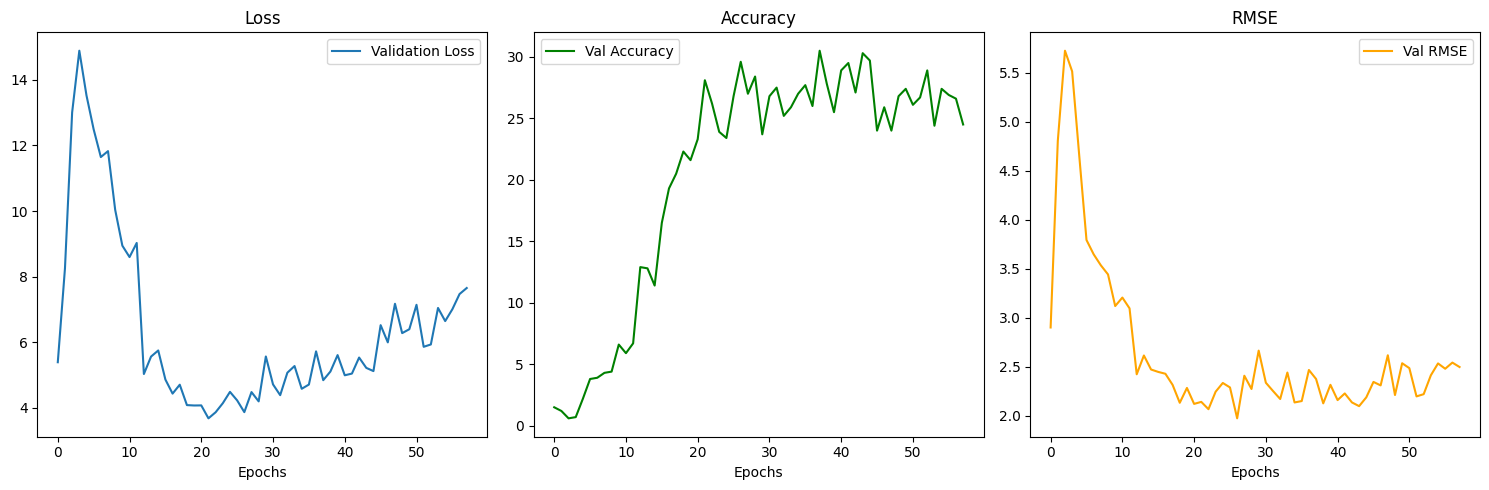

In [14]:
plt.figure(figsize=(15, 5))
# Loss
plt.subplot(1, 3, 1)
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(val_acc_history, color='green', label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

# RMSE
plt.subplot(1, 3, 3)
plt.plot(val_rmse_history, color='orange', label='Val RMSE')
plt.title('RMSE')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.savefig('results_multitask.png')
plt.show()

##Experiments and analysis(other 2 model)

## Classification-only model

In [17]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

log_interval=10
epochs = 100
batch_size = 64
test_batch_size = 1000

nll_loss = nn.NLLLoss()
smoothl1_loss = nn.SmoothL1Loss()
lambda_cnt = 0.0
lr = 1e-3 # don't change

model= DragonModel(p1=0.5, p2=0.5)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

visualizer = TrainingVisualizer(log_interval=log_interval)
visualizer.track_model(model, optimizer, lr)

patience = 20 # how many epochs we will wait until the better model with better accuracy will be founded
epochs_no_improve = 0
best_accuracy = 0.0
final_loss_class  = 0.0
final_loss_count = 0.0
best_rmse = 0.0
start_time = time.time()

val_loss_history = []
val_acc_history = []
val_rmse_history = []

for epoch in range(1, epochs + 1):
    train_epoch(
        model,
        device,
        train_loader,
        val_loader,
        optimizer,
        epochs,
        lambda_cnt,
        visualizer,
        epoch,
        log_interval,
        nll_loss,
        smoothl1_loss,
        verbose = True
    )

    rmse, loss_class, loss_count, test_loss , accuracy = test(
        model,
        device,
        val_loader,
        lambda_cnt,
        nll_loss,
        smoothl1_loss,
        visualizer,
        epoch,
        verbose = True
    )

    val_loss_history.append(test_loss)
    val_acc_history.append(accuracy)
    val_rmse_history.append(rmse)

    if accuracy > best_accuracy:
      best_accuracy = accuracy
      epochs_no_improve = 0
      torch.save(model.state_dict(), 'best_model_class.pth') # saving the best model
      final_loss_class = loss_class
      final_loss_count = loss_count
      best_rmse=rmse
    else:
      epochs_no_improve += 1

    if epochs_no_improve >= patience: break
end_time = time.time()
total_time = end_time - start_time

FigureWidget({
    'data': [{'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '386fcceb-1cbd-4f20-8559-3a7a44821887',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '6b7295da-3bcc-477a-81fd-816aa52e0cc9',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'df8f5f9a-50b9-42ef-802c-0b930d35e73c',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '1e466f85-a3c8-4c12-8b02-1e10cdfe6baa',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '23cd0d8a-e247-4c05-ad01-a2b2fc543422',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
     

FigureWidget({
    'data': [{'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'fc2a550b-552f-438c-84a7-9a0fe8c73bb8',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '5c83ce89-56a8-48ae-aea1-c9163870e776',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'bd755c05-4bfe-4e28-9a67-4b1b21c20102',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'd2724335-122b-48aa-bbbb-891c2de495b0',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '2ebd87e9-f66d-4892-b106-4f29e2457833',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
     

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '123e5743-b61c-4db1-9854-c6279ed891c7',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '6ffb7462-3096-46f8-a85a-bad73fa21185',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'd2c43005-a530-4a68-bc27-0c0223e45865',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f5a987e6-dbb0-4241-8551-a876915cbbd7',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '7

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'b7b03497-474b-4e62-8336-134bbb70a48b',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f6537ba2-0aca-462f-ac8d-4868f2dd1c0b',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '1f3207b6-162a-43a3-b3a4-663ae74fd8d7',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'fa3de7ea-b30c-4c4b-87bd-95e972cae876',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '4

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '72ddf0ff-127f-45d4-9f79-a6db0cfe5f7a',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'aa235e77-c045-41b6-b1ea-528aa4c9dd8f',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'cf0aa498-b4eb-47ff-b1b9-0db9fdb3e0bd',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'accc7876-2fc9-4caf-89d3-8d8ed79037a9',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f

Epoch 2/100:   4%|▎         | 5/141 [00:00<00:07, 17.65it/s, total loss=4.866162]

Train Epoch: 1 [0/9000 images (0%)]	Loss: 4.904100


Epoch 2/100:  11%|█         | 15/141 [00:00<00:05, 22.47it/s, total loss=4.902810]

Train Epoch: 1 [640/9000 images (7%)]	Loss: 4.869017


Epoch 2/100:  17%|█▋        | 24/141 [00:01<00:04, 23.61it/s, total loss=4.841421]

Train Epoch: 1 [1280/9000 images (14%)]	Loss: 4.793521


Epoch 2/100:  23%|██▎       | 33/141 [00:01<00:04, 23.93it/s, total loss=4.817276]

Train Epoch: 1 [1920/9000 images (21%)]	Loss: 4.855566


Epoch 2/100:  32%|███▏      | 45/141 [00:01<00:03, 24.05it/s, total loss=4.747583]

Train Epoch: 1 [2560/9000 images (28%)]	Loss: 4.732017


Epoch 2/100:  38%|███▊      | 54/141 [00:02<00:03, 23.17it/s, total loss=4.732743]

Train Epoch: 1 [3200/9000 images (36%)]	Loss: 4.788388


Epoch 2/100:  45%|████▌     | 64/141 [00:02<00:03, 23.37it/s, total loss=4.750509]

Train Epoch: 1 [3840/9000 images (43%)]	Loss: 4.727149


Epoch 2/100:  51%|█████     | 72/141 [00:03<00:02, 23.83it/s, total loss=4.684239]

Train Epoch: 1 [4480/9000 images (50%)]	Loss: 4.767028


Epoch 2/100:  60%|█████▉    | 84/141 [00:03<00:02, 23.47it/s, total loss=4.727901]

Train Epoch: 1 [5120/9000 images (57%)]	Loss: 4.742134


Epoch 2/100:  65%|██████▌   | 92/141 [00:04<00:02, 23.63it/s, total loss=4.682095]

Train Epoch: 1 [5760/9000 images (64%)]	Loss: 4.673784


Epoch 2/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.70it/s, total loss=4.716810]

Train Epoch: 1 [6400/9000 images (71%)]	Loss: 4.740362


Epoch 2/100:  79%|███████▉  | 112/141 [00:04<00:01, 23.54it/s, total loss=4.701595]

Train Epoch: 1 [7040/9000 images (78%)]	Loss: 4.721931


Epoch 2/100:  88%|████████▊ | 124/141 [00:05<00:00, 23.79it/s, total loss=4.695419]

Train Epoch: 1 [7680/9000 images (85%)]	Loss: 4.701324


Epoch 2/100:  94%|█████████▎| 132/141 [00:05<00:00, 23.59it/s, total loss=4.711984]

Train Epoch: 1 [8320/9000 images (92%)]	Loss: 4.765385


Epoch 2/100: 100%|██████████| 141/141 [00:06<00:00, 23.37it/s, total loss=4.646558]


Train Epoch: 1 [5600/9000 images (62%)]	Loss: 4.646558

Test loss: 4.6756, Accuracy: 10/1000 (1%)

Class Loss: 4.6756, Count Loss: 1.4731



Epoch 3/100:   4%|▎         | 5/141 [00:00<00:07, 17.57it/s, total loss=4.716905]

Train Epoch: 2 [0/9000 images (0%)]	Loss: 4.715115


Epoch 3/100:   9%|▉         | 13/141 [00:00<00:05, 22.03it/s, total loss=4.704251]

Train Epoch: 2 [640/9000 images (7%)]	Loss: 4.741457


Epoch 3/100:  18%|█▊        | 25/141 [00:01<00:04, 23.60it/s, total loss=4.738084]

Train Epoch: 2 [1280/9000 images (14%)]	Loss: 4.685204


Epoch 3/100:  23%|██▎       | 33/141 [00:01<00:04, 23.95it/s, total loss=4.708063]

Train Epoch: 2 [1920/9000 images (21%)]	Loss: 4.687843


Epoch 3/100:  32%|███▏      | 45/141 [00:01<00:03, 24.22it/s, total loss=4.677969]

Train Epoch: 2 [2560/9000 images (28%)]	Loss: 4.656623


Epoch 3/100:  38%|███▊      | 54/141 [00:02<00:03, 24.70it/s, total loss=4.710327]

Train Epoch: 2 [3200/9000 images (36%)]	Loss: 4.715805


Epoch 3/100:  47%|████▋     | 66/141 [00:02<00:03, 24.22it/s, total loss=4.634417]

Train Epoch: 2 [3840/9000 images (43%)]	Loss: 4.635185


Epoch 3/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.39it/s, total loss=4.634721]

Train Epoch: 2 [4480/9000 images (50%)]	Loss: 4.594218


Epoch 3/100:  60%|█████▉    | 84/141 [00:03<00:02, 24.52it/s, total loss=4.484889]

Train Epoch: 2 [5120/9000 images (57%)]	Loss: 4.627798


Epoch 3/100:  68%|██████▊   | 96/141 [00:04<00:01, 24.76it/s, total loss=4.369938]

Train Epoch: 2 [5760/9000 images (64%)]	Loss: 4.409703


Epoch 3/100:  74%|███████▍  | 105/141 [00:04<00:01, 21.75it/s, total loss=4.397994]

Train Epoch: 2 [6400/9000 images (71%)]	Loss: 4.479458


Epoch 3/100:  82%|████████▏ | 115/141 [00:04<00:01, 21.86it/s, total loss=4.293602]

Train Epoch: 2 [7040/9000 images (78%)]	Loss: 4.382068


Epoch 3/100:  87%|████████▋ | 123/141 [00:05<00:00, 22.63it/s, total loss=4.280556]

Train Epoch: 2 [7680/9000 images (85%)]	Loss: 4.221886


Epoch 3/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.06it/s, total loss=4.152212]

Train Epoch: 2 [8320/9000 images (92%)]	Loss: 4.298786


Epoch 3/100: 100%|██████████| 141/141 [00:06<00:00, 23.19it/s, total loss=4.307049]

Train Epoch: 2 [5600/9000 images (62%)]	Loss: 4.307049



Test loss: 4.2806, Accuracy: 26/1000 (3%)

Class Loss: 4.2806, Count Loss: 1.5552



Epoch 4/100:   4%|▎         | 5/141 [00:00<00:07, 17.30it/s, total loss=4.100913]

Train Epoch: 3 [0/9000 images (0%)]	Loss: 4.217567


Epoch 4/100:   9%|▉         | 13/141 [00:00<00:05, 21.45it/s, total loss=4.131574]

Train Epoch: 3 [640/9000 images (7%)]	Loss: 4.150536


Epoch 4/100:  18%|█▊        | 25/141 [00:01<00:04, 23.33it/s, total loss=4.220516]

Train Epoch: 3 [1280/9000 images (14%)]	Loss: 4.008065


Epoch 4/100:  23%|██▎       | 33/141 [00:01<00:04, 23.82it/s, total loss=4.266396]

Train Epoch: 3 [1920/9000 images (21%)]	Loss: 4.280768


Epoch 4/100:  32%|███▏      | 45/141 [00:01<00:03, 24.09it/s, total loss=4.011931]

Train Epoch: 3 [2560/9000 images (28%)]	Loss: 4.041167


Epoch 4/100:  38%|███▊      | 53/141 [00:02<00:03, 24.12it/s, total loss=4.160244]

Train Epoch: 3 [3200/9000 images (36%)]	Loss: 4.048272


Epoch 4/100:  46%|████▌     | 65/141 [00:02<00:03, 24.06it/s, total loss=4.098856]

Train Epoch: 3 [3840/9000 images (43%)]	Loss: 4.032923


Epoch 4/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.04it/s, total loss=3.959132]

Train Epoch: 3 [4480/9000 images (50%)]	Loss: 4.056195


Epoch 4/100:  60%|██████    | 85/141 [00:03<00:02, 23.83it/s, total loss=3.960534]

Train Epoch: 3 [5120/9000 images (57%)]	Loss: 4.119930


Epoch 4/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.53it/s, total loss=3.954330]

Train Epoch: 3 [5760/9000 images (64%)]	Loss: 4.161774


Epoch 4/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.65it/s, total loss=3.876858]

Train Epoch: 3 [6400/9000 images (71%)]	Loss: 3.850549


Epoch 4/100:  80%|████████  | 113/141 [00:04<00:01, 23.72it/s, total loss=3.941090]

Train Epoch: 3 [7040/9000 images (78%)]	Loss: 3.819141


Epoch 4/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.11it/s, total loss=3.657952]

Train Epoch: 3 [7680/9000 images (85%)]	Loss: 3.789069


Epoch 4/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.08it/s, total loss=3.941839]

Train Epoch: 3 [8320/9000 images (92%)]	Loss: 3.509803


Epoch 4/100: 100%|██████████| 141/141 [00:06<00:00, 23.47it/s, total loss=3.829301]

Train Epoch: 3 [5600/9000 images (62%)]	Loss: 3.829301



Test loss: 23.6917, Accuracy: 13/1000 (1%)

Class Loss: 23.6917, Count Loss: 3.9467



Epoch 5/100:   1%|          | 1/141 [00:00<00:22,  6.32it/s, total loss=3.683348]

Train Epoch: 4 [0/9000 images (0%)]	Loss: 3.745480


Epoch 5/100:   9%|▉         | 13/141 [00:00<00:05, 22.05it/s, total loss=3.738770]

Train Epoch: 4 [640/9000 images (7%)]	Loss: 3.647706


Epoch 5/100:  18%|█▊        | 25/141 [00:01<00:04, 23.72it/s, total loss=3.515768]

Train Epoch: 4 [1280/9000 images (14%)]	Loss: 3.549122


Epoch 5/100:  23%|██▎       | 33/141 [00:01<00:04, 23.77it/s, total loss=3.563082]

Train Epoch: 4 [1920/9000 images (21%)]	Loss: 3.699212


Epoch 5/100:  32%|███▏      | 45/141 [00:01<00:04, 23.94it/s, total loss=3.614190]

Train Epoch: 4 [2560/9000 images (28%)]	Loss: 3.660401


Epoch 5/100:  38%|███▊      | 53/141 [00:02<00:03, 24.04it/s, total loss=3.435718]

Train Epoch: 4 [3200/9000 images (36%)]	Loss: 3.441837


Epoch 5/100:  46%|████▌     | 65/141 [00:02<00:03, 24.23it/s, total loss=3.462760]

Train Epoch: 4 [3840/9000 images (43%)]	Loss: 3.644905


Epoch 5/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.09it/s, total loss=3.485481]

Train Epoch: 4 [4480/9000 images (50%)]	Loss: 3.628959


Epoch 5/100:  60%|██████    | 85/141 [00:03<00:02, 24.18it/s, total loss=3.464120]

Train Epoch: 4 [5120/9000 images (57%)]	Loss: 3.587770


Epoch 5/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.20it/s, total loss=3.432488]

Train Epoch: 4 [5760/9000 images (64%)]	Loss: 3.291801


Epoch 5/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.41it/s, total loss=3.458634]

Train Epoch: 4 [6400/9000 images (71%)]	Loss: 3.273961


Epoch 5/100:  80%|████████  | 113/141 [00:04<00:01, 24.21it/s, total loss=3.348620]

Train Epoch: 4 [7040/9000 images (78%)]	Loss: 3.383774


Epoch 5/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.27it/s, total loss=3.327166]

Train Epoch: 4 [7680/9000 images (85%)]	Loss: 3.316923


Epoch 5/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.31it/s, total loss=3.059078]

Train Epoch: 4 [8320/9000 images (92%)]	Loss: 3.247275


Epoch 5/100: 100%|██████████| 141/141 [00:05<00:00, 23.76it/s, total loss=3.036061]

Train Epoch: 4 [5600/9000 images (62%)]	Loss: 3.036061



Test loss: 49.4715, Accuracy: 19/1000 (2%)

Class Loss: 49.4715, Count Loss: 6.9201



Epoch 6/100:   1%|          | 1/141 [00:00<00:21,  6.37it/s, total loss=3.291435]

Train Epoch: 5 [0/9000 images (0%)]	Loss: 3.080362


Epoch 6/100:   9%|▉         | 13/141 [00:00<00:05, 22.54it/s, total loss=3.070517]

Train Epoch: 5 [640/9000 images (7%)]	Loss: 3.419642


Epoch 6/100:  18%|█▊        | 25/141 [00:01<00:04, 23.95it/s, total loss=3.111957]

Train Epoch: 5 [1280/9000 images (14%)]	Loss: 3.175754


Epoch 6/100:  23%|██▎       | 33/141 [00:01<00:04, 24.37it/s, total loss=3.132120]

Train Epoch: 5 [1920/9000 images (21%)]	Loss: 3.200802


Epoch 6/100:  32%|███▏      | 45/141 [00:01<00:03, 24.27it/s, total loss=3.131845]

Train Epoch: 5 [2560/9000 images (28%)]	Loss: 3.187827


Epoch 6/100:  38%|███▊      | 53/141 [00:02<00:03, 24.32it/s, total loss=3.024711]

Train Epoch: 5 [3200/9000 images (36%)]	Loss: 3.137981


Epoch 6/100:  46%|████▌     | 65/141 [00:02<00:03, 24.16it/s, total loss=2.979244]

Train Epoch: 5 [3840/9000 images (43%)]	Loss: 3.030071


Epoch 6/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.21it/s, total loss=3.035825]

Train Epoch: 5 [4480/9000 images (50%)]	Loss: 3.122820


Epoch 6/100:  60%|██████    | 85/141 [00:03<00:02, 24.29it/s, total loss=2.838429]

Train Epoch: 5 [5120/9000 images (57%)]	Loss: 3.070391


Epoch 6/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.28it/s, total loss=2.826465]

Train Epoch: 5 [5760/9000 images (64%)]	Loss: 3.148862


Epoch 6/100:  74%|███████▍  | 104/141 [00:04<00:01, 25.33it/s, total loss=2.766672]

Train Epoch: 5 [6400/9000 images (71%)]	Loss: 2.760074


Epoch 6/100:  82%|████████▏ | 116/141 [00:04<00:01, 24.71it/s, total loss=2.727914]

Train Epoch: 5 [7040/9000 images (78%)]	Loss: 3.061444


Epoch 6/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.01it/s, total loss=2.698856]

Train Epoch: 5 [7680/9000 images (85%)]	Loss: 2.718667


Epoch 6/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.21it/s, total loss=3.020394]

Train Epoch: 5 [8320/9000 images (92%)]	Loss: 2.821456


Epoch 6/100: 100%|██████████| 141/141 [00:05<00:00, 23.90it/s, total loss=2.753535]

Train Epoch: 5 [5600/9000 images (62%)]	Loss: 2.753535



Test loss: 48.6997, Accuracy: 12/1000 (1%)

Class Loss: 48.6997, Count Loss: 6.2822



Epoch 7/100:   1%|          | 1/141 [00:00<00:22,  6.36it/s, total loss=2.584222]

Train Epoch: 6 [0/9000 images (0%)]	Loss: 3.086602


Epoch 7/100:   9%|▉         | 13/141 [00:00<00:05, 22.64it/s, total loss=3.055836]

Train Epoch: 6 [640/9000 images (7%)]	Loss: 2.894878


Epoch 7/100:  18%|█▊        | 25/141 [00:01<00:04, 24.07it/s, total loss=2.917576]

Train Epoch: 6 [1280/9000 images (14%)]	Loss: 2.551453


Epoch 7/100:  23%|██▎       | 33/141 [00:01<00:04, 24.36it/s, total loss=2.948922]

Train Epoch: 6 [1920/9000 images (21%)]	Loss: 2.770552


Epoch 7/100:  32%|███▏      | 45/141 [00:01<00:03, 24.43it/s, total loss=2.635846]

Train Epoch: 6 [2560/9000 images (28%)]	Loss: 2.466168


Epoch 7/100:  38%|███▊      | 54/141 [00:02<00:03, 24.97it/s, total loss=2.574132]

Train Epoch: 6 [3200/9000 images (36%)]	Loss: 2.423150


Epoch 7/100:  45%|████▍     | 63/141 [00:02<00:03, 24.69it/s, total loss=2.491697]

Train Epoch: 6 [3840/9000 images (43%)]	Loss: 2.515100


Epoch 7/100:  53%|█████▎    | 75/141 [00:03<00:02, 25.00it/s, total loss=2.463703]

Train Epoch: 6 [4480/9000 images (50%)]	Loss: 2.437225


Epoch 7/100:  60%|█████▉    | 84/141 [00:03<00:02, 23.91it/s, total loss=2.542801]

Train Epoch: 6 [5120/9000 images (57%)]	Loss: 2.649926


Epoch 7/100:  66%|██████▌   | 93/141 [00:03<00:01, 24.86it/s, total loss=2.382819]

Train Epoch: 6 [5760/9000 images (64%)]	Loss: 2.537490


Epoch 7/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.19it/s, total loss=2.619274]

Train Epoch: 6 [6400/9000 images (71%)]	Loss: 2.595459


Epoch 7/100:  79%|███████▉  | 112/141 [00:04<00:01, 23.12it/s, total loss=2.435739]

Train Epoch: 6 [7040/9000 images (78%)]	Loss: 2.287347


Epoch 7/100:  88%|████████▊ | 124/141 [00:05<00:00, 23.00it/s, total loss=2.456878]

Train Epoch: 6 [7680/9000 images (85%)]	Loss: 2.388437


Epoch 7/100:  94%|█████████▎| 132/141 [00:05<00:00, 23.13it/s, total loss=2.287946]

Train Epoch: 6 [8320/9000 images (92%)]	Loss: 2.210878


Epoch 7/100: 100%|██████████| 141/141 [00:05<00:00, 23.56it/s, total loss=2.458753]

Train Epoch: 6 [5600/9000 images (62%)]	Loss: 2.458753



Test loss: 74.5771, Accuracy: 10/1000 (1%)

Class Loss: 74.5771, Count Loss: 7.9949



Epoch 8/100:   1%|          | 1/141 [00:00<00:21,  6.51it/s, total loss=2.581939]

Train Epoch: 7 [0/9000 images (0%)]	Loss: 2.482988


Epoch 8/100:   9%|▉         | 13/141 [00:00<00:05, 22.45it/s, total loss=2.089590]

Train Epoch: 7 [640/9000 images (7%)]	Loss: 2.376024


Epoch 8/100:  18%|█▊        | 26/141 [00:01<00:04, 24.83it/s, total loss=2.091264]

Train Epoch: 7 [1280/9000 images (14%)]	Loss: 2.229462


Epoch 8/100:  25%|██▍       | 35/141 [00:01<00:04, 23.96it/s, total loss=2.429536]

Train Epoch: 7 [1920/9000 images (21%)]	Loss: 2.197068


Epoch 8/100:  31%|███       | 44/141 [00:01<00:03, 24.75it/s, total loss=2.161460]

Train Epoch: 7 [2560/9000 images (28%)]	Loss: 2.296504


Epoch 8/100:  40%|███▉      | 56/141 [00:02<00:03, 24.77it/s, total loss=2.115586]

Train Epoch: 7 [3200/9000 images (36%)]	Loss: 2.261926


Epoch 8/100:  46%|████▌     | 65/141 [00:02<00:03, 23.01it/s, total loss=2.391038]

Train Epoch: 7 [3840/9000 images (43%)]	Loss: 2.252586


Epoch 8/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.06it/s, total loss=2.233869]

Train Epoch: 7 [4480/9000 images (50%)]	Loss: 2.278515


Epoch 8/100:  60%|██████    | 85/141 [00:03<00:02, 23.03it/s, total loss=2.047201]

Train Epoch: 7 [5120/9000 images (57%)]	Loss: 2.154131


Epoch 8/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.51it/s, total loss=2.018818]

Train Epoch: 7 [5760/9000 images (64%)]	Loss: 2.230375


Epoch 8/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.69it/s, total loss=2.074242]

Train Epoch: 7 [6400/9000 images (71%)]	Loss: 2.288604


Epoch 8/100:  80%|████████  | 113/141 [00:04<00:01, 23.76it/s, total loss=2.270517]

Train Epoch: 7 [7040/9000 images (78%)]	Loss: 2.220534


Epoch 8/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.15it/s, total loss=2.161250]

Train Epoch: 7 [7680/9000 images (85%)]	Loss: 2.500048


Epoch 8/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.16it/s, total loss=2.052772]

Train Epoch: 7 [8320/9000 images (92%)]	Loss: 2.044685


Epoch 8/100: 100%|██████████| 141/141 [00:05<00:00, 23.64it/s, total loss=1.966714]

Train Epoch: 7 [5600/9000 images (62%)]	Loss: 1.966714



Test loss: 97.4237, Accuracy: 10/1000 (1%)

Class Loss: 97.4237, Count Loss: 10.3243



Epoch 9/100:   1%|          | 1/141 [00:00<00:22,  6.34it/s, total loss=1.923700]

Train Epoch: 8 [0/9000 images (0%)]	Loss: 1.968776


Epoch 9/100:   9%|▉         | 13/141 [00:00<00:05, 22.24it/s, total loss=2.239594]

Train Epoch: 8 [640/9000 images (7%)]	Loss: 2.015255


Epoch 9/100:  18%|█▊        | 25/141 [00:01<00:04, 23.64it/s, total loss=1.970964]

Train Epoch: 8 [1280/9000 images (14%)]	Loss: 1.888183


Epoch 9/100:  23%|██▎       | 33/141 [00:01<00:04, 24.00it/s, total loss=2.038513]

Train Epoch: 8 [1920/9000 images (21%)]	Loss: 2.214996


Epoch 9/100:  32%|███▏      | 45/141 [00:01<00:03, 24.33it/s, total loss=2.186140]

Train Epoch: 8 [2560/9000 images (28%)]	Loss: 2.020886


Epoch 9/100:  38%|███▊      | 53/141 [00:02<00:03, 24.36it/s, total loss=1.897851]

Train Epoch: 8 [3200/9000 images (36%)]	Loss: 1.890129


Epoch 9/100:  46%|████▌     | 65/141 [00:02<00:03, 24.54it/s, total loss=1.925758]

Train Epoch: 8 [3840/9000 images (43%)]	Loss: 2.028972


Epoch 9/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.57it/s, total loss=2.014116]

Train Epoch: 8 [4480/9000 images (50%)]	Loss: 2.121499


Epoch 9/100:  60%|██████    | 85/141 [00:03<00:02, 24.48it/s, total loss=1.978867]

Train Epoch: 8 [5120/9000 images (57%)]	Loss: 2.001819


Epoch 9/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.34it/s, total loss=2.017475]

Train Epoch: 8 [5760/9000 images (64%)]	Loss: 2.077784


Epoch 9/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.44it/s, total loss=2.045887]

Train Epoch: 8 [6400/9000 images (71%)]	Loss: 1.950327


Epoch 9/100:  80%|████████  | 113/141 [00:04<00:01, 24.23it/s, total loss=2.012058]

Train Epoch: 8 [7040/9000 images (78%)]	Loss: 2.121272


Epoch 9/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.89it/s, total loss=1.985016]

Train Epoch: 8 [7680/9000 images (85%)]	Loss: 2.236090


Epoch 9/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.70it/s, total loss=1.949365]

Train Epoch: 8 [8320/9000 images (92%)]	Loss: 1.963141


Epoch 9/100: 100%|██████████| 141/141 [00:05<00:00, 23.78it/s, total loss=2.093730]

Train Epoch: 8 [5600/9000 images (62%)]	Loss: 2.093730



Test loss: 96.5627, Accuracy: 14/1000 (1%)

Class Loss: 96.5627, Count Loss: 9.3412



Epoch 10/100:   1%|          | 1/141 [00:00<00:21,  6.38it/s, total loss=2.172310]

Train Epoch: 9 [0/9000 images (0%)]	Loss: 1.965844


Epoch 10/100:  11%|█         | 15/141 [00:00<00:05, 21.18it/s, total loss=1.745228]

Train Epoch: 9 [640/9000 images (7%)]	Loss: 1.854919


Epoch 10/100:  16%|█▋        | 23/141 [00:01<00:05, 22.72it/s, total loss=1.942837]

Train Epoch: 9 [1280/9000 images (14%)]	Loss: 1.986132


Epoch 10/100:  25%|██▍       | 35/141 [00:01<00:04, 23.54it/s, total loss=2.145039]

Train Epoch: 9 [1920/9000 images (21%)]	Loss: 1.856087


Epoch 10/100:  32%|███▏      | 45/141 [00:02<00:04, 22.90it/s, total loss=1.974457]

Train Epoch: 9 [2560/9000 images (28%)]	Loss: 1.808065


Epoch 10/100:  38%|███▊      | 53/141 [00:02<00:03, 23.46it/s, total loss=1.827785]

Train Epoch: 9 [3200/9000 images (36%)]	Loss: 2.113806


Epoch 10/100:  46%|████▌     | 65/141 [00:02<00:03, 24.07it/s, total loss=1.759234]

Train Epoch: 9 [3840/9000 images (43%)]	Loss: 1.820742


Epoch 10/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.16it/s, total loss=1.854131]

Train Epoch: 9 [4480/9000 images (50%)]	Loss: 1.636427


Epoch 10/100:  60%|██████    | 85/141 [00:03<00:02, 24.45it/s, total loss=2.025476]

Train Epoch: 9 [5120/9000 images (57%)]	Loss: 1.832258


Epoch 10/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.08it/s, total loss=1.918840]

Train Epoch: 9 [5760/9000 images (64%)]	Loss: 1.817596


Epoch 10/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.41it/s, total loss=2.007181]

Train Epoch: 9 [6400/9000 images (71%)]	Loss: 2.098222


Epoch 10/100:  80%|████████  | 113/141 [00:04<00:01, 24.19it/s, total loss=1.892447]

Train Epoch: 9 [7040/9000 images (78%)]	Loss: 1.896458


Epoch 10/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.30it/s, total loss=1.709100]

Train Epoch: 9 [7680/9000 images (85%)]	Loss: 2.004957


Epoch 10/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.22it/s, total loss=1.802611]

Train Epoch: 9 [8320/9000 images (92%)]	Loss: 1.797579


Epoch 10/100: 100%|██████████| 141/141 [00:05<00:00, 23.57it/s, total loss=1.800293]

Train Epoch: 9 [5600/9000 images (62%)]	Loss: 1.800293



Test loss: 111.9256, Accuracy: 14/1000 (1%)

Class Loss: 111.9256, Count Loss: 10.2412



Epoch 11/100:   1%|          | 1/141 [00:00<00:22,  6.35it/s, total loss=1.720684]

Train Epoch: 10 [0/9000 images (0%)]	Loss: 1.965260


Epoch 11/100:   9%|▉         | 13/141 [00:00<00:05, 22.27it/s, total loss=1.884936]

Train Epoch: 10 [640/9000 images (7%)]	Loss: 1.812111


Epoch 11/100:  18%|█▊        | 25/141 [00:01<00:04, 23.67it/s, total loss=1.818746]

Train Epoch: 10 [1280/9000 images (14%)]	Loss: 1.795592


Epoch 11/100:  23%|██▎       | 33/141 [00:01<00:04, 23.90it/s, total loss=1.824110]

Train Epoch: 10 [1920/9000 images (21%)]	Loss: 2.200395


Epoch 11/100:  32%|███▏      | 45/141 [00:01<00:03, 24.27it/s, total loss=1.766547]

Train Epoch: 10 [2560/9000 images (28%)]	Loss: 1.803095


Epoch 11/100:  38%|███▊      | 53/141 [00:02<00:03, 24.32it/s, total loss=1.811235]

Train Epoch: 10 [3200/9000 images (36%)]	Loss: 1.650143


Epoch 11/100:  46%|████▌     | 65/141 [00:02<00:03, 24.38it/s, total loss=1.920082]

Train Epoch: 10 [3840/9000 images (43%)]	Loss: 1.852119


Epoch 11/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.40it/s, total loss=1.965161]

Train Epoch: 10 [4480/9000 images (50%)]	Loss: 1.624189


Epoch 11/100:  60%|██████    | 85/141 [00:03<00:02, 24.56it/s, total loss=1.707539]

Train Epoch: 10 [5120/9000 images (57%)]	Loss: 1.674779


Epoch 11/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.28it/s, total loss=1.743098]

Train Epoch: 10 [5760/9000 images (64%)]	Loss: 1.888101


Epoch 11/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.92it/s, total loss=1.827772]

Train Epoch: 10 [6400/9000 images (71%)]	Loss: 1.715333


Epoch 11/100:  82%|████████▏ | 116/141 [00:04<00:01, 24.60it/s, total loss=1.765880]

Train Epoch: 10 [7040/9000 images (78%)]	Loss: 1.889722


Epoch 11/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.59it/s, total loss=1.767748]

Train Epoch: 10 [7680/9000 images (85%)]	Loss: 1.552307


Epoch 11/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.51it/s, total loss=1.814143]

Train Epoch: 10 [8320/9000 images (92%)]	Loss: 1.660989


Epoch 11/100: 100%|██████████| 141/141 [00:05<00:00, 23.78it/s, total loss=1.804239]

Train Epoch: 10 [5600/9000 images (62%)]	Loss: 1.804239



Test loss: 125.5746, Accuracy: 10/1000 (1%)

Class Loss: 125.5746, Count Loss: 10.8173



Epoch 12/100:   1%|          | 1/141 [00:00<00:23,  6.05it/s, total loss=1.770097]

Train Epoch: 11 [0/9000 images (0%)]	Loss: 1.862308


Epoch 12/100:   9%|▉         | 13/141 [00:00<00:05, 21.60it/s, total loss=1.638748]

Train Epoch: 11 [640/9000 images (7%)]	Loss: 1.792974


Epoch 12/100:  18%|█▊        | 25/141 [00:01<00:04, 23.58it/s, total loss=1.746643]

Train Epoch: 11 [1280/9000 images (14%)]	Loss: 1.852824


Epoch 12/100:  23%|██▎       | 33/141 [00:01<00:04, 23.80it/s, total loss=1.826318]

Train Epoch: 11 [1920/9000 images (21%)]	Loss: 1.703139


Epoch 12/100:  32%|███▏      | 45/141 [00:02<00:04, 23.80it/s, total loss=1.698565]

Train Epoch: 11 [2560/9000 images (28%)]	Loss: 1.807755


Epoch 12/100:  38%|███▊      | 53/141 [00:02<00:03, 23.81it/s, total loss=1.648541]

Train Epoch: 11 [3200/9000 images (36%)]	Loss: 2.090185


Epoch 12/100:  46%|████▌     | 65/141 [00:02<00:03, 23.73it/s, total loss=1.648008]

Train Epoch: 11 [3840/9000 images (43%)]	Loss: 1.777345


Epoch 12/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.61it/s, total loss=1.692300]

Train Epoch: 11 [4480/9000 images (50%)]	Loss: 1.654668


Epoch 12/100:  60%|██████    | 85/141 [00:03<00:02, 23.72it/s, total loss=1.803856]

Train Epoch: 11 [5120/9000 images (57%)]	Loss: 1.694826


Epoch 12/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.78it/s, total loss=1.702531]

Train Epoch: 11 [5760/9000 images (64%)]	Loss: 1.680801


Epoch 12/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.88it/s, total loss=2.000430]

Train Epoch: 11 [6400/9000 images (71%)]	Loss: 1.474406


Epoch 12/100:  80%|████████  | 113/141 [00:04<00:01, 23.76it/s, total loss=1.808097]

Train Epoch: 11 [7040/9000 images (78%)]	Loss: 1.728321


Epoch 12/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.79it/s, total loss=1.658736]

Train Epoch: 11 [7680/9000 images (85%)]	Loss: 1.897726


Epoch 12/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.78it/s, total loss=1.783989]

Train Epoch: 11 [8320/9000 images (92%)]	Loss: 2.016979


Epoch 12/100: 100%|██████████| 141/141 [00:06<00:00, 23.36it/s, total loss=1.608865]

Train Epoch: 11 [5600/9000 images (62%)]	Loss: 1.608865



Test loss: 119.7785, Accuracy: 10/1000 (1%)

Class Loss: 119.7785, Count Loss: 9.3179



Epoch 13/100:   1%|          | 1/141 [00:00<00:22,  6.31it/s, total loss=1.487319]

Train Epoch: 12 [0/9000 images (0%)]	Loss: 1.774211


Epoch 13/100:   9%|▉         | 13/141 [00:00<00:05, 22.05it/s, total loss=1.832921]

Train Epoch: 12 [640/9000 images (7%)]	Loss: 1.499973


Epoch 13/100:  18%|█▊        | 25/141 [00:01<00:04, 23.33it/s, total loss=1.736226]

Train Epoch: 12 [1280/9000 images (14%)]	Loss: 1.620662


Epoch 13/100:  23%|██▎       | 33/141 [00:01<00:04, 23.73it/s, total loss=1.610883]

Train Epoch: 12 [1920/9000 images (21%)]	Loss: 1.805557


Epoch 13/100:  32%|███▏      | 45/141 [00:01<00:04, 23.87it/s, total loss=1.730937]

Train Epoch: 12 [2560/9000 images (28%)]	Loss: 1.577301


Epoch 13/100:  38%|███▊      | 53/141 [00:02<00:03, 23.82it/s, total loss=2.112278]

Train Epoch: 12 [3200/9000 images (36%)]	Loss: 1.601320


Epoch 13/100:  46%|████▌     | 65/141 [00:02<00:03, 23.53it/s, total loss=1.653866]

Train Epoch: 12 [3840/9000 images (43%)]	Loss: 1.753624


Epoch 13/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.53it/s, total loss=1.602647]

Train Epoch: 12 [4480/9000 images (50%)]	Loss: 1.674821


Epoch 13/100:  60%|██████    | 85/141 [00:03<00:02, 23.34it/s, total loss=1.568763]

Train Epoch: 12 [5120/9000 images (57%)]	Loss: 1.705665


Epoch 13/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.51it/s, total loss=1.568651]

Train Epoch: 12 [5760/9000 images (64%)]	Loss: 1.572564


Epoch 13/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.01it/s, total loss=1.503501]

Train Epoch: 12 [6400/9000 images (71%)]	Loss: 1.431471


Epoch 13/100:  80%|████████  | 113/141 [00:04<00:01, 23.96it/s, total loss=1.630828]

Train Epoch: 12 [7040/9000 images (78%)]	Loss: 1.672338


Epoch 13/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.20it/s, total loss=1.560163]

Train Epoch: 12 [7680/9000 images (85%)]	Loss: 1.633008


Epoch 13/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.89it/s, total loss=1.759670]

Train Epoch: 12 [8320/9000 images (92%)]	Loss: 1.618740


Epoch 13/100: 100%|██████████| 141/141 [00:06<00:00, 23.44it/s, total loss=1.478644]

Train Epoch: 12 [5600/9000 images (62%)]	Loss: 1.478644



Test loss: 139.2567, Accuracy: 17/1000 (2%)

Class Loss: 139.2567, Count Loss: 10.7760



Epoch 14/100:   1%|          | 1/141 [00:00<00:21,  6.38it/s, total loss=1.499285]

Train Epoch: 13 [0/9000 images (0%)]	Loss: 1.550656


Epoch 14/100:   9%|▉         | 13/141 [00:00<00:05, 22.27it/s, total loss=1.379103]

Train Epoch: 13 [640/9000 images (7%)]	Loss: 1.430472


Epoch 14/100:  18%|█▊        | 25/141 [00:01<00:04, 23.76it/s, total loss=1.397549]

Train Epoch: 13 [1280/9000 images (14%)]	Loss: 1.637098


Epoch 14/100:  23%|██▎       | 33/141 [00:01<00:04, 24.20it/s, total loss=1.504700]

Train Epoch: 13 [1920/9000 images (21%)]	Loss: 1.527892


Epoch 14/100:  32%|███▏      | 45/141 [00:01<00:03, 24.84it/s, total loss=1.584565]

Train Epoch: 13 [2560/9000 images (28%)]	Loss: 1.548548


Epoch 14/100:  38%|███▊      | 54/141 [00:02<00:03, 24.74it/s, total loss=1.571317]

Train Epoch: 13 [3200/9000 images (36%)]	Loss: 1.696327


Epoch 14/100:  45%|████▍     | 63/141 [00:02<00:03, 25.02it/s, total loss=1.581926]

Train Epoch: 13 [3840/9000 images (43%)]	Loss: 1.676329


Epoch 14/100:  51%|█████     | 72/141 [00:03<00:02, 23.71it/s, total loss=1.396058]

Train Epoch: 13 [4480/9000 images (50%)]	Loss: 1.332703


Epoch 14/100:  60%|█████▉    | 84/141 [00:03<00:02, 23.74it/s, total loss=1.415267]

Train Epoch: 13 [5120/9000 images (57%)]	Loss: 1.543442


Epoch 14/100:  65%|██████▌   | 92/141 [00:03<00:02, 24.05it/s, total loss=1.492819]

Train Epoch: 13 [5760/9000 images (64%)]	Loss: 1.674999


Epoch 14/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.41it/s, total loss=1.499589]

Train Epoch: 13 [6400/9000 images (71%)]	Loss: 1.717916


Epoch 14/100:  80%|████████  | 113/141 [00:04<00:01, 25.02it/s, total loss=1.552651]

Train Epoch: 13 [7040/9000 images (78%)]	Loss: 1.554566


Epoch 14/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.72it/s, total loss=1.648310]

Train Epoch: 13 [7680/9000 images (85%)]	Loss: 1.518450


Epoch 14/100:  95%|█████████▌| 134/141 [00:05<00:00, 23.67it/s, total loss=1.711025]

Train Epoch: 13 [8320/9000 images (92%)]	Loss: 1.742974


Epoch 14/100: 100%|██████████| 141/141 [00:05<00:00, 23.88it/s, total loss=1.525328]

Train Epoch: 13 [5600/9000 images (62%)]	Loss: 1.525328



Test loss: 141.2839, Accuracy: 19/1000 (2%)

Class Loss: 141.2839, Count Loss: 10.8700



Epoch 15/100:   1%|          | 1/141 [00:00<00:21,  6.37it/s, total loss=1.451592]

Train Epoch: 14 [0/9000 images (0%)]	Loss: 1.396748


Epoch 15/100:   9%|▉         | 13/141 [00:00<00:05, 22.13it/s, total loss=1.815179]

Train Epoch: 14 [640/9000 images (7%)]	Loss: 1.619310


Epoch 15/100:  18%|█▊        | 25/141 [00:01<00:05, 23.01it/s, total loss=1.541962]

Train Epoch: 14 [1280/9000 images (14%)]	Loss: 1.543823


Epoch 15/100:  23%|██▎       | 33/141 [00:01<00:04, 23.28it/s, total loss=1.572958]

Train Epoch: 14 [1920/9000 images (21%)]	Loss: 1.483186


Epoch 15/100:  32%|███▏      | 45/141 [00:01<00:03, 24.14it/s, total loss=1.624033]

Train Epoch: 14 [2560/9000 images (28%)]	Loss: 1.330718


Epoch 15/100:  38%|███▊      | 53/141 [00:02<00:03, 23.94it/s, total loss=1.682020]

Train Epoch: 14 [3200/9000 images (36%)]	Loss: 1.422366


Epoch 15/100:  46%|████▌     | 65/141 [00:02<00:03, 24.14it/s, total loss=1.488822]

Train Epoch: 14 [3840/9000 images (43%)]	Loss: 1.678317


Epoch 15/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.05it/s, total loss=1.513019]

Train Epoch: 14 [4480/9000 images (50%)]	Loss: 1.524834


Epoch 15/100:  60%|██████    | 85/141 [00:03<00:02, 24.08it/s, total loss=1.480898]

Train Epoch: 14 [5120/9000 images (57%)]	Loss: 1.507889


Epoch 15/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.11it/s, total loss=1.498403]

Train Epoch: 14 [5760/9000 images (64%)]	Loss: 1.457934


Epoch 15/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.19it/s, total loss=1.448063]

Train Epoch: 14 [6400/9000 images (71%)]	Loss: 1.455680


Epoch 15/100:  80%|████████  | 113/141 [00:04<00:01, 24.06it/s, total loss=1.531553]

Train Epoch: 14 [7040/9000 images (78%)]	Loss: 1.462992


Epoch 15/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.31it/s, total loss=1.383190]

Train Epoch: 14 [7680/9000 images (85%)]	Loss: 1.554742


Epoch 15/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.29it/s, total loss=1.502259]

Train Epoch: 14 [8320/9000 images (92%)]	Loss: 1.569778


Epoch 15/100: 100%|██████████| 141/141 [00:05<00:00, 23.66it/s, total loss=1.431868]

Train Epoch: 14 [5600/9000 images (62%)]	Loss: 1.431868



Test loss: 132.0952, Accuracy: 20/1000 (2%)

Class Loss: 132.0952, Count Loss: 9.8978



Epoch 16/100:   1%|          | 1/141 [00:00<00:22,  6.28it/s, total loss=1.535118]

Train Epoch: 15 [0/9000 images (0%)]	Loss: 1.434303


Epoch 16/100:   9%|▉         | 13/141 [00:00<00:05, 22.37it/s, total loss=1.401418]

Train Epoch: 15 [640/9000 images (7%)]	Loss: 1.381036


Epoch 16/100:  18%|█▊        | 25/141 [00:01<00:04, 23.41it/s, total loss=1.339273]

Train Epoch: 15 [1280/9000 images (14%)]	Loss: 1.380273


Epoch 16/100:  23%|██▎       | 33/141 [00:01<00:04, 23.56it/s, total loss=1.481294]

Train Epoch: 15 [1920/9000 images (21%)]	Loss: 1.307287


Epoch 16/100:  32%|███▏      | 45/141 [00:01<00:04, 23.62it/s, total loss=1.217961]

Train Epoch: 15 [2560/9000 images (28%)]	Loss: 1.585188


Epoch 16/100:  38%|███▊      | 53/141 [00:02<00:03, 23.79it/s, total loss=1.418913]

Train Epoch: 15 [3200/9000 images (36%)]	Loss: 1.411482


Epoch 16/100:  46%|████▌     | 65/141 [00:02<00:03, 23.85it/s, total loss=1.487412]

Train Epoch: 15 [3840/9000 images (43%)]	Loss: 1.428162


Epoch 16/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.24it/s, total loss=1.303484]

Train Epoch: 15 [4480/9000 images (50%)]	Loss: 1.358877


Epoch 16/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.45it/s, total loss=1.397772]

Train Epoch: 15 [5120/9000 images (57%)]	Loss: 1.639807


Epoch 16/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.93it/s, total loss=1.231599]

Train Epoch: 15 [5760/9000 images (64%)]	Loss: 1.356749


Epoch 16/100:  73%|███████▎  | 103/141 [00:04<00:01, 24.34it/s, total loss=1.232162]

Train Epoch: 15 [6400/9000 images (71%)]	Loss: 1.428869


Epoch 16/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.88it/s, total loss=1.293379]

Train Epoch: 15 [7040/9000 images (78%)]	Loss: 1.403824


Epoch 16/100:  87%|████████▋ | 123/141 [00:05<00:00, 23.89it/s, total loss=1.457024]

Train Epoch: 15 [7680/9000 images (85%)]	Loss: 1.462092


Epoch 16/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.10it/s, total loss=1.336996]

Train Epoch: 15 [8320/9000 images (92%)]	Loss: 1.570277


Epoch 16/100: 100%|██████████| 141/141 [00:06<00:00, 23.35it/s, total loss=1.372210]

Train Epoch: 15 [5600/9000 images (62%)]	Loss: 1.372210



Test loss: 170.2897, Accuracy: 17/1000 (2%)

Class Loss: 170.2897, Count Loss: 12.5114



Epoch 17/100:   1%|          | 1/141 [00:00<00:22,  6.32it/s, total loss=1.278211]

Train Epoch: 16 [0/9000 images (0%)]	Loss: 1.436600


Epoch 17/100:   9%|▉         | 13/141 [00:00<00:05, 22.03it/s, total loss=1.341266]

Train Epoch: 16 [640/9000 images (7%)]	Loss: 1.254767


Epoch 17/100:  18%|█▊        | 25/141 [00:01<00:04, 23.28it/s, total loss=1.478971]

Train Epoch: 16 [1280/9000 images (14%)]	Loss: 1.372029


Epoch 17/100:  23%|██▎       | 33/141 [00:01<00:04, 23.72it/s, total loss=1.359774]

Train Epoch: 16 [1920/9000 images (21%)]	Loss: 1.304581


Epoch 17/100:  32%|███▏      | 45/141 [00:01<00:03, 24.03it/s, total loss=1.453033]

Train Epoch: 16 [2560/9000 images (28%)]	Loss: 1.481651


Epoch 17/100:  38%|███▊      | 53/141 [00:02<00:03, 24.13it/s, total loss=1.394112]

Train Epoch: 16 [3200/9000 images (36%)]	Loss: 1.587921


Epoch 17/100:  46%|████▌     | 65/141 [00:02<00:03, 23.37it/s, total loss=1.389378]

Train Epoch: 16 [3840/9000 images (43%)]	Loss: 1.324594


Epoch 17/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.24it/s, total loss=1.267685]

Train Epoch: 16 [4480/9000 images (50%)]	Loss: 1.325308


Epoch 17/100:  60%|██████    | 85/141 [00:03<00:02, 23.57it/s, total loss=1.480325]

Train Epoch: 16 [5120/9000 images (57%)]	Loss: 1.469066


Epoch 17/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.39it/s, total loss=1.237379]

Train Epoch: 16 [5760/9000 images (64%)]	Loss: 1.283659


Epoch 17/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.62it/s, total loss=1.367192]

Train Epoch: 16 [6400/9000 images (71%)]	Loss: 1.437459


Epoch 17/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.12it/s, total loss=1.525079]

Train Epoch: 16 [7040/9000 images (78%)]	Loss: 1.406432


Epoch 17/100:  87%|████████▋ | 123/141 [00:05<00:00, 23.51it/s, total loss=1.561693]

Train Epoch: 16 [7680/9000 images (85%)]	Loss: 1.515939


Epoch 17/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.46it/s, total loss=1.478014]

Train Epoch: 16 [8320/9000 images (92%)]	Loss: 1.237627


Epoch 17/100: 100%|██████████| 141/141 [00:06<00:00, 23.24it/s, total loss=1.310096]

Train Epoch: 16 [5600/9000 images (62%)]	Loss: 1.310096



Test loss: 168.1873, Accuracy: 22/1000 (2%)

Class Loss: 168.1873, Count Loss: 11.6929



Epoch 18/100:   1%|          | 1/141 [00:00<00:23,  6.05it/s, total loss=1.243605]

Train Epoch: 17 [0/9000 images (0%)]	Loss: 1.178940


Epoch 18/100:   9%|▉         | 13/141 [00:00<00:05, 21.84it/s, total loss=1.239258]

Train Epoch: 17 [640/9000 images (7%)]	Loss: 1.259037


Epoch 18/100:  18%|█▊        | 25/141 [00:01<00:04, 23.63it/s, total loss=1.306561]

Train Epoch: 17 [1280/9000 images (14%)]	Loss: 1.296543


Epoch 18/100:  23%|██▎       | 33/141 [00:01<00:04, 23.97it/s, total loss=1.196458]

Train Epoch: 17 [1920/9000 images (21%)]	Loss: 1.494144


Epoch 18/100:  32%|███▏      | 45/141 [00:01<00:03, 24.01it/s, total loss=1.143097]

Train Epoch: 17 [2560/9000 images (28%)]	Loss: 1.122427


Epoch 18/100:  39%|███▉      | 55/141 [00:02<00:03, 23.80it/s, total loss=1.236188]

Train Epoch: 17 [3200/9000 images (36%)]	Loss: 1.259406


Epoch 18/100:  45%|████▌     | 64/141 [00:02<00:03, 24.34it/s, total loss=1.119753]

Train Epoch: 17 [3840/9000 images (43%)]	Loss: 1.480806


Epoch 18/100:  54%|█████▍    | 76/141 [00:03<00:02, 24.29it/s, total loss=1.220472]

Train Epoch: 17 [4480/9000 images (50%)]	Loss: 1.304800


Epoch 18/100:  60%|██████    | 85/141 [00:03<00:02, 22.87it/s, total loss=1.168363]

Train Epoch: 17 [5120/9000 images (57%)]	Loss: 1.408925


Epoch 18/100:  67%|██████▋   | 95/141 [00:04<00:02, 22.99it/s, total loss=1.401887]

Train Epoch: 17 [5760/9000 images (64%)]	Loss: 1.321652


Epoch 18/100:  74%|███████▍  | 104/141 [00:04<00:01, 24.43it/s, total loss=1.190412]

Train Epoch: 17 [6400/9000 images (71%)]	Loss: 1.316516


Epoch 18/100:  82%|████████▏ | 116/141 [00:04<00:01, 24.12it/s, total loss=1.384260]

Train Epoch: 17 [7040/9000 images (78%)]	Loss: 1.235230


Epoch 18/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.50it/s, total loss=1.157855]

Train Epoch: 17 [7680/9000 images (85%)]	Loss: 1.293112


Epoch 18/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.47it/s, total loss=1.339748]

Train Epoch: 17 [8320/9000 images (92%)]	Loss: 1.281351


Epoch 18/100: 100%|██████████| 141/141 [00:06<00:00, 23.44it/s, total loss=1.365958]

Train Epoch: 17 [5600/9000 images (62%)]	Loss: 1.365958



Test loss: 162.9688, Accuracy: 16/1000 (2%)

Class Loss: 162.9688, Count Loss: 10.8225



Epoch 19/100:   1%|          | 1/141 [00:00<00:23,  5.94it/s, total loss=1.032719]

Train Epoch: 18 [0/9000 images (0%)]	Loss: 1.195160


Epoch 19/100:   9%|▉         | 13/141 [00:00<00:05, 21.98it/s, total loss=1.150078]

Train Epoch: 18 [640/9000 images (7%)]	Loss: 1.506089


Epoch 19/100:  18%|█▊        | 26/141 [00:01<00:04, 24.75it/s, total loss=1.139477]

Train Epoch: 18 [1280/9000 images (14%)]	Loss: 1.229307


Epoch 19/100:  26%|██▌       | 36/141 [00:01<00:04, 25.06it/s, total loss=1.330092]

Train Epoch: 18 [1920/9000 images (21%)]	Loss: 1.179548


Epoch 19/100:  32%|███▏      | 45/141 [00:01<00:04, 23.45it/s, total loss=1.318194]

Train Epoch: 18 [2560/9000 images (28%)]	Loss: 1.248988


Epoch 19/100:  39%|███▉      | 55/141 [00:02<00:03, 23.63it/s, total loss=1.126618]

Train Epoch: 18 [3200/9000 images (36%)]	Loss: 1.377793


Epoch 19/100:  47%|████▋     | 66/141 [00:02<00:02, 25.12it/s, total loss=1.550313]

Train Epoch: 18 [3840/9000 images (43%)]	Loss: 1.238818


Epoch 19/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.93it/s, total loss=1.394394]

Train Epoch: 18 [4480/9000 images (50%)]	Loss: 1.241572


Epoch 19/100:  60%|█████▉    | 84/141 [00:03<00:02, 23.98it/s, total loss=1.346180]

Train Epoch: 18 [5120/9000 images (57%)]	Loss: 1.123483


Epoch 19/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.26it/s, total loss=1.342670]

Train Epoch: 18 [5760/9000 images (64%)]	Loss: 1.472762


Epoch 19/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.29it/s, total loss=1.099094]

Train Epoch: 18 [6400/9000 images (71%)]	Loss: 1.225586


Epoch 19/100:  81%|████████  | 114/141 [00:04<00:01, 23.82it/s, total loss=1.636400]

Train Epoch: 18 [7040/9000 images (78%)]	Loss: 1.278614


Epoch 19/100:  87%|████████▋ | 123/141 [00:05<00:00, 24.49it/s, total loss=1.380907]

Train Epoch: 18 [7680/9000 images (85%)]	Loss: 1.270872


Epoch 19/100:  96%|█████████▌| 135/141 [00:05<00:00, 24.80it/s, total loss=1.165015]

Train Epoch: 18 [8320/9000 images (92%)]	Loss: 1.210019


Epoch 19/100: 100%|██████████| 141/141 [00:05<00:00, 23.65it/s, total loss=1.226569]

Train Epoch: 18 [5600/9000 images (62%)]	Loss: 1.226569



Test loss: 160.8696, Accuracy: 18/1000 (2%)

Class Loss: 160.8696, Count Loss: 10.6526



Epoch 20/100:   1%|          | 1/141 [00:00<00:22,  6.09it/s, total loss=1.198796]

Train Epoch: 19 [0/9000 images (0%)]	Loss: 1.223640


Epoch 20/100:  11%|█         | 15/141 [00:00<00:06, 20.97it/s, total loss=1.351963]

Train Epoch: 19 [640/9000 images (7%)]	Loss: 1.227202


Epoch 20/100:  18%|█▊        | 25/141 [00:01<00:05, 22.21it/s, total loss=1.056306]

Train Epoch: 19 [1280/9000 images (14%)]	Loss: 0.933363


Epoch 20/100:  23%|██▎       | 33/141 [00:01<00:04, 23.23it/s, total loss=1.386879]

Train Epoch: 19 [1920/9000 images (21%)]	Loss: 1.192872


Epoch 20/100:  32%|███▏      | 45/141 [00:02<00:04, 24.00it/s, total loss=1.140449]

Train Epoch: 19 [2560/9000 images (28%)]	Loss: 1.245532


Epoch 20/100:  38%|███▊      | 53/141 [00:02<00:03, 24.24it/s, total loss=1.301463]

Train Epoch: 19 [3200/9000 images (36%)]	Loss: 1.092539


Epoch 20/100:  46%|████▌     | 65/141 [00:02<00:03, 24.42it/s, total loss=1.074170]

Train Epoch: 19 [3840/9000 images (43%)]	Loss: 1.254302


Epoch 20/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.25it/s, total loss=1.223498]

Train Epoch: 19 [4480/9000 images (50%)]	Loss: 1.092901


Epoch 20/100:  60%|██████    | 85/141 [00:03<00:02, 24.06it/s, total loss=1.208233]

Train Epoch: 19 [5120/9000 images (57%)]	Loss: 1.172904


Epoch 20/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.13it/s, total loss=1.192778]

Train Epoch: 19 [5760/9000 images (64%)]	Loss: 1.109632


Epoch 20/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.36it/s, total loss=1.389496]

Train Epoch: 19 [6400/9000 images (71%)]	Loss: 1.085183


Epoch 20/100:  81%|████████  | 114/141 [00:04<00:01, 24.46it/s, total loss=0.932608]

Train Epoch: 19 [7040/9000 images (78%)]	Loss: 0.949235


Epoch 20/100:  87%|████████▋ | 123/141 [00:05<00:00, 24.28it/s, total loss=1.322092]

Train Epoch: 19 [7680/9000 images (85%)]	Loss: 1.103410


Epoch 20/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.60it/s, total loss=1.086583]

Train Epoch: 19 [8320/9000 images (92%)]	Loss: 1.182247


Epoch 20/100: 100%|██████████| 141/141 [00:05<00:00, 23.58it/s, total loss=1.325588]

Train Epoch: 19 [5600/9000 images (62%)]	Loss: 1.325588



Test loss: 189.5281, Accuracy: 14/1000 (1%)

Class Loss: 189.5281, Count Loss: 11.9867



Epoch 21/100:   1%|          | 1/141 [00:00<00:23,  5.92it/s, total loss=1.021801]

Train Epoch: 20 [0/9000 images (0%)]	Loss: 1.312972


Epoch 21/100:   9%|▉         | 13/141 [00:00<00:05, 21.46it/s, total loss=1.022544]

Train Epoch: 20 [640/9000 images (7%)]	Loss: 1.019136


Epoch 21/100:  18%|█▊        | 25/141 [00:01<00:04, 23.34it/s, total loss=1.077037]

Train Epoch: 20 [1280/9000 images (14%)]	Loss: 0.946161


Epoch 21/100:  25%|██▍       | 35/141 [00:01<00:04, 23.15it/s, total loss=0.978825]

Train Epoch: 20 [1920/9000 images (21%)]	Loss: 1.167161


Epoch 21/100:  30%|███       | 43/141 [00:02<00:04, 23.63it/s, total loss=1.223970]

Train Epoch: 20 [2560/9000 images (28%)]	Loss: 1.312624


Epoch 21/100:  39%|███▉      | 55/141 [00:02<00:03, 24.03it/s, total loss=1.110479]

Train Epoch: 20 [3200/9000 images (36%)]	Loss: 1.473657


Epoch 21/100:  45%|████▍     | 63/141 [00:02<00:03, 24.08it/s, total loss=1.110244]

Train Epoch: 20 [3840/9000 images (43%)]	Loss: 1.085178


Epoch 21/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.66it/s, total loss=1.260326]

Train Epoch: 20 [4480/9000 images (50%)]	Loss: 1.092490


Epoch 21/100:  59%|█████▉    | 83/141 [00:03<00:02, 23.91it/s, total loss=1.197833]

Train Epoch: 20 [5120/9000 images (57%)]	Loss: 1.088154


Epoch 21/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.16it/s, total loss=1.209617]

Train Epoch: 20 [5760/9000 images (64%)]	Loss: 1.105095


Epoch 21/100:  73%|███████▎  | 103/141 [00:04<00:01, 24.18it/s, total loss=1.071232]

Train Epoch: 20 [6400/9000 images (71%)]	Loss: 1.043101


Epoch 21/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.39it/s, total loss=1.146011]

Train Epoch: 20 [7040/9000 images (78%)]	Loss: 1.119626


Epoch 21/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.68it/s, total loss=1.088399]

Train Epoch: 20 [7680/9000 images (85%)]	Loss: 0.966128


Epoch 21/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.61it/s, total loss=1.240527]

Train Epoch: 20 [8320/9000 images (92%)]	Loss: 1.116743


Epoch 21/100: 100%|██████████| 141/141 [00:06<00:00, 23.41it/s, total loss=1.199623]

Train Epoch: 20 [5600/9000 images (62%)]	Loss: 1.199623



Test loss: 174.5757, Accuracy: 12/1000 (1%)

Class Loss: 174.5757, Count Loss: 11.3203



Epoch 22/100:   1%|          | 1/141 [00:00<00:23,  5.93it/s, total loss=1.139286]

Train Epoch: 21 [0/9000 images (0%)]	Loss: 1.023692


Epoch 22/100:  11%|█         | 15/141 [00:00<00:06, 20.15it/s, total loss=0.984096]

Train Epoch: 21 [640/9000 images (7%)]	Loss: 1.313058


Epoch 22/100:  16%|█▋        | 23/141 [00:01<00:05, 21.93it/s, total loss=1.134871]

Train Epoch: 21 [1280/9000 images (14%)]	Loss: 1.018846


Epoch 22/100:  25%|██▍       | 35/141 [00:01<00:04, 23.43it/s, total loss=0.992321]

Train Epoch: 21 [1920/9000 images (21%)]	Loss: 0.967707


Epoch 22/100:  32%|███▏      | 45/141 [00:02<00:04, 23.49it/s, total loss=1.070979]

Train Epoch: 21 [2560/9000 images (28%)]	Loss: 1.174857


Epoch 22/100:  38%|███▊      | 53/141 [00:02<00:03, 24.17it/s, total loss=1.076911]

Train Epoch: 21 [3200/9000 images (36%)]	Loss: 1.004622


Epoch 22/100:  46%|████▌     | 65/141 [00:02<00:03, 24.44it/s, total loss=1.051394]

Train Epoch: 21 [3840/9000 images (43%)]	Loss: 1.003993


Epoch 22/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.33it/s, total loss=1.009323]

Train Epoch: 21 [4480/9000 images (50%)]	Loss: 0.854097


Epoch 22/100:  60%|██████    | 85/141 [00:03<00:02, 24.54it/s, total loss=1.093625]

Train Epoch: 21 [5120/9000 images (57%)]	Loss: 0.971904


Epoch 22/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.09it/s, total loss=1.111873]

Train Epoch: 21 [5760/9000 images (64%)]	Loss: 1.211123


Epoch 22/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.21it/s, total loss=1.161227]

Train Epoch: 21 [6400/9000 images (71%)]	Loss: 1.012814


Epoch 22/100:  80%|████████  | 113/141 [00:04<00:01, 24.21it/s, total loss=1.008572]

Train Epoch: 21 [7040/9000 images (78%)]	Loss: 1.173750


Epoch 22/100:  89%|████████▉ | 126/141 [00:05<00:00, 24.62it/s, total loss=1.272613]

Train Epoch: 21 [7680/9000 images (85%)]	Loss: 1.028247


Epoch 22/100:  96%|█████████▌| 135/141 [00:05<00:00, 24.27it/s, total loss=1.019699]

Train Epoch: 21 [8320/9000 images (92%)]	Loss: 0.997407


Epoch 22/100: 100%|██████████| 141/141 [00:06<00:00, 23.46it/s, total loss=0.999502]

Train Epoch: 21 [5600/9000 images (62%)]	Loss: 0.999502



Test loss: 189.9594, Accuracy: 21/1000 (2%)

Class Loss: 189.9594, Count Loss: 11.5430



Epoch 23/100:   1%|          | 1/141 [00:00<00:23,  6.07it/s, total loss=1.159645]

Train Epoch: 22 [0/9000 images (0%)]	Loss: 1.017799


Epoch 23/100:   9%|▉         | 13/141 [00:00<00:05, 21.57it/s, total loss=0.821942]

Train Epoch: 22 [640/9000 images (7%)]	Loss: 0.892290


Epoch 23/100:  18%|█▊        | 25/141 [00:01<00:05, 22.15it/s, total loss=1.278369]

Train Epoch: 22 [1280/9000 images (14%)]	Loss: 1.204670


Epoch 23/100:  25%|██▍       | 35/141 [00:01<00:04, 22.09it/s, total loss=1.094390]

Train Epoch: 22 [1920/9000 images (21%)]	Loss: 1.213398


Epoch 23/100:  31%|███       | 44/141 [00:02<00:04, 22.21it/s, total loss=0.916132]

Train Epoch: 22 [2560/9000 images (28%)]	Loss: 1.111538


Epoch 23/100:  38%|███▊      | 53/141 [00:02<00:04, 21.15it/s, total loss=0.903772]

Train Epoch: 22 [3200/9000 images (36%)]	Loss: 0.803812


Epoch 23/100:  46%|████▌     | 65/141 [00:03<00:03, 21.10it/s, total loss=1.084391]

Train Epoch: 22 [3840/9000 images (43%)]	Loss: 1.157905


Epoch 23/100:  53%|█████▎    | 75/141 [00:03<00:03, 21.76it/s, total loss=0.985830]

Train Epoch: 22 [4480/9000 images (50%)]	Loss: 1.125359


Epoch 23/100:  60%|██████    | 85/141 [00:03<00:02, 22.36it/s, total loss=1.042858]

Train Epoch: 22 [5120/9000 images (57%)]	Loss: 1.161009


Epoch 23/100:  67%|██████▋   | 95/141 [00:04<00:02, 22.52it/s, total loss=1.031681]

Train Epoch: 22 [5760/9000 images (64%)]	Loss: 1.326444


Epoch 23/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.46it/s, total loss=1.003891]

Train Epoch: 22 [6400/9000 images (71%)]	Loss: 0.967057


Epoch 23/100:  80%|████████  | 113/141 [00:05<00:01, 23.12it/s, total loss=0.882821]

Train Epoch: 22 [7040/9000 images (78%)]	Loss: 1.018514


Epoch 23/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.73it/s, total loss=1.168466]

Train Epoch: 22 [7680/9000 images (85%)]	Loss: 1.137141


Epoch 23/100:  95%|█████████▌| 134/141 [00:06<00:00, 22.58it/s, total loss=1.105191]

Train Epoch: 22 [8320/9000 images (92%)]	Loss: 1.220456


Epoch 23/100: 100%|██████████| 141/141 [00:06<00:00, 22.32it/s, total loss=1.225562]


Train Epoch: 22 [5600/9000 images (62%)]	Loss: 1.225562

Test loss: 209.4254, Accuracy: 25/1000 (2%)

Class Loss: 209.4254, Count Loss: 12.5516



In [18]:
print('Final best accuracy: ',best_accuracy,'%')
print('loss for classification :',final_loss_class )
print('loss four counting:', final_loss_count)
print("RMSE: ", best_rmse)
print('Training time: ', total_time)

Final best accuracy:  2.6 %
loss for classification : 4.280603408813477
loss four counting: 1.5551687479019165
RMSE:  3.060363491384946
Training time:  155.89610648155212


In [19]:
evaluation_metrics(model, device, val_loader )

Classification metrics
Top-1 accuracy:  2.5
Macro F1-score:  0.0033493266255166993
Precision of figures recognition
tr.up + tr.right : 78.46%
square + tr.left : 0.00%
tr.right + tr.down : 0.00%
circle + tr.up : 66.67%
square + tr.right : 0.00%
square + tr.down : 0.00%
tr.up + tr.left : 3.08%
tr.down + tr.left : 0.00%
square + tr.up : 40.00%
square + circle : 0.00%
circle + tr.left : 0.00%
tr.right + tr.left : 0.00%
circle + tr.down : 0.00%
tr.up + tr.down : 64.18%
circle + tr.right : 0.00%
Regrsssion metrics
Overall MAE:  13.044482231140137
Overall RMSE:  15.664553939454207
Figure name:  square MAE per class:  3.584648370742798 RMSE per class 4.787486876626616
Figure name:  circle MAE per class:  26.762653350830078 RMSE per class 27.38515726408936
Figure name:  tr.up MAE per class:  9.945301055908203 RMSE per class 11.098969255308054
Figure name:  tr.right MAE per class:  10.62097454071045 RMSE per class 11.454880146680047
Figure name:  tr.down MAE per class:  9.651740074157715 RMSE pe

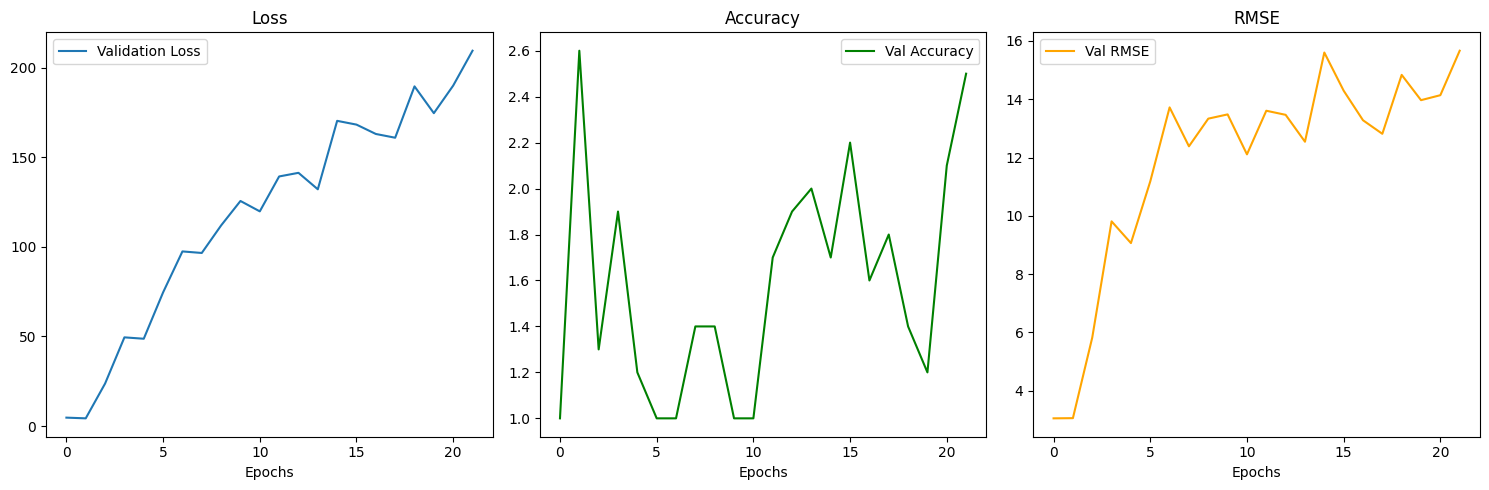

In [20]:
plt.figure(figsize=(15, 5))
# Loss
plt.subplot(1, 3, 1)
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(val_acc_history, color='green', label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

# RMSE
plt.subplot(1, 3, 3)
plt.plot(val_rmse_history, color='orange', label='Val RMSE')
plt.title('RMSE')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.savefig('results_class.png')
plt.show()

## Regression-only model

In [30]:
def train_epoch_regression_only(
    model: DragonModel,
    device: torch.device,
    train_loader: torch.utils.data.DataLoader,
    val_loader:  torch.utils.data.DataLoader,
    optimizer: torch.optim.Adam,
    epochs: int,
    lambda_cnt: float,
    visualizer: TrainingVisualizer,
    epoch: int,
    log_interval: int,#how often we will print progress
    nll_loss,
    smoothl1_loss,
    verbose: bool = True
) -> None:
  model.train()
  progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
  for batch_idx, (images, (class_labels, count_labels)) in enumerate(progress_bar):
      # sending data to GPU
    images, class_labels, count_labels=images.to(device), class_labels.to(device), count_labels.to(device)

    optimizer.zero_grad()

    #Forward pass
    log_prob, pred_counts = model(images) # getting predictions from the model

    # calculating how wrong the model was
    loss_counts = smoothl1_loss(pred_counts, count_labels)
    total_loss = lambda_cnt * loss_counts

    #Backward pass
    total_loss.backward()

    # Visualization
    visualizer.plot_gradients_and_loss(batch_idx, total_loss.item())

    optimizer.step()

    progress_bar.set_postfix({'total loss': f'{total_loss.item():.6f}'})

    if batch_idx % log_interval == 0:
      if verbose:
        done, total = batch_idx * len(images), len(train_loader.dataset)
        progress_bar.write(
          f"Train Epoch: {epoch} [{done}/{total} images ({done / total:.0%})]\t"
            + f"Loss: {total_loss.item():.6f}"
             )

In [32]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

log_interval=10
epochs = 100

nll_loss = nn.NLLLoss()
smoothl1_loss = nn.SmoothL1Loss()
lambda_cnt = 1.0
lr = 1e-3 # don't change

model= DragonModel(p1=0.5, p2=0.5)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

visualizer = TrainingVisualizer(log_interval=log_interval)
visualizer.track_model(model, optimizer, lr)

patience = 20 # how many epochs we will wait until the better model with better accuracy will be founded
epochs_no_improve = 0
best_accuracy = 0.0
final_loss_class  = 0.0
final_loss_count = 0.0
best_rmse = float('inf')
start_time = time.time()

val_loss_history = []
val_acc_history = []
val_rmse_history = []

for epoch in range(1, epochs + 1):
    train_epoch_regression_only(
        model,
        device,
        train_loader,
        val_loader,
        optimizer,
        epochs,
        lambda_cnt,
        visualizer,
        epoch,
        log_interval,
        nll_loss,
        smoothl1_loss,
        verbose = True
    )

    rmse, loss_class, loss_count, test_loss , accuracy = test(
        model,
        device,
        val_loader,
        lambda_cnt,
        nll_loss,
        smoothl1_loss,
        visualizer,
        epoch,
        verbose = True
    )

    val_loss_history.append(test_loss)
    val_acc_history.append(accuracy)
    val_rmse_history.append(rmse)

    if rmse < best_rmse:
      best_accuracy = accuracy
      epochs_no_improve = 0
      torch.save(model.state_dict(), 'best_model_regr.pth') # saving the best model
      final_loss_class = loss_class
      final_loss_count = loss_count
      best_rmse=rmse
    else:
      epochs_no_improve += 1

    if epochs_no_improve >= patience: break
end_time = time.time()
total_time = end_time - start_time

FigureWidget({
    'data': [{'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '35f681bd-9f19-4a0f-96f6-f1bc63dcc107',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '65519df0-e401-43cf-b4f9-a5de225fe9a6',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '1f357465-bf57-4070-98bc-83bb5cc32d7b',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '76eec475-fea4-4b63-99ff-03e4cd3635de',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '6513a666-3ee3-4911-a1ee-ddf5899964e6',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
     

FigureWidget({
    'data': [{'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '22ee3cce-f3dd-4f50-9f14-14a4af2ecf78',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'ba1d0e9e-119a-4c08-9966-2fa27d80f855',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '71444b9b-c465-4909-b4a8-5569e8de2021',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': '2f39c5f7-2a08-4570-93eb-a6b55a946da4',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'b478c140-9ecf-446b-b81a-5c7e8653056c',
              'y': []},
             {'mode': 'lines',
              'showlegend': True,
     

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '7cef892e-df43-42a5-acd0-580b5e067ea5',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '0b7b0f10-3c02-458b-8228-d09a0dcef430',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '0ae67342-3f12-44f1-97e4-564464f28a14',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '015f6706-e505-4933-b294-6dfdabc1d9fd',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'e

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '7c90a12e-389d-445f-83b4-ae636cab2df5',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '1d1eafae-c0d1-464b-a0bc-eeca970f80cb',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '3031b00a-20a4-4e16-a976-cf0bc0df650e',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'e9778d0a-3e75-4548-b5dc-9acb378267d7',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '9

FigureWidget({
    'data': [{'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '984bdd77-7f00-4b23-bd00-2f8751e7ad9f',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f8a588a2-40bb-4a6a-bd67-858e4223c4a6',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'b2e078e2-bc2b-48d9-9284-cc8595ae1fe4',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '64ed789b-f31c-46d4-a105-4908135505d0',
              'x': [],
              'y': []},
             {'mode': 'lines+markers',
              'showlegend': True,
              'type': 'scatter',
              'uid': '1

Epoch 2/100:   4%|▎         | 5/141 [00:00<00:07, 17.99it/s, total loss=1.467642]

Train Epoch: 1 [0/9000 images (0%)]	Loss: 1.491446


Epoch 2/100:   9%|▉         | 13/141 [00:00<00:05, 22.43it/s, total loss=1.429576]

Train Epoch: 1 [640/9000 images (7%)]	Loss: 1.424276


Epoch 2/100:  18%|█▊        | 25/141 [00:01<00:04, 24.08it/s, total loss=1.425711]

Train Epoch: 1 [1280/9000 images (14%)]	Loss: 1.428120


Epoch 2/100:  23%|██▎       | 33/141 [00:01<00:04, 24.47it/s, total loss=1.422280]

Train Epoch: 1 [1920/9000 images (21%)]	Loss: 1.433482


Epoch 2/100:  32%|███▏      | 45/141 [00:01<00:03, 24.80it/s, total loss=1.420364]

Train Epoch: 1 [2560/9000 images (28%)]	Loss: 1.418477


Epoch 2/100:  38%|███▊      | 53/141 [00:02<00:03, 24.59it/s, total loss=1.411433]

Train Epoch: 1 [3200/9000 images (36%)]	Loss: 1.419767


Epoch 2/100:  47%|████▋     | 66/141 [00:02<00:03, 25.00it/s, total loss=1.418334]

Train Epoch: 1 [3840/9000 images (43%)]	Loss: 1.411613


Epoch 2/100:  53%|█████▎    | 75/141 [00:03<00:02, 24.06it/s, total loss=1.400352]

Train Epoch: 1 [4480/9000 images (50%)]	Loss: 1.405845


Epoch 2/100:  60%|█████▉    | 84/141 [00:03<00:02, 24.87it/s, total loss=1.365741]

Train Epoch: 1 [5120/9000 images (57%)]	Loss: 1.380957


Epoch 2/100:  68%|██████▊   | 96/141 [00:04<00:01, 24.55it/s, total loss=1.370714]

Train Epoch: 1 [5760/9000 images (64%)]	Loss: 1.371064


Epoch 2/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.60it/s, total loss=1.295874]

Train Epoch: 1 [6400/9000 images (71%)]	Loss: 1.295045


Epoch 2/100:  81%|████████  | 114/141 [00:04<00:01, 24.02it/s, total loss=1.308720]

Train Epoch: 1 [7040/9000 images (78%)]	Loss: 1.340562


Epoch 2/100:  87%|████████▋ | 123/141 [00:05<00:00, 24.94it/s, total loss=1.197948]

Train Epoch: 1 [7680/9000 images (85%)]	Loss: 1.264484


Epoch 2/100:  96%|█████████▌| 135/141 [00:05<00:00, 25.04it/s, total loss=1.246506]

Train Epoch: 1 [8320/9000 images (92%)]	Loss: 1.294148


Epoch 2/100: 100%|██████████| 141/141 [00:05<00:00, 24.08it/s, total loss=1.300351]

Train Epoch: 1 [5600/9000 images (62%)]	Loss: 1.300351



Test loss: 8.1764, Accuracy: 10/1000 (1%)

Class Loss: 5.4764, Count Loss: 2.7000



Epoch 3/100:   4%|▎         | 5/141 [00:00<00:07, 17.53it/s, total loss=1.236735]

Train Epoch: 2 [0/9000 images (0%)]	Loss: 1.253573


Epoch 3/100:   9%|▉         | 13/141 [00:00<00:05, 21.76it/s, total loss=1.261384]

Train Epoch: 2 [640/9000 images (7%)]	Loss: 1.310747


Epoch 3/100:  18%|█▊        | 25/141 [00:01<00:04, 23.33it/s, total loss=1.213521]

Train Epoch: 2 [1280/9000 images (14%)]	Loss: 1.210145


Epoch 3/100:  23%|██▎       | 33/141 [00:01<00:04, 23.81it/s, total loss=1.222529]

Train Epoch: 2 [1920/9000 images (21%)]	Loss: 1.249894


Epoch 3/100:  32%|███▏      | 45/141 [00:01<00:03, 24.37it/s, total loss=1.193572]

Train Epoch: 2 [2560/9000 images (28%)]	Loss: 1.227552


Epoch 3/100:  38%|███▊      | 53/141 [00:02<00:03, 24.19it/s, total loss=1.242491]

Train Epoch: 2 [3200/9000 images (36%)]	Loss: 1.245190


Epoch 3/100:  46%|████▌     | 65/141 [00:02<00:03, 24.04it/s, total loss=1.214523]

Train Epoch: 2 [3840/9000 images (43%)]	Loss: 1.160928


Epoch 3/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.11it/s, total loss=1.151556]

Train Epoch: 2 [4480/9000 images (50%)]	Loss: 1.087342


Epoch 3/100:  60%|██████    | 85/141 [00:03<00:02, 24.08it/s, total loss=1.136834]

Train Epoch: 2 [5120/9000 images (57%)]	Loss: 1.094690


Epoch 3/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.83it/s, total loss=1.057162]

Train Epoch: 2 [5760/9000 images (64%)]	Loss: 1.142679


Epoch 3/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.97it/s, total loss=1.093678]

Train Epoch: 2 [6400/9000 images (71%)]	Loss: 1.174368


Epoch 3/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.29it/s, total loss=1.103045]

Train Epoch: 2 [7040/9000 images (78%)]	Loss: 1.029744


Epoch 3/100:  87%|████████▋ | 123/141 [00:05<00:00, 23.43it/s, total loss=1.080495]

Train Epoch: 2 [7680/9000 images (85%)]	Loss: 1.018426


Epoch 3/100:  96%|█████████▌| 135/141 [00:05<00:00, 23.82it/s, total loss=1.118285]

Train Epoch: 2 [8320/9000 images (92%)]	Loss: 0.992822


Epoch 3/100: 100%|██████████| 141/141 [00:05<00:00, 23.53it/s, total loss=1.068271]

Train Epoch: 2 [5600/9000 images (62%)]	Loss: 1.068271



Test loss: 9.4879, Accuracy: 10/1000 (1%)

Class Loss: 6.1391, Count Loss: 3.3488



Epoch 4/100:   1%|          | 1/141 [00:00<00:21,  6.44it/s, total loss=1.072444]

Train Epoch: 3 [0/9000 images (0%)]	Loss: 1.062746


Epoch 4/100:   9%|▉         | 13/141 [00:00<00:05, 22.28it/s, total loss=1.162497]

Train Epoch: 3 [640/9000 images (7%)]	Loss: 1.080459


Epoch 4/100:  18%|█▊        | 25/141 [00:01<00:04, 24.17it/s, total loss=1.037594]

Train Epoch: 3 [1280/9000 images (14%)]	Loss: 1.104147


Epoch 4/100:  23%|██▎       | 33/141 [00:01<00:04, 24.49it/s, total loss=1.009271]

Train Epoch: 3 [1920/9000 images (21%)]	Loss: 1.013586


Epoch 4/100:  32%|███▏      | 45/141 [00:01<00:03, 24.19it/s, total loss=0.930601]

Train Epoch: 3 [2560/9000 images (28%)]	Loss: 1.005680


Epoch 4/100:  38%|███▊      | 53/141 [00:02<00:03, 24.19it/s, total loss=0.952036]

Train Epoch: 3 [3200/9000 images (36%)]	Loss: 1.009229


Epoch 4/100:  46%|████▌     | 65/141 [00:02<00:03, 24.41it/s, total loss=0.914915]

Train Epoch: 3 [3840/9000 images (43%)]	Loss: 0.946228


Epoch 4/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.44it/s, total loss=0.913239]

Train Epoch: 3 [4480/9000 images (50%)]	Loss: 1.013745


Epoch 4/100:  60%|██████    | 85/141 [00:03<00:02, 24.33it/s, total loss=0.912880]

Train Epoch: 3 [5120/9000 images (57%)]	Loss: 0.841744


Epoch 4/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.05it/s, total loss=0.992249]

Train Epoch: 3 [5760/9000 images (64%)]	Loss: 0.877156


Epoch 4/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.17it/s, total loss=0.806442]

Train Epoch: 3 [6400/9000 images (71%)]	Loss: 0.895856


Epoch 4/100:  80%|████████  | 113/141 [00:04<00:01, 24.07it/s, total loss=0.750491]

Train Epoch: 3 [7040/9000 images (78%)]	Loss: 0.915427


Epoch 4/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.03it/s, total loss=0.774658]

Train Epoch: 3 [7680/9000 images (85%)]	Loss: 0.850724


Epoch 4/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.02it/s, total loss=0.776983]

Train Epoch: 3 [8320/9000 images (92%)]	Loss: 0.784391


Epoch 4/100: 100%|██████████| 141/141 [00:05<00:00, 23.86it/s, total loss=0.802096]

Train Epoch: 3 [5600/9000 images (62%)]	Loss: 0.802096



Test loss: 18.2763, Accuracy: 12/1000 (1%)

Class Loss: 10.0966, Count Loss: 8.1797



Epoch 5/100:   1%|          | 1/141 [00:00<00:20,  6.68it/s, total loss=0.737016]

Train Epoch: 4 [0/9000 images (0%)]	Loss: 0.706805


Epoch 5/100:   9%|▉         | 13/141 [00:00<00:05, 22.48it/s, total loss=0.826908]

Train Epoch: 4 [640/9000 images (7%)]	Loss: 0.719039


Epoch 5/100:  18%|█▊        | 25/141 [00:01<00:04, 24.32it/s, total loss=0.815414]

Train Epoch: 4 [1280/9000 images (14%)]	Loss: 0.777589


Epoch 5/100:  23%|██▎       | 33/141 [00:01<00:04, 24.63it/s, total loss=0.887366]

Train Epoch: 4 [1920/9000 images (21%)]	Loss: 0.595071


Epoch 5/100:  32%|███▏      | 45/141 [00:01<00:03, 24.76it/s, total loss=0.801289]

Train Epoch: 4 [2560/9000 images (28%)]	Loss: 0.785326


Epoch 5/100:  38%|███▊      | 53/141 [00:02<00:03, 24.59it/s, total loss=0.711419]

Train Epoch: 4 [3200/9000 images (36%)]	Loss: 0.733411


Epoch 5/100:  46%|████▌     | 65/141 [00:02<00:03, 24.62it/s, total loss=0.629538]

Train Epoch: 4 [3840/9000 images (43%)]	Loss: 0.752669


Epoch 5/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.48it/s, total loss=0.714853]

Train Epoch: 4 [4480/9000 images (50%)]	Loss: 0.655507


Epoch 5/100:  60%|██████    | 85/141 [00:03<00:02, 24.60it/s, total loss=0.710665]

Train Epoch: 4 [5120/9000 images (57%)]	Loss: 0.670631


Epoch 5/100:  66%|██████▌   | 93/141 [00:03<00:01, 24.65it/s, total loss=0.633307]

Train Epoch: 4 [5760/9000 images (64%)]	Loss: 0.602877


Epoch 5/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.58it/s, total loss=0.615563]

Train Epoch: 4 [6400/9000 images (71%)]	Loss: 0.684673


Epoch 5/100:  80%|████████  | 113/141 [00:04<00:01, 24.26it/s, total loss=0.641960]

Train Epoch: 4 [7040/9000 images (78%)]	Loss: 0.777390


Epoch 5/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.12it/s, total loss=0.604162]

Train Epoch: 4 [7680/9000 images (85%)]	Loss: 0.611129


Epoch 5/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.03it/s, total loss=0.626391]

Train Epoch: 4 [8320/9000 images (92%)]	Loss: 0.625600


Epoch 5/100: 100%|██████████| 141/141 [00:05<00:00, 24.10it/s, total loss=0.596670]

Train Epoch: 4 [5600/9000 images (62%)]	Loss: 0.596670



Test loss: 17.9053, Accuracy: 12/1000 (1%)

Class Loss: 10.0453, Count Loss: 7.8600



Epoch 6/100:   1%|          | 1/141 [00:00<00:20,  6.73it/s, total loss=0.630970]

Train Epoch: 5 [0/9000 images (0%)]	Loss: 0.541161


Epoch 6/100:   9%|▉         | 13/141 [00:00<00:05, 22.37it/s, total loss=0.527470]

Train Epoch: 5 [640/9000 images (7%)]	Loss: 0.536904


Epoch 6/100:  18%|█▊        | 26/141 [00:01<00:04, 24.84it/s, total loss=0.582040]

Train Epoch: 5 [1280/9000 images (14%)]	Loss: 0.592528


Epoch 6/100:  25%|██▍       | 35/141 [00:01<00:04, 23.61it/s, total loss=0.609513]

Train Epoch: 5 [1920/9000 images (21%)]	Loss: 0.567312


Epoch 6/100:  31%|███       | 44/141 [00:01<00:04, 23.65it/s, total loss=0.554483]

Train Epoch: 5 [2560/9000 images (28%)]	Loss: 0.545269


Epoch 6/100:  38%|███▊      | 54/141 [00:02<00:03, 23.38it/s, total loss=0.521601]

Train Epoch: 5 [3200/9000 images (36%)]	Loss: 0.572532


Epoch 6/100:  44%|████▍     | 62/141 [00:02<00:03, 23.49it/s, total loss=0.482780]

Train Epoch: 5 [3840/9000 images (43%)]	Loss: 0.466574


Epoch 6/100:  52%|█████▏    | 74/141 [00:03<00:02, 23.54it/s, total loss=0.494374]

Train Epoch: 5 [4480/9000 images (50%)]	Loss: 0.574058


Epoch 6/100:  58%|█████▊    | 82/141 [00:03<00:02, 23.55it/s, total loss=0.609696]

Train Epoch: 5 [5120/9000 images (57%)]	Loss: 0.645035


Epoch 6/100:  67%|██████▋   | 94/141 [00:04<00:01, 23.71it/s, total loss=0.548647]

Train Epoch: 5 [5760/9000 images (64%)]	Loss: 0.551115


Epoch 6/100:  72%|███████▏  | 102/141 [00:04<00:01, 23.96it/s, total loss=0.533313]

Train Epoch: 5 [6400/9000 images (71%)]	Loss: 0.607847


Epoch 6/100:  81%|████████  | 114/141 [00:04<00:01, 24.27it/s, total loss=0.527229]

Train Epoch: 5 [7040/9000 images (78%)]	Loss: 0.538058


Epoch 6/100:  87%|████████▋ | 122/141 [00:05<00:00, 24.31it/s, total loss=0.666031]

Train Epoch: 5 [7680/9000 images (85%)]	Loss: 0.551654


Epoch 6/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.36it/s, total loss=0.550511]

Train Epoch: 5 [8320/9000 images (92%)]	Loss: 0.515023


Epoch 6/100: 100%|██████████| 141/141 [00:05<00:00, 23.68it/s, total loss=0.589287]

Train Epoch: 5 [5600/9000 images (62%)]	Loss: 0.589287



Test loss: 15.8976, Accuracy: 12/1000 (1%)

Class Loss: 9.7668, Count Loss: 6.1308



Epoch 7/100:   1%|          | 1/141 [00:00<00:21,  6.46it/s, total loss=0.562848]

Train Epoch: 6 [0/9000 images (0%)]	Loss: 0.562366


Epoch 7/100:   9%|▉         | 13/141 [00:00<00:05, 21.86it/s, total loss=0.550551]

Train Epoch: 6 [640/9000 images (7%)]	Loss: 0.466043


Epoch 7/100:  18%|█▊        | 25/141 [00:01<00:04, 23.49it/s, total loss=0.530938]

Train Epoch: 6 [1280/9000 images (14%)]	Loss: 0.544620


Epoch 7/100:  23%|██▎       | 33/141 [00:01<00:04, 24.09it/s, total loss=0.558667]

Train Epoch: 6 [1920/9000 images (21%)]	Loss: 0.500478


Epoch 7/100:  32%|███▏      | 45/141 [00:01<00:03, 24.42it/s, total loss=0.515158]

Train Epoch: 6 [2560/9000 images (28%)]	Loss: 0.558698


Epoch 7/100:  38%|███▊      | 53/141 [00:02<00:03, 24.58it/s, total loss=0.519596]

Train Epoch: 6 [3200/9000 images (36%)]	Loss: 0.549548


Epoch 7/100:  46%|████▌     | 65/141 [00:02<00:03, 25.04it/s, total loss=0.590678]

Train Epoch: 6 [3840/9000 images (43%)]	Loss: 0.536880


Epoch 7/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.68it/s, total loss=0.603671]

Train Epoch: 6 [4480/9000 images (50%)]	Loss: 0.505774


Epoch 7/100:  60%|██████    | 85/141 [00:03<00:02, 24.66it/s, total loss=0.522486]

Train Epoch: 6 [5120/9000 images (57%)]	Loss: 0.552183


Epoch 7/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.47it/s, total loss=0.526702]

Train Epoch: 6 [5760/9000 images (64%)]	Loss: 0.549047


Epoch 7/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.70it/s, total loss=0.518685]

Train Epoch: 6 [6400/9000 images (71%)]	Loss: 0.506838


Epoch 7/100:  82%|████████▏ | 116/141 [00:04<00:00, 25.57it/s, total loss=0.577770]

Train Epoch: 6 [7040/9000 images (78%)]	Loss: 0.479297


Epoch 7/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.04it/s, total loss=0.521939]

Train Epoch: 6 [7680/9000 images (85%)]	Loss: 0.541405


Epoch 7/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.66it/s, total loss=0.550552]

Train Epoch: 6 [8320/9000 images (92%)]	Loss: 0.507854


Epoch 7/100: 100%|██████████| 141/141 [00:05<00:00, 24.00it/s, total loss=0.549496]

Train Epoch: 6 [5600/9000 images (62%)]	Loss: 0.549496



Test loss: 17.7514, Accuracy: 12/1000 (1%)

Class Loss: 10.7277, Count Loss: 7.0237



Epoch 8/100:   1%|          | 1/141 [00:00<00:21,  6.51it/s, total loss=0.563741]

Train Epoch: 7 [0/9000 images (0%)]	Loss: 0.444709


Epoch 8/100:   9%|▉         | 13/141 [00:00<00:05, 21.90it/s, total loss=0.483717]

Train Epoch: 7 [640/9000 images (7%)]	Loss: 0.528685


Epoch 8/100:  18%|█▊        | 25/141 [00:01<00:04, 23.83it/s, total loss=0.540595]

Train Epoch: 7 [1280/9000 images (14%)]	Loss: 0.501090


Epoch 8/100:  23%|██▎       | 33/141 [00:01<00:04, 24.41it/s, total loss=0.476490]

Train Epoch: 7 [1920/9000 images (21%)]	Loss: 0.491620


Epoch 8/100:  32%|███▏      | 45/141 [00:01<00:03, 24.64it/s, total loss=0.498054]

Train Epoch: 7 [2560/9000 images (28%)]	Loss: 0.513366


Epoch 8/100:  38%|███▊      | 53/141 [00:02<00:03, 24.42it/s, total loss=0.591924]

Train Epoch: 7 [3200/9000 images (36%)]	Loss: 0.537291


Epoch 8/100:  46%|████▌     | 65/141 [00:02<00:03, 24.53it/s, total loss=0.477379]

Train Epoch: 7 [3840/9000 images (43%)]	Loss: 0.546151


Epoch 8/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.33it/s, total loss=0.523201]

Train Epoch: 7 [4480/9000 images (50%)]	Loss: 0.498183


Epoch 8/100:  60%|██████    | 85/141 [00:03<00:02, 24.55it/s, total loss=0.540877]

Train Epoch: 7 [5120/9000 images (57%)]	Loss: 0.460299


Epoch 8/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.25it/s, total loss=0.518787]

Train Epoch: 7 [5760/9000 images (64%)]	Loss: 0.561806


Epoch 8/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.05it/s, total loss=0.493874]

Train Epoch: 7 [6400/9000 images (71%)]	Loss: 0.542204


Epoch 8/100:  80%|████████  | 113/141 [00:04<00:01, 24.02it/s, total loss=0.506477]

Train Epoch: 7 [7040/9000 images (78%)]	Loss: 0.512182


Epoch 8/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.26it/s, total loss=0.510365]

Train Epoch: 7 [7680/9000 images (85%)]	Loss: 0.517927


Epoch 8/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.16it/s, total loss=0.539883]

Train Epoch: 7 [8320/9000 images (92%)]	Loss: 0.483789


Epoch 8/100: 100%|██████████| 141/141 [00:05<00:00, 23.85it/s, total loss=0.501354]

Train Epoch: 7 [5600/9000 images (62%)]	Loss: 0.501354



Test loss: 19.1301, Accuracy: 12/1000 (1%)

Class Loss: 11.4970, Count Loss: 7.6330



Epoch 9/100:   1%|          | 1/141 [00:00<00:21,  6.50it/s, total loss=0.411270]

Train Epoch: 8 [0/9000 images (0%)]	Loss: 0.436527


Epoch 9/100:   9%|▉         | 13/141 [00:00<00:05, 22.15it/s, total loss=0.555637]

Train Epoch: 8 [640/9000 images (7%)]	Loss: 0.462928


Epoch 9/100:  18%|█▊        | 25/141 [00:01<00:04, 23.46it/s, total loss=0.454924]

Train Epoch: 8 [1280/9000 images (14%)]	Loss: 0.554379


Epoch 9/100:  23%|██▎       | 33/141 [00:01<00:04, 23.49it/s, total loss=0.440679]

Train Epoch: 8 [1920/9000 images (21%)]	Loss: 0.545927


Epoch 9/100:  32%|███▏      | 45/141 [00:01<00:04, 23.66it/s, total loss=0.513457]

Train Epoch: 8 [2560/9000 images (28%)]	Loss: 0.471813


Epoch 9/100:  38%|███▊      | 53/141 [00:02<00:03, 23.74it/s, total loss=0.417632]

Train Epoch: 8 [3200/9000 images (36%)]	Loss: 0.527543


Epoch 9/100:  46%|████▌     | 65/141 [00:02<00:03, 23.98it/s, total loss=0.501786]

Train Epoch: 8 [3840/9000 images (43%)]	Loss: 0.402762


Epoch 9/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.80it/s, total loss=0.496953]

Train Epoch: 8 [4480/9000 images (50%)]	Loss: 0.482502


Epoch 9/100:  60%|██████    | 85/141 [00:03<00:02, 23.81it/s, total loss=0.453360]

Train Epoch: 8 [5120/9000 images (57%)]	Loss: 0.505017


Epoch 9/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.74it/s, total loss=0.527032]

Train Epoch: 8 [5760/9000 images (64%)]	Loss: 0.433993


Epoch 9/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.54it/s, total loss=0.510239]

Train Epoch: 8 [6400/9000 images (71%)]	Loss: 0.463652


Epoch 9/100:  80%|████████  | 113/141 [00:04<00:01, 23.89it/s, total loss=0.554371]

Train Epoch: 8 [7040/9000 images (78%)]	Loss: 0.467853


Epoch 9/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.11it/s, total loss=0.505116]

Train Epoch: 8 [7680/9000 images (85%)]	Loss: 0.502959


Epoch 9/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.11it/s, total loss=0.508900]

Train Epoch: 8 [8320/9000 images (92%)]	Loss: 0.476269


Epoch 9/100: 100%|██████████| 141/141 [00:05<00:00, 23.50it/s, total loss=0.508716]

Train Epoch: 8 [5600/9000 images (62%)]	Loss: 0.508716



Test loss: 17.3059, Accuracy: 12/1000 (1%)

Class Loss: 10.1870, Count Loss: 7.1189



Epoch 10/100:   1%|          | 1/141 [00:00<00:21,  6.39it/s, total loss=0.466690]

Train Epoch: 9 [0/9000 images (0%)]	Loss: 0.476029


Epoch 10/100:   9%|▉         | 13/141 [00:00<00:05, 22.42it/s, total loss=0.448372]

Train Epoch: 9 [640/9000 images (7%)]	Loss: 0.470135


Epoch 10/100:  18%|█▊        | 25/141 [00:01<00:04, 23.99it/s, total loss=0.489760]

Train Epoch: 9 [1280/9000 images (14%)]	Loss: 0.451800


Epoch 10/100:  23%|██▎       | 33/141 [00:01<00:04, 24.10it/s, total loss=0.525830]

Train Epoch: 9 [1920/9000 images (21%)]	Loss: 0.518084


Epoch 10/100:  32%|███▏      | 45/141 [00:01<00:03, 24.19it/s, total loss=0.464997]

Train Epoch: 9 [2560/9000 images (28%)]	Loss: 0.456751


Epoch 10/100:  38%|███▊      | 53/141 [00:02<00:03, 24.22it/s, total loss=0.440642]

Train Epoch: 9 [3200/9000 images (36%)]	Loss: 0.436548


Epoch 10/100:  46%|████▌     | 65/141 [00:02<00:03, 24.01it/s, total loss=0.506740]

Train Epoch: 9 [3840/9000 images (43%)]	Loss: 0.398186


Epoch 10/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.87it/s, total loss=0.485957]

Train Epoch: 9 [4480/9000 images (50%)]	Loss: 0.429678


Epoch 10/100:  60%|██████    | 85/141 [00:03<00:02, 24.39it/s, total loss=0.429146]

Train Epoch: 9 [5120/9000 images (57%)]	Loss: 0.430346


Epoch 10/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.26it/s, total loss=0.517275]

Train Epoch: 9 [5760/9000 images (64%)]	Loss: 0.477057


Epoch 10/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.59it/s, total loss=0.527172]

Train Epoch: 9 [6400/9000 images (71%)]	Loss: 0.460448


Epoch 10/100:  80%|████████  | 113/141 [00:04<00:01, 24.69it/s, total loss=0.443740]

Train Epoch: 9 [7040/9000 images (78%)]	Loss: 0.486641


Epoch 10/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.69it/s, total loss=0.455514]

Train Epoch: 9 [7680/9000 images (85%)]	Loss: 0.405825


Epoch 10/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.50it/s, total loss=0.472184]

Train Epoch: 9 [8320/9000 images (92%)]	Loss: 0.409583


Epoch 10/100: 100%|██████████| 141/141 [00:05<00:00, 23.94it/s, total loss=0.441088]

Train Epoch: 9 [5600/9000 images (62%)]	Loss: 0.441088



Test loss: 17.6824, Accuracy: 12/1000 (1%)

Class Loss: 10.3796, Count Loss: 7.3028



Epoch 11/100:   1%|          | 1/141 [00:00<00:21,  6.54it/s, total loss=0.456356]

Train Epoch: 10 [0/9000 images (0%)]	Loss: 0.517316


Epoch 11/100:   9%|▉         | 13/141 [00:00<00:05, 22.71it/s, total loss=0.435799]

Train Epoch: 10 [640/9000 images (7%)]	Loss: 0.384062


Epoch 11/100:  18%|█▊        | 25/141 [00:01<00:04, 24.24it/s, total loss=0.449708]

Train Epoch: 10 [1280/9000 images (14%)]	Loss: 0.450287


Epoch 11/100:  24%|██▍       | 34/141 [00:01<00:04, 24.95it/s, total loss=0.520069]

Train Epoch: 10 [1920/9000 images (21%)]	Loss: 0.505275


Epoch 11/100:  33%|███▎      | 46/141 [00:01<00:03, 24.32it/s, total loss=0.451621]

Train Epoch: 10 [2560/9000 images (28%)]	Loss: 0.424643


Epoch 11/100:  39%|███▉      | 55/141 [00:02<00:03, 24.53it/s, total loss=0.419612]

Train Epoch: 10 [3200/9000 images (36%)]	Loss: 0.418237


Epoch 11/100:  45%|████▌     | 64/141 [00:02<00:03, 24.37it/s, total loss=0.462261]

Train Epoch: 10 [3840/9000 images (43%)]	Loss: 0.478875


Epoch 11/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.80it/s, total loss=0.478536]

Train Epoch: 10 [4480/9000 images (50%)]	Loss: 0.468541


Epoch 11/100:  58%|█████▊    | 82/141 [00:03<00:02, 23.26it/s, total loss=0.576077]

Train Epoch: 10 [5120/9000 images (57%)]	Loss: 0.477861


Epoch 11/100:  67%|██████▋   | 94/141 [00:03<00:01, 23.53it/s, total loss=0.496293]

Train Epoch: 10 [5760/9000 images (64%)]	Loss: 0.459234


Epoch 11/100:  72%|███████▏  | 102/141 [00:04<00:01, 23.56it/s, total loss=0.511909]

Train Epoch: 10 [6400/9000 images (71%)]	Loss: 0.443047


Epoch 11/100:  81%|████████  | 114/141 [00:04<00:01, 23.71it/s, total loss=0.417700]

Train Epoch: 10 [7040/9000 images (78%)]	Loss: 0.435329


Epoch 11/100:  87%|████████▋ | 122/141 [00:05<00:00, 24.10it/s, total loss=0.467214]

Train Epoch: 10 [7680/9000 images (85%)]	Loss: 0.525276


Epoch 11/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.18it/s, total loss=0.498188]

Train Epoch: 10 [8320/9000 images (92%)]	Loss: 0.476550


Epoch 11/100: 100%|██████████| 141/141 [00:05<00:00, 23.88it/s, total loss=0.473050]

Train Epoch: 10 [5600/9000 images (62%)]	Loss: 0.473050



Test loss: 16.4634, Accuracy: 12/1000 (1%)

Class Loss: 9.4902, Count Loss: 6.9732



Epoch 12/100:   1%|          | 1/141 [00:00<00:21,  6.56it/s, total loss=0.439118]

Train Epoch: 11 [0/9000 images (0%)]	Loss: 0.512422


Epoch 12/100:   9%|▉         | 13/141 [00:00<00:05, 21.97it/s, total loss=0.465130]

Train Epoch: 11 [640/9000 images (7%)]	Loss: 0.430001


Epoch 12/100:  18%|█▊        | 25/141 [00:01<00:04, 23.84it/s, total loss=0.377615]

Train Epoch: 11 [1280/9000 images (14%)]	Loss: 0.454977


Epoch 12/100:  23%|██▎       | 33/141 [00:01<00:04, 24.21it/s, total loss=0.431590]

Train Epoch: 11 [1920/9000 images (21%)]	Loss: 0.423245


Epoch 12/100:  32%|███▏      | 45/141 [00:01<00:03, 24.56it/s, total loss=0.399832]

Train Epoch: 11 [2560/9000 images (28%)]	Loss: 0.498865


Epoch 12/100:  38%|███▊      | 53/141 [00:02<00:03, 24.55it/s, total loss=0.389525]

Train Epoch: 11 [3200/9000 images (36%)]	Loss: 0.421768


Epoch 12/100:  46%|████▌     | 65/141 [00:02<00:03, 24.31it/s, total loss=0.493185]

Train Epoch: 11 [3840/9000 images (43%)]	Loss: 0.447587


Epoch 12/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.30it/s, total loss=0.519778]

Train Epoch: 11 [4480/9000 images (50%)]	Loss: 0.428742


Epoch 12/100:  60%|██████    | 85/141 [00:03<00:02, 24.53it/s, total loss=0.423156]

Train Epoch: 11 [5120/9000 images (57%)]	Loss: 0.467759


Epoch 12/100:  66%|██████▌   | 93/141 [00:03<00:01, 24.69it/s, total loss=0.453955]

Train Epoch: 11 [5760/9000 images (64%)]	Loss: 0.452425


Epoch 12/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.81it/s, total loss=0.440175]

Train Epoch: 11 [6400/9000 images (71%)]	Loss: 0.476485


Epoch 12/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.07it/s, total loss=0.523053]

Train Epoch: 11 [7040/9000 images (78%)]	Loss: 0.384103


Epoch 12/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.09it/s, total loss=0.481380]

Train Epoch: 11 [7680/9000 images (85%)]	Loss: 0.474432


Epoch 12/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.32it/s, total loss=0.442290]

Train Epoch: 11 [8320/9000 images (92%)]	Loss: 0.396946


Epoch 12/100: 100%|██████████| 141/141 [00:05<00:00, 23.98it/s, total loss=0.446585]

Train Epoch: 11 [5600/9000 images (62%)]	Loss: 0.446585



Test loss: 15.3159, Accuracy: 12/1000 (1%)

Class Loss: 8.8977, Count Loss: 6.4182



Epoch 13/100:   1%|          | 1/141 [00:00<00:22,  6.09it/s, total loss=0.415043]

Train Epoch: 12 [0/9000 images (0%)]	Loss: 0.362032


Epoch 13/100:   9%|▉         | 13/141 [00:00<00:05, 21.70it/s, total loss=0.385503]

Train Epoch: 12 [640/9000 images (7%)]	Loss: 0.425014


Epoch 13/100:  18%|█▊        | 25/141 [00:01<00:04, 23.48it/s, total loss=0.502152]

Train Epoch: 12 [1280/9000 images (14%)]	Loss: 0.436434


Epoch 13/100:  25%|██▍       | 35/141 [00:01<00:04, 23.64it/s, total loss=0.463423]

Train Epoch: 12 [1920/9000 images (21%)]	Loss: 0.414851


Epoch 13/100:  30%|███       | 43/141 [00:02<00:04, 23.77it/s, total loss=0.451313]

Train Epoch: 12 [2560/9000 images (28%)]	Loss: 0.377155


Epoch 13/100:  39%|███▉      | 55/141 [00:02<00:03, 24.18it/s, total loss=0.507912]

Train Epoch: 12 [3200/9000 images (36%)]	Loss: 0.399693


Epoch 13/100:  45%|████▍     | 63/141 [00:02<00:03, 24.37it/s, total loss=0.429983]

Train Epoch: 12 [3840/9000 images (43%)]	Loss: 0.424432


Epoch 13/100:  54%|█████▍    | 76/141 [00:03<00:02, 25.20it/s, total loss=0.497400]

Train Epoch: 12 [4480/9000 images (50%)]	Loss: 0.478315


Epoch 13/100:  60%|██████    | 85/141 [00:03<00:02, 24.13it/s, total loss=0.368907]

Train Epoch: 12 [5120/9000 images (57%)]	Loss: 0.467270


Epoch 13/100:  67%|██████▋   | 94/141 [00:04<00:01, 24.49it/s, total loss=0.466844]

Train Epoch: 12 [5760/9000 images (64%)]	Loss: 0.467572


Epoch 13/100:  73%|███████▎  | 103/141 [00:04<00:01, 24.28it/s, total loss=0.417049]

Train Epoch: 12 [6400/9000 images (71%)]	Loss: 0.468882


Epoch 13/100:  82%|████████▏ | 115/141 [00:04<00:01, 24.37it/s, total loss=0.485158]

Train Epoch: 12 [7040/9000 images (78%)]	Loss: 0.489824


Epoch 13/100:  88%|████████▊ | 124/141 [00:05<00:00, 24.39it/s, total loss=0.505995]

Train Epoch: 12 [7680/9000 images (85%)]	Loss: 0.389765


Epoch 13/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.13it/s, total loss=0.432724]

Train Epoch: 12 [8320/9000 images (92%)]	Loss: 0.429852


Epoch 13/100: 100%|██████████| 141/141 [00:05<00:00, 23.78it/s, total loss=0.429468]

Train Epoch: 12 [5600/9000 images (62%)]	Loss: 0.429468



Test loss: 13.5281, Accuracy: 12/1000 (1%)

Class Loss: 7.9537, Count Loss: 5.5744



Epoch 14/100:   1%|          | 1/141 [00:00<00:21,  6.51it/s, total loss=0.395387]

Train Epoch: 13 [0/9000 images (0%)]	Loss: 0.399095


Epoch 14/100:   9%|▉         | 13/141 [00:00<00:05, 22.30it/s, total loss=0.415820]

Train Epoch: 13 [640/9000 images (7%)]	Loss: 0.411579


Epoch 14/100:  18%|█▊        | 25/141 [00:01<00:04, 23.60it/s, total loss=0.397795]

Train Epoch: 13 [1280/9000 images (14%)]	Loss: 0.453311


Epoch 14/100:  23%|██▎       | 33/141 [00:01<00:04, 23.77it/s, total loss=0.434401]

Train Epoch: 13 [1920/9000 images (21%)]	Loss: 0.383210


Epoch 14/100:  32%|███▏      | 45/141 [00:01<00:03, 24.12it/s, total loss=0.429321]

Train Epoch: 13 [2560/9000 images (28%)]	Loss: 0.471966


Epoch 14/100:  38%|███▊      | 53/141 [00:02<00:03, 24.20it/s, total loss=0.530542]

Train Epoch: 13 [3200/9000 images (36%)]	Loss: 0.366125


Epoch 14/100:  46%|████▌     | 65/141 [00:02<00:03, 24.51it/s, total loss=0.493763]

Train Epoch: 13 [3840/9000 images (43%)]	Loss: 0.445186


Epoch 14/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.53it/s, total loss=0.497592]

Train Epoch: 13 [4480/9000 images (50%)]	Loss: 0.378955


Epoch 14/100:  60%|██████    | 85/141 [00:03<00:02, 24.05it/s, total loss=0.484120]

Train Epoch: 13 [5120/9000 images (57%)]	Loss: 0.477873


Epoch 14/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.26it/s, total loss=0.400104]

Train Epoch: 13 [5760/9000 images (64%)]	Loss: 0.386544


Epoch 14/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.11it/s, total loss=0.404727]

Train Epoch: 13 [6400/9000 images (71%)]	Loss: 0.477705


Epoch 14/100:  80%|████████  | 113/141 [00:04<00:01, 23.96it/s, total loss=0.431807]

Train Epoch: 13 [7040/9000 images (78%)]	Loss: 0.480347


Epoch 14/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.07it/s, total loss=0.419899]

Train Epoch: 13 [7680/9000 images (85%)]	Loss: 0.450911


Epoch 14/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.20it/s, total loss=0.456239]

Train Epoch: 13 [8320/9000 images (92%)]	Loss: 0.386586


Epoch 14/100: 100%|██████████| 141/141 [00:05<00:00, 23.78it/s, total loss=0.464164]

Train Epoch: 13 [5600/9000 images (62%)]	Loss: 0.464164



Test loss: 14.0579, Accuracy: 12/1000 (1%)

Class Loss: 8.1930, Count Loss: 5.8649



Epoch 15/100:   1%|          | 1/141 [00:00<00:21,  6.64it/s, total loss=0.421586]

Train Epoch: 14 [0/9000 images (0%)]	Loss: 0.446435


Epoch 15/100:   9%|▉         | 13/141 [00:00<00:05, 22.40it/s, total loss=0.400956]

Train Epoch: 14 [640/9000 images (7%)]	Loss: 0.403628


Epoch 15/100:  18%|█▊        | 25/141 [00:01<00:04, 23.82it/s, total loss=0.394420]

Train Epoch: 14 [1280/9000 images (14%)]	Loss: 0.447622


Epoch 15/100:  23%|██▎       | 33/141 [00:01<00:04, 23.79it/s, total loss=0.495933]

Train Epoch: 14 [1920/9000 images (21%)]	Loss: 0.334606


Epoch 15/100:  32%|███▏      | 45/141 [00:01<00:03, 24.01it/s, total loss=0.434109]

Train Epoch: 14 [2560/9000 images (28%)]	Loss: 0.493734


Epoch 15/100:  38%|███▊      | 53/141 [00:02<00:03, 24.11it/s, total loss=0.485680]

Train Epoch: 14 [3200/9000 images (36%)]	Loss: 0.445272


Epoch 15/100:  46%|████▌     | 65/141 [00:02<00:03, 24.49it/s, total loss=0.384954]

Train Epoch: 14 [3840/9000 images (43%)]	Loss: 0.398795


Epoch 15/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.53it/s, total loss=0.400865]

Train Epoch: 14 [4480/9000 images (50%)]	Loss: 0.376742


Epoch 15/100:  60%|██████    | 85/141 [00:03<00:02, 24.85it/s, total loss=0.431210]

Train Epoch: 14 [5120/9000 images (57%)]	Loss: 0.355764


Epoch 15/100:  66%|██████▌   | 93/141 [00:03<00:01, 24.92it/s, total loss=0.380289]

Train Epoch: 14 [5760/9000 images (64%)]	Loss: 0.382239


Epoch 15/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.62it/s, total loss=0.446576]

Train Epoch: 14 [6400/9000 images (71%)]	Loss: 0.382914


Epoch 15/100:  80%|████████  | 113/141 [00:04<00:01, 24.26it/s, total loss=0.380995]

Train Epoch: 14 [7040/9000 images (78%)]	Loss: 0.402414


Epoch 15/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.65it/s, total loss=0.394592]

Train Epoch: 14 [7680/9000 images (85%)]	Loss: 0.411008


Epoch 15/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.75it/s, total loss=0.484204]

Train Epoch: 14 [8320/9000 images (92%)]	Loss: 0.406299


Epoch 15/100: 100%|██████████| 141/141 [00:05<00:00, 24.04it/s, total loss=0.486626]

Train Epoch: 14 [5600/9000 images (62%)]	Loss: 0.486626



Test loss: 12.8181, Accuracy: 12/1000 (1%)

Class Loss: 7.5240, Count Loss: 5.2941



Epoch 16/100:   1%|          | 1/141 [00:00<00:21,  6.43it/s, total loss=0.463907]

Train Epoch: 15 [0/9000 images (0%)]	Loss: 0.495004


Epoch 16/100:   9%|▉         | 13/141 [00:00<00:05, 21.85it/s, total loss=0.390820]

Train Epoch: 15 [640/9000 images (7%)]	Loss: 0.429318


Epoch 16/100:  18%|█▊        | 25/141 [00:01<00:04, 23.44it/s, total loss=0.429689]

Train Epoch: 15 [1280/9000 images (14%)]	Loss: 0.466271


Epoch 16/100:  23%|██▎       | 33/141 [00:01<00:04, 24.02it/s, total loss=0.408696]

Train Epoch: 15 [1920/9000 images (21%)]	Loss: 0.429273


Epoch 16/100:  32%|███▏      | 45/141 [00:01<00:03, 24.51it/s, total loss=0.488693]

Train Epoch: 15 [2560/9000 images (28%)]	Loss: 0.451329


Epoch 16/100:  39%|███▉      | 55/141 [00:02<00:03, 23.85it/s, total loss=0.387557]

Train Epoch: 15 [3200/9000 images (36%)]	Loss: 0.421223


Epoch 16/100:  46%|████▌     | 65/141 [00:02<00:03, 23.99it/s, total loss=0.414339]

Train Epoch: 15 [3840/9000 images (43%)]	Loss: 0.476715


Epoch 16/100:  52%|█████▏    | 74/141 [00:03<00:02, 24.96it/s, total loss=0.384583]

Train Epoch: 15 [4480/9000 images (50%)]	Loss: 0.393330


Epoch 16/100:  61%|██████    | 86/141 [00:03<00:02, 24.30it/s, total loss=0.447563]

Train Epoch: 15 [5120/9000 images (57%)]	Loss: 0.433891


Epoch 16/100:  67%|██████▋   | 95/141 [00:04<00:01, 24.35it/s, total loss=0.437784]

Train Epoch: 15 [5760/9000 images (64%)]	Loss: 0.475055


Epoch 16/100:  74%|███████▍  | 104/141 [00:04<00:01, 23.31it/s, total loss=0.369289]

Train Epoch: 15 [6400/9000 images (71%)]	Loss: 0.416178


Epoch 16/100:  79%|███████▉  | 112/141 [00:04<00:01, 23.68it/s, total loss=0.401813]

Train Epoch: 15 [7040/9000 images (78%)]	Loss: 0.403025


Epoch 16/100:  88%|████████▊ | 124/141 [00:05<00:00, 24.00it/s, total loss=0.437034]

Train Epoch: 15 [7680/9000 images (85%)]	Loss: 0.435343


Epoch 16/100:  94%|█████████▎| 132/141 [00:05<00:00, 24.12it/s, total loss=0.422520]

Train Epoch: 15 [8320/9000 images (92%)]	Loss: 0.390187


Epoch 16/100: 100%|██████████| 141/141 [00:05<00:00, 23.72it/s, total loss=0.401997]


Train Epoch: 15 [5600/9000 images (62%)]	Loss: 0.401997

Test loss: 13.3234, Accuracy: 12/1000 (1%)

Class Loss: 7.6343, Count Loss: 5.6891



Epoch 17/100:   1%|          | 1/141 [00:00<00:21,  6.46it/s, total loss=0.369639]

Train Epoch: 16 [0/9000 images (0%)]	Loss: 0.444516


Epoch 17/100:   9%|▉         | 13/141 [00:00<00:05, 22.00it/s, total loss=0.460564]

Train Epoch: 16 [640/9000 images (7%)]	Loss: 0.420523


Epoch 17/100:  18%|█▊        | 25/141 [00:01<00:04, 23.69it/s, total loss=0.452400]

Train Epoch: 16 [1280/9000 images (14%)]	Loss: 0.347876


Epoch 17/100:  23%|██▎       | 33/141 [00:01<00:04, 23.63it/s, total loss=0.370033]

Train Epoch: 16 [1920/9000 images (21%)]	Loss: 0.477282


Epoch 17/100:  32%|███▏      | 45/141 [00:01<00:03, 24.01it/s, total loss=0.356148]

Train Epoch: 16 [2560/9000 images (28%)]	Loss: 0.414067


Epoch 17/100:  38%|███▊      | 53/141 [00:02<00:03, 24.03it/s, total loss=0.371427]

Train Epoch: 16 [3200/9000 images (36%)]	Loss: 0.427176


Epoch 17/100:  46%|████▌     | 65/141 [00:02<00:03, 24.42it/s, total loss=0.423652]

Train Epoch: 16 [3840/9000 images (43%)]	Loss: 0.441491


Epoch 17/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.20it/s, total loss=0.355244]

Train Epoch: 16 [4480/9000 images (50%)]	Loss: 0.426368


Epoch 17/100:  60%|██████    | 85/141 [00:03<00:02, 24.09it/s, total loss=0.398377]

Train Epoch: 16 [5120/9000 images (57%)]	Loss: 0.387493


Epoch 17/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.65it/s, total loss=0.443396]

Train Epoch: 16 [5760/9000 images (64%)]	Loss: 0.393326


Epoch 17/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.81it/s, total loss=0.409130]

Train Epoch: 16 [6400/9000 images (71%)]	Loss: 0.427463


Epoch 17/100:  80%|████████  | 113/141 [00:04<00:01, 23.94it/s, total loss=0.446039]

Train Epoch: 16 [7040/9000 images (78%)]	Loss: 0.407585


Epoch 17/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.39it/s, total loss=0.406164]

Train Epoch: 16 [7680/9000 images (85%)]	Loss: 0.373758


Epoch 17/100:  94%|█████████▍| 133/141 [00:05<00:00, 24.56it/s, total loss=0.441714]

Train Epoch: 16 [8320/9000 images (92%)]	Loss: 0.440397


Epoch 17/100: 100%|██████████| 141/141 [00:05<00:00, 23.67it/s, total loss=0.379081]

Train Epoch: 16 [5600/9000 images (62%)]	Loss: 0.379081



Test loss: 12.7084, Accuracy: 12/1000 (1%)

Class Loss: 7.3756, Count Loss: 5.3328



Epoch 18/100:   1%|          | 1/141 [00:00<00:25,  5.57it/s, total loss=0.398768]

Train Epoch: 17 [0/9000 images (0%)]	Loss: 0.454968


Epoch 18/100:   9%|▉         | 13/141 [00:00<00:05, 21.71it/s, total loss=0.454560]

Train Epoch: 17 [640/9000 images (7%)]	Loss: 0.410943


Epoch 18/100:  18%|█▊        | 25/141 [00:01<00:04, 23.47it/s, total loss=0.427081]

Train Epoch: 17 [1280/9000 images (14%)]	Loss: 0.423859


Epoch 18/100:  23%|██▎       | 33/141 [00:01<00:04, 23.67it/s, total loss=0.457400]

Train Epoch: 17 [1920/9000 images (21%)]	Loss: 0.380289


Epoch 18/100:  30%|███       | 43/141 [00:02<00:04, 23.28it/s, total loss=0.432425]

Train Epoch: 17 [2560/9000 images (28%)]	Loss: 0.397674


Epoch 18/100:  40%|███▉      | 56/141 [00:02<00:03, 24.38it/s, total loss=0.438693]

Train Epoch: 17 [3200/9000 images (36%)]	Loss: 0.481705


Epoch 18/100:  46%|████▌     | 65/141 [00:02<00:03, 23.96it/s, total loss=0.371723]

Train Epoch: 17 [3840/9000 images (43%)]	Loss: 0.433175


Epoch 18/100:  52%|█████▏    | 74/141 [00:03<00:02, 24.42it/s, total loss=0.396364]

Train Epoch: 17 [4480/9000 images (50%)]	Loss: 0.413675


Epoch 18/100:  61%|██████    | 86/141 [00:03<00:02, 24.47it/s, total loss=0.333898]

Train Epoch: 17 [5120/9000 images (57%)]	Loss: 0.418203


Epoch 18/100:  67%|██████▋   | 95/141 [00:04<00:01, 23.72it/s, total loss=0.400407]

Train Epoch: 17 [5760/9000 images (64%)]	Loss: 0.393293


Epoch 18/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.79it/s, total loss=0.424428]

Train Epoch: 17 [6400/9000 images (71%)]	Loss: 0.446237


Epoch 18/100:  82%|████████▏ | 115/141 [00:04<00:01, 23.56it/s, total loss=0.454832]

Train Epoch: 17 [7040/9000 images (78%)]	Loss: 0.456710


Epoch 18/100:  89%|████████▊ | 125/141 [00:05<00:00, 23.28it/s, total loss=0.390840]

Train Epoch: 17 [7680/9000 images (85%)]	Loss: 0.335055


Epoch 18/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.70it/s, total loss=0.426288]

Train Epoch: 17 [8320/9000 images (92%)]	Loss: 0.349533


Epoch 18/100: 100%|██████████| 141/141 [00:06<00:00, 23.46it/s, total loss=0.414789]

Train Epoch: 17 [5600/9000 images (62%)]	Loss: 0.414789



Test loss: 11.9186, Accuracy: 12/1000 (1%)

Class Loss: 6.9892, Count Loss: 4.9294



Epoch 19/100:   1%|          | 1/141 [00:00<00:21,  6.37it/s, total loss=0.349536]

Train Epoch: 18 [0/9000 images (0%)]	Loss: 0.368487


Epoch 19/100:   9%|▉         | 13/141 [00:00<00:05, 22.34it/s, total loss=0.363692]

Train Epoch: 18 [640/9000 images (7%)]	Loss: 0.370010


Epoch 19/100:  18%|█▊        | 25/141 [00:01<00:04, 23.39it/s, total loss=0.392919]

Train Epoch: 18 [1280/9000 images (14%)]	Loss: 0.441008


Epoch 19/100:  23%|██▎       | 33/141 [00:01<00:04, 23.60it/s, total loss=0.450765]

Train Epoch: 18 [1920/9000 images (21%)]	Loss: 0.408457


Epoch 19/100:  32%|███▏      | 45/141 [00:01<00:04, 23.51it/s, total loss=0.417754]

Train Epoch: 18 [2560/9000 images (28%)]	Loss: 0.411627


Epoch 19/100:  38%|███▊      | 53/141 [00:02<00:03, 23.80it/s, total loss=0.463121]

Train Epoch: 18 [3200/9000 images (36%)]	Loss: 0.398581


Epoch 19/100:  46%|████▌     | 65/141 [00:02<00:03, 24.35it/s, total loss=0.379418]

Train Epoch: 18 [3840/9000 images (43%)]	Loss: 0.432928


Epoch 19/100:  52%|█████▏    | 73/141 [00:03<00:02, 23.91it/s, total loss=0.370368]

Train Epoch: 18 [4480/9000 images (50%)]	Loss: 0.384083


Epoch 19/100:  60%|██████    | 85/141 [00:03<00:02, 23.72it/s, total loss=0.422059]

Train Epoch: 18 [5120/9000 images (57%)]	Loss: 0.376338


Epoch 19/100:  66%|██████▌   | 93/141 [00:04<00:02, 23.65it/s, total loss=0.464774]

Train Epoch: 18 [5760/9000 images (64%)]	Loss: 0.414388


Epoch 19/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.88it/s, total loss=0.393609]

Train Epoch: 18 [6400/9000 images (71%)]	Loss: 0.400510


Epoch 19/100:  80%|████████  | 113/141 [00:04<00:01, 23.80it/s, total loss=0.425361]

Train Epoch: 18 [7040/9000 images (78%)]	Loss: 0.428725


Epoch 19/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.11it/s, total loss=0.399310]

Train Epoch: 18 [7680/9000 images (85%)]	Loss: 0.444803


Epoch 19/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.85it/s, total loss=0.419876]

Train Epoch: 18 [8320/9000 images (92%)]	Loss: 0.389681


Epoch 19/100: 100%|██████████| 141/141 [00:05<00:00, 23.52it/s, total loss=0.396278]

Train Epoch: 18 [5600/9000 images (62%)]	Loss: 0.396278



Test loss: 11.2046, Accuracy: 12/1000 (1%)

Class Loss: 6.6410, Count Loss: 4.5636



Epoch 20/100:   1%|          | 1/141 [00:00<00:21,  6.50it/s, total loss=0.381037]

Train Epoch: 19 [0/9000 images (0%)]	Loss: 0.423287


Epoch 20/100:   9%|▉         | 13/141 [00:00<00:05, 21.88it/s, total loss=0.406485]

Train Epoch: 19 [640/9000 images (7%)]	Loss: 0.430720


Epoch 20/100:  18%|█▊        | 26/141 [00:01<00:04, 23.99it/s, total loss=0.391660]

Train Epoch: 19 [1280/9000 images (14%)]	Loss: 0.403105


Epoch 20/100:  25%|██▍       | 35/141 [00:01<00:04, 25.04it/s, total loss=0.441878]

Train Epoch: 19 [1920/9000 images (21%)]	Loss: 0.381578


Epoch 20/100:  30%|██▉       | 42/141 [00:01<00:04, 22.89it/s, total loss=0.383776]

Train Epoch: 19 [2560/9000 images (28%)]	Loss: 0.406577


Epoch 20/100:  38%|███▊      | 54/141 [00:02<00:03, 23.75it/s, total loss=0.389696]

Train Epoch: 19 [3200/9000 images (36%)]	Loss: 0.446678


Epoch 20/100:  44%|████▍     | 62/141 [00:02<00:03, 23.77it/s, total loss=0.307448]

Train Epoch: 19 [3840/9000 images (43%)]	Loss: 0.483120


Epoch 20/100:  52%|█████▏    | 74/141 [00:03<00:02, 23.66it/s, total loss=0.397387]

Train Epoch: 19 [4480/9000 images (50%)]	Loss: 0.410698


Epoch 20/100:  58%|█████▊    | 82/141 [00:03<00:02, 23.96it/s, total loss=0.372427]

Train Epoch: 19 [5120/9000 images (57%)]	Loss: 0.376886


Epoch 20/100:  67%|██████▋   | 94/141 [00:04<00:01, 24.14it/s, total loss=0.392255]

Train Epoch: 19 [5760/9000 images (64%)]	Loss: 0.430948


Epoch 20/100:  72%|███████▏  | 102/141 [00:04<00:01, 23.72it/s, total loss=0.357530]

Train Epoch: 19 [6400/9000 images (71%)]	Loss: 0.394832


Epoch 20/100:  81%|████████  | 114/141 [00:04<00:01, 23.64it/s, total loss=0.346884]

Train Epoch: 19 [7040/9000 images (78%)]	Loss: 0.401123


Epoch 20/100:  87%|████████▋ | 122/141 [00:05<00:00, 23.42it/s, total loss=0.379954]

Train Epoch: 19 [7680/9000 images (85%)]	Loss: 0.398609


Epoch 20/100:  95%|█████████▌| 134/141 [00:05<00:00, 23.73it/s, total loss=0.391726]

Train Epoch: 19 [8320/9000 images (92%)]	Loss: 0.390779


Epoch 20/100: 100%|██████████| 141/141 [00:05<00:00, 23.51it/s, total loss=0.333177]

Train Epoch: 19 [5600/9000 images (62%)]	Loss: 0.333177



Test loss: 10.9763, Accuracy: 12/1000 (1%)

Class Loss: 6.5440, Count Loss: 4.4323



Epoch 21/100:   1%|          | 1/141 [00:00<00:21,  6.44it/s, total loss=0.371539]

Train Epoch: 20 [0/9000 images (0%)]	Loss: 0.381976


Epoch 21/100:  11%|█         | 15/141 [00:00<00:05, 22.37it/s, total loss=0.425558]

Train Epoch: 20 [640/9000 images (7%)]	Loss: 0.363304


Epoch 21/100:  16%|█▋        | 23/141 [00:01<00:05, 23.15it/s, total loss=0.381796]

Train Epoch: 20 [1280/9000 images (14%)]	Loss: 0.374859


Epoch 21/100:  26%|██▌       | 36/141 [00:01<00:04, 24.69it/s, total loss=0.432529]

Train Epoch: 20 [1920/9000 images (21%)]	Loss: 0.413998


Epoch 21/100:  32%|███▏      | 45/141 [00:01<00:04, 23.03it/s, total loss=0.354658]

Train Epoch: 20 [2560/9000 images (28%)]	Loss: 0.391807


Epoch 21/100:  38%|███▊      | 54/141 [00:02<00:03, 24.31it/s, total loss=0.422053]

Train Epoch: 20 [3200/9000 images (36%)]	Loss: 0.381833


Epoch 21/100:  47%|████▋     | 66/141 [00:02<00:03, 24.59it/s, total loss=0.372550]

Train Epoch: 20 [3840/9000 images (43%)]	Loss: 0.427244


Epoch 21/100:  53%|█████▎    | 75/141 [00:03<00:02, 23.62it/s, total loss=0.453468]

Train Epoch: 20 [4480/9000 images (50%)]	Loss: 0.443969


Epoch 21/100:  60%|█████▉    | 84/141 [00:03<00:02, 24.59it/s, total loss=0.398149]

Train Epoch: 20 [5120/9000 images (57%)]	Loss: 0.410542


Epoch 21/100:  68%|██████▊   | 96/141 [00:04<00:01, 24.50it/s, total loss=0.408561]

Train Epoch: 20 [5760/9000 images (64%)]	Loss: 0.405644


Epoch 21/100:  74%|███████▍  | 105/141 [00:04<00:01, 23.63it/s, total loss=0.412577]

Train Epoch: 20 [6400/9000 images (71%)]	Loss: 0.377393


Epoch 21/100:  81%|████████  | 114/141 [00:04<00:01, 24.31it/s, total loss=0.461423]

Train Epoch: 20 [7040/9000 images (78%)]	Loss: 0.409599


Epoch 21/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.04it/s, total loss=0.416771]

Train Epoch: 20 [7680/9000 images (85%)]	Loss: 0.403648


Epoch 21/100:  95%|█████████▌| 134/141 [00:05<00:00, 24.64it/s, total loss=0.345273]

Train Epoch: 20 [8320/9000 images (92%)]	Loss: 0.351896


Epoch 21/100: 100%|██████████| 141/141 [00:05<00:00, 23.71it/s, total loss=0.409753]

Train Epoch: 20 [5600/9000 images (62%)]	Loss: 0.409753



Test loss: 10.8348, Accuracy: 11/1000 (1%)

Class Loss: 6.4331, Count Loss: 4.4017



Epoch 22/100:   1%|          | 1/141 [00:00<00:22,  6.25it/s, total loss=0.424893]

Train Epoch: 21 [0/9000 images (0%)]	Loss: 0.388790


Epoch 22/100:   9%|▉         | 13/141 [00:00<00:05, 22.37it/s, total loss=0.409148]

Train Epoch: 21 [640/9000 images (7%)]	Loss: 0.399163


Epoch 22/100:  18%|█▊        | 25/141 [00:01<00:04, 23.68it/s, total loss=0.438591]

Train Epoch: 21 [1280/9000 images (14%)]	Loss: 0.407586


Epoch 22/100:  23%|██▎       | 33/141 [00:01<00:04, 23.84it/s, total loss=0.405244]

Train Epoch: 21 [1920/9000 images (21%)]	Loss: 0.390228


Epoch 22/100:  32%|███▏      | 45/141 [00:01<00:03, 24.52it/s, total loss=0.412510]

Train Epoch: 21 [2560/9000 images (28%)]	Loss: 0.438298


Epoch 22/100:  38%|███▊      | 53/141 [00:02<00:03, 24.44it/s, total loss=0.363600]

Train Epoch: 21 [3200/9000 images (36%)]	Loss: 0.389688


Epoch 22/100:  46%|████▌     | 65/141 [00:02<00:03, 24.66it/s, total loss=0.383382]

Train Epoch: 21 [3840/9000 images (43%)]	Loss: 0.383512


Epoch 22/100:  52%|█████▏    | 73/141 [00:03<00:02, 24.51it/s, total loss=0.410955]

Train Epoch: 21 [4480/9000 images (50%)]	Loss: 0.327093


Epoch 22/100:  60%|██████    | 85/141 [00:03<00:02, 24.72it/s, total loss=0.419584]

Train Epoch: 21 [5120/9000 images (57%)]	Loss: 0.419009


Epoch 22/100:  66%|██████▌   | 93/141 [00:04<00:01, 24.48it/s, total loss=0.426006]

Train Epoch: 21 [5760/9000 images (64%)]	Loss: 0.418899


Epoch 22/100:  74%|███████▍  | 105/141 [00:04<00:01, 24.44it/s, total loss=0.364638]

Train Epoch: 21 [6400/9000 images (71%)]	Loss: 0.359543


Epoch 22/100:  80%|████████  | 113/141 [00:04<00:01, 24.61it/s, total loss=0.354481]

Train Epoch: 21 [7040/9000 images (78%)]	Loss: 0.381171


Epoch 22/100:  89%|████████▊ | 125/141 [00:05<00:00, 24.16it/s, total loss=0.387450]

Train Epoch: 21 [7680/9000 images (85%)]	Loss: 0.398064


Epoch 22/100:  94%|█████████▍| 133/141 [00:05<00:00, 23.99it/s, total loss=0.463551]

Train Epoch: 21 [8320/9000 images (92%)]	Loss: 0.364913


Epoch 22/100: 100%|██████████| 141/141 [00:05<00:00, 23.93it/s, total loss=0.393445]

Train Epoch: 21 [5600/9000 images (62%)]	Loss: 0.393445



Test loss: 10.1759, Accuracy: 11/1000 (1%)

Class Loss: 6.1566, Count Loss: 4.0194



In [33]:
print('Final best accuracy: ',best_accuracy,'%')
print('loss for classification :',final_loss_class )
print('loss four counting:', final_loss_count)
print("RMSE: ", best_rmse)
print('Training time: ', total_time)

Final best accuracy:  1.0 %
loss for classification : 5.4763689041137695
loss four counting: 2.700024366378784
RMSE:  4.931923916677696
Training time:  147.05320978164673


In [34]:
evaluation_metrics(model, device, val_loader )

Classification metrics
Top-1 accuracy:  1.0999999999999999
Macro F1-score:  0.00020848140251125328
Precision of figures recognition
tr.up + tr.right : 0.00%
square + tr.left : 97.10%
tr.right + tr.down : 0.00%
circle + tr.up : 0.00%
square + tr.right : 3.17%
square + tr.down : 0.00%
tr.up + tr.left : 0.00%
tr.down + tr.left : 0.00%
square + tr.up : 0.00%
square + circle : 0.00%
circle + tr.left : 0.00%
tr.right + tr.left : 0.00%
circle + tr.down : 0.00%
tr.up + tr.down : 0.00%
circle + tr.right : 0.00%
Regrsssion metrics
Overall MAE:  4.45796012878418
Overall RMSE:  7.552512138733237
Figure name:  square MAE per class:  2.075026750564575 RMSE per class 3.248231700196527
Figure name:  circle MAE per class:  2.6021902561187744 RMSE per class 3.580947096232792
Figure name:  tr.up MAE per class:  1.5313904285430908 RMSE per class 2.2429648723190097
Figure name:  tr.right MAE per class:  1.245954155921936 RMSE per class 1.8365379487896134
Figure name:  tr.down MAE per class:  16.94989395141

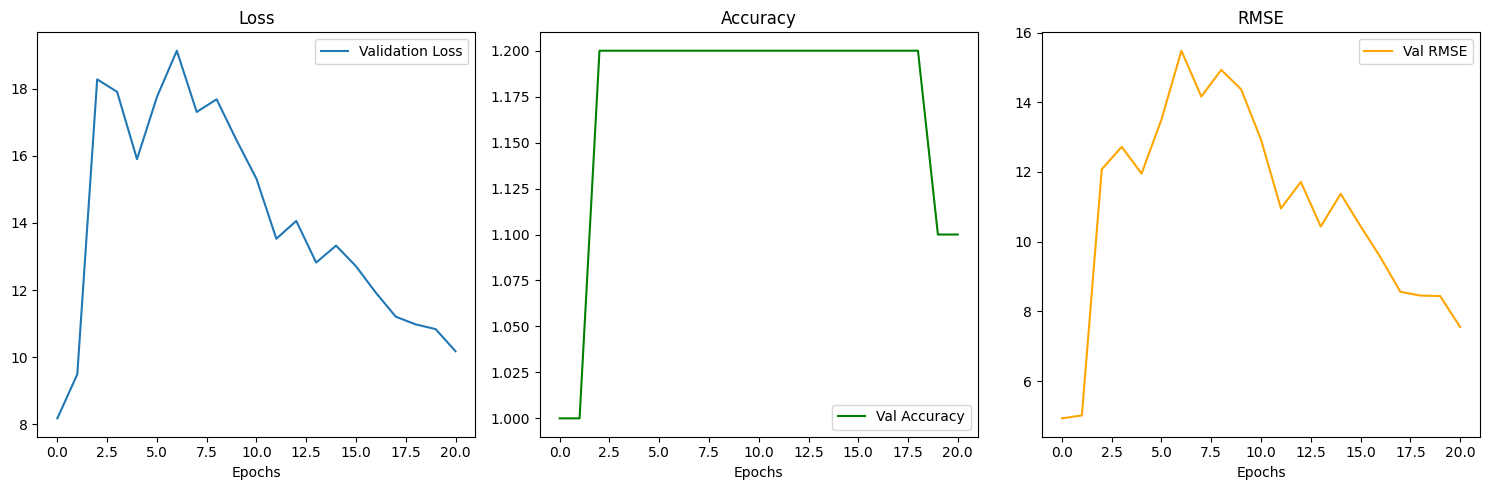

In [35]:
plt.figure(figsize=(15, 5))
# Loss
plt.subplot(1, 3, 1)
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(val_acc_history, color='green', label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

# RMSE
plt.subplot(1, 3, 3)
plt.plot(val_rmse_history, color='orange', label='Val RMSE')
plt.title('RMSE')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.savefig('results_regression.png')
plt.show()